**Research questions**

1. What is predictive of berm condition / intactness? 
2. What is predictive of berm impact on surrounding vegetation, 
3. What is the correspondence between these condition and vegetation response, if any?

Methods: 
- Variables are highly correlated, we first examined which variables explain highest fraction variance in SAVI 



Main results:
  Longer berms more likely to be degraded. Perhaps because more failure points 



Landform is not the best predictor, but useful as a conceptual framework – correspondence to berm purpose (are some water spreader berms actually flood control berms in the dataset).
For managemen 

-  Fan terraces are more effective because steeper,  possibly because steeper (more runoff capture), possibly lower clay and no B horizon?

-  Floodplains less effective because gentle slopes,  possibly high clay

Different reasons, design criteria, inherent differnces.

Flow accumulation tends to be higher in floodplains --> intact berms tend to have lower flow accumulation

agregating over 6 years;
---

## Reference

Nichols, M. H., Duke, S. E., Holifield Collins, C., & Thompson, L. (2023). Legacy earthen berms influence vegetation and hydrologic complexity in the Altar Valley, Arizona. *International Soil and Water Conservation Research*. https://doi.org/10.1016/j.iswcr.2023.01.005


In [1]:
import pandas as pd
import glob
import numpy as np
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import fisher_exact, chi2_contingency

import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module=r"seaborn(\..*)?")

# Global display preferences (apply notebook-wide)
from IPython.display import display, HTML
pd.set_option("display.max_columns", 50)


## Query soil data from API

In [2]:
import json
import re
import requests

URL = "https://sdmdataaccess.sc.egov.usda.gov/Tabular/post.rest"


def sda_post(sql: str, timeout=90) -> dict:
    payload = {"query": sql, "format": "JSON"}
    r = requests.post(
        URL,
        data=json.dumps(payload),
        headers={"Content-Type": "application/json"},
        timeout=timeout,
    )
    r.raise_for_status()

    txt = r.text or ""
    if len(txt.strip()) == 0:
        raise RuntimeError(
            "SDA returned an empty response body (timeout/limits). Try again or simplify query.")
    if txt.lstrip().startswith("<"):
        raise RuntimeError(f"SDA returned non-JSON (starts with '<'). First 400 chars:\n{txt[:400]}")
    return r.json()

def sda_to_df(resp: dict) -> pd.DataFrame:
    table_key = next((k for k, v in resp.items() if isinstance(v, list)), None)
    if table_key is None:
        raise RuntimeError(f"Unexpected SDA JSON keys: {list(resp.keys())}")
    return pd.DataFrame(resp[table_key])

def norm_landform(s) -> str:
    if s is None:
        return "unknown"
    s = str(s).strip().lower()
    s = re.sub(r"\s+", " ", s)
    return s if s else "unknown"

# your one explicit recode
RECODE_EXACT = {"basin floors, fan terraces": "fan terraces"}

def canonical_landform(lf: str) -> str:
    lf = norm_landform(lf)
    return RECODE_EXACT.get(lf, lf)


def classify_landform(lf: str) -> str:
    lf = canonical_landform(lf)

    # Priority 1: stream terraces (always its own class)
    if ("stream terraces" in lf) :
        return "Stream terraces"

    # Priority 2: fans + fan terraces (incl alluvial fans + fan remnants)
    if ("fan terraces" in lf) or ("alluvial fans" in lf) or ("fan remnants" in lf) \
      or ("eroded fan" in lf) or ("fans" in lf) or ("fan piedmonts" in lf):
        return "Fan terraces"

    # Priority 3: valley bottom (basin floors + flood plains + drainageways/swales)
    if ("flood plains" in lf) or ("basin floors" in lf) or ("drainageways" in lf) or \
       ("swales" in lf) or ("plains" in lf):
        return "Flood plains"

    # Priority 4: uplands (hills/mountains/pediments + combos)
    if ("hills" in lf) or ("mountains" in lf) or ("pediments" in lf) or ("ridges" in lf):
        return "Fan terraces"# "Uplands"

    if ("terraces" in lf) :
        return "Stream terraces"    
    
    return  "Unknown"


def print_gee_dict(varname: str, d: dict):
    print(f"\nvar {varname} = ee.Dictionary({{")
    for k in sorted(d.keys(), key=lambda x: int(x) if str(x).isdigit() else str(x)):
        v = str(d[k]).replace("'", "\\'")
        print(f"  '{k}': '{v}',")
    print("});")

# -------------------------
# Curated overrides (optional; keep if you trust these more than SDA)
# -------------------------
MUKEY_to_landform_base = {
    "53807": "stream terraces",
    "53875": "flood plains",
    "53793": "fan terraces",
    "53738": "fan terraces",
    "53806": "flood plains",
    "53895": "fan terraces",
    "53886": "fan terraces, hills",
    "53799": "stream terraces",
    "53759": "flood plains",
}

mukeys_extra = [
    "1416070","1421630","1421631","1423101","1425287","1425309","1425386","1425394",
    "1425688", "1426107","1426108","1426109", "1427770","1427772","1427773","1427775", 
    "1427776","1427809","1427812","1427814","1427815","1427817","54393","54430",
    "53533","53539","53540","53546","53550","53557","53562","53563","53569",
    "53739","53741","53744","53750","53754","53756","53757","53767","53768",
    "53781","53783","53786","53788","53795","801772","801773","801777",
    "53808","53810","53812","53816","53817","53820","53822","53823","53824","53826",
    "53830","53832","53834","53838","53839","53840","53827","53863","54658","54594",
    "53844","53845","53846","53849","53851","53853","53855","53857","53859","53861",
    "53864","53865","53867","53868","53869","53876","53879","53881","53883","53885",
    "53891","53892","53897","53898","53899","53901","53902","53903","53907","53910",
    "54340","54341","54342","54343","54344","54345","54347","54365","53887","54364",
    "54354","54355","54356","54357","54358","54359","54360","54361","54362","54363",
    "54367","54370","54372","54374","54375","54376","54377","54378","54379","54380",
    "54382","54383","54384","54385","54386","54387","54389","54390","54391","54392",
    "54397","54398","54399","54400","54401","54402","54426","54427","54428","54429",
    "54404","54405","54406","54407","54408","54409","54410","54412","54413","54395",
    "54415","54416","54417","54418","54419","54420","54421","54423","54424","54654",
    "54538","54544","54546","54553","54555","54557","54561","54567","54582","54585",
    "54601","54609","54612","54616","54626","54628","54632","54635","54639","54645",
    "54661","54672",

]

mukeys = sorted(set(list(MUKEY_to_landform_base.keys()) + mukeys_extra), key=int)
in_list = ",".join(f"'{m}'" for m in mukeys)



def fetch_landforms_batch(batch_mukeys):
    in_list = ",".join(f"'{m}'" for m in batch_mukeys)
    sql = f"""
    WITH dom AS (
      SELECT
        c.mukey, c.cokey, c.compname, c.comppct_r,
        ROW_NUMBER() OVER (PARTITION BY c.mukey ORDER BY c.comppct_r DESC) AS rn
      FROM component c
      WHERE c.mukey IN ({in_list})
    )
    SELECT
      m.mukey,
      l.areasymbol,
      m.musym,
      m.muname,
      d.compname,
      d.comppct_r,
      cg.geomfname AS landform
    FROM mapunit m
    JOIN legend l ON l.lkey = m.lkey
    JOIN dom d ON d.mukey = m.mukey AND d.rn = 1
    LEFT JOIN cogeomordesc cg
      ON cg.cokey = d.cokey
     AND cg.geomftname = 'Landform'
     AND cg.rvindicator = 'yes'
    ORDER BY m.mukey;
    """
    resp = sda_post(sql)
    dfb = sda_to_df(resp).rename(columns={
        0: "mukey",
        1: "areasymbol",
        2: "musym",
        3: "muname",
        4: "compname",
        5: "comppct_r",
        6: "landform",

    })
    dfb["mukey"] = dfb["mukey"].astype(str)
    dfb["landform"] = dfb["landform"].apply(norm_landform)
    return dfb

BATCH_SIZE = 150
df_parts = []
for i in range(0, len(mukeys), BATCH_SIZE):
    df_parts.append(fetch_landforms_batch(mukeys[i:i + BATCH_SIZE]))

df = pd.concat(df_parts, ignore_index=True)

# collapse multiple landforms per MUKEY (if any)
mukey_landforms_sda = (
    df.dropna(subset=["landform"])
      .groupby("mukey")["landform"]
      .apply(lambda s: ", ".join(sorted(set(s.astype(str)))))
      .to_dict()
 )

# raw landforms (canonicalized) for all requested mukeys
MUKEY_to_landform_raw = {mk: canonical_landform(mukey_landforms_sda.get(mk, "unknown")) for mk in mukeys}
MUKEY_to_landform_raw.update({k: canonical_landform(v) for k, v in MUKEY_to_landform_base.items()})  # curated override

# THIS is the simplified MUKEY_to_landform you want
MUKEY_to_landform = {mk: classify_landform(lf) for mk, lf in MUKEY_to_landform_raw.items()}

print(pd.Series(MUKEY_to_landform).value_counts())


Fan terraces       145
Flood plains        35
Stream terraces     17
Unknown              4
Name: count, dtype: int64


In [3]:
def fetch_landforms_texture_batch(batch_mukeys):
    in_list = ",".join(f"'{m}'" for m in batch_mukeys)


    sql = f"""
    WITH dom AS (
      SELECT
        c.mukey, c.cokey, c.compname, c.comppct_r,
        ROW_NUMBER() OVER (PARTITION BY c.mukey ORDER BY c.comppct_r DESC) AS rn
      FROM component c
      WHERE c.mukey IN ({in_list})
    ),
    surf_hz AS (
      -- pick the topmost horizon for the dominant component
      SELECT
        ch.cokey, ch.chkey, ch.hzdept_r, ch.hzdepb_r,
        ch.sandtotal_r, ch.silttotal_r, ch.claytotal_r,
        ROW_NUMBER() OVER (
          PARTITION BY ch.cokey
          ORDER BY
            CASE WHEN ch.hzdept_r = 0 THEN 0 ELSE 1 END,
            ch.hzdept_r
        ) AS rn
      FROM chorizon ch
      JOIN dom d ON d.cokey = ch.cokey AND d.rn = 1
      WHERE ch.hzdept_r IS NOT NULL
        AND ch.hzdepb_r IS NOT NULL
        AND ch.hzdepb_r > 0
    ),
    tex AS (
      -- representative texture class for that surface horizon
      SELECT
        t0.chkey,
        t0.texcl
      FROM (
        SELECT
          chtg.chkey,
          ct.texcl,
          ROW_NUMBER() OVER (
            PARTITION BY chtg.chkey
            ORDER BY
              CASE WHEN chtg.rvindicator = 'yes' THEN 0 ELSE 1 END,
              ct.texcl
          ) AS rn
        FROM chtexturegrp chtg
        JOIN chtexture ct ON ct.chtgkey = chtg.chtgkey
      ) t0
      WHERE t0.rn = 1
    )
    SELECT
      m.mukey,
      l.areasymbol,
      m.musym,
      m.muname,
      d.compname,
      d.comppct_r,
      cg.geomfname AS landform,
      hz.sandtotal_r,
      hz.silttotal_r,
      hz.claytotal_r,
      tx.texcl
    FROM mapunit m
    JOIN legend l ON l.lkey = m.lkey
    JOIN dom d ON d.mukey = m.mukey AND d.rn = 1
    LEFT JOIN cogeomordesc cg
      ON cg.cokey = d.cokey
     AND cg.geomftname = 'Landform'
     AND cg.rvindicator = 'yes'
    LEFT JOIN surf_hz hz
      ON hz.cokey = d.cokey AND hz.rn = 1
    LEFT JOIN tex tx
      ON tx.chkey = hz.chkey
    ORDER BY m.mukey;
    """

    resp = sda_post(sql)
    dfb = sda_to_df(resp).rename(columns={
        0: "mukey",
        1: "areasymbol",
        2: "musym",
        3: "muname",
        4: "compname",
        5: "comppct_r",
        6: "landform",
        7: "sandtotal_r",
        8: "silttotal_r",
        9: "claytotal_r",
        10: "texcl",
    })

    dfb["mukey"] = dfb["mukey"].astype(str)
    dfb["landform"] = dfb["landform"].apply(norm_landform)
    return dfb

BATCH_SIZE = 150
df_parts = []
for i in range(0, len(mukeys), BATCH_SIZE):
    df_parts.append(fetch_landforms_texture_batch(mukeys[i:i + BATCH_SIZE]))
df = pd.concat(df_parts, ignore_index=True)

df['sandtotal_r'] = df['sandtotal_r'].astype(float)
df['claytotal_r'] = df['claytotal_r'].astype(float)
df['silttotal_r'] = df['silttotal_r'].astype(float)

MUKEY_to_texcl = df.set_index("mukey")["texcl"].fillna("unknown").to_dict()

MUKEY_to_clay = df.set_index("mukey")["claytotal_r"].to_dict()  # numeric %, may be NaN
MUKEY_to_sand = df.set_index("mukey")["sandtotal_r"].to_dict()
MUKEY_to_silt = df.set_index("mukey")["silttotal_r"].to_dict()

In [4]:
df["muname_base"] = (
    df["muname"]
      .astype(str)
      .str.split(",", n=1).str[0]
      .str.strip()
)
df["muname_base"].value_counts().head(30)


slope_re = re.compile(r"(\d+)\s*(?:to|-)\s*(\d+)\s*percent", re.I)

def parse_slope_range(s):
    m = slope_re.search(str(s))
    if not m:
        return (np.nan, np.nan)
    return (float(m.group(1)), float(m.group(2)))

df[["slope_lo", "slope_hi"]] = df["muname"].apply(parse_slope_range).apply(pd.Series)

In [5]:
# 1) clean the name (drop slope text after comma; drop trailing MLRA notes)
df = df.copy()
df["muname_core"] = (
    df["muname"].astype(str).str.lower()
      .str.split(",").str[0]
      .str.replace(r"\s+mlra.*$", "", regex=True)
      .str.replace(r"\s+", " ", regex=True)
      .str.strip()
)

# 2) texture terms (order matters: longest first)
texture_terms = [
    "very fine sandy loam",
    "fine sandy loam",
    "loamy coarse sand",
    "loamy sand",
    "sandy clay loam",
    "silty clay loam",
    "clay loam",
    "silt loam",
    "sandy loam",
    "sandy clay",
    "silty clay",
    "clay",
    "silt",
    "loam",
    "sand",
]
tex_re = r"\b(" + "|".join(map(re.escape, texture_terms)) + r")\b"

# 3) optional coarse-fragment modifiers right before the texture term
mods_re = r"(?P<mods>(?:\b(?:extremely|very)?\s*(?:gravelly|cobbly|stony|channery|shaly)\b\s*)+)?"

pat = mods_re + r"(?P<texture>" + tex_re + r")"

ex = df["muname_core"].str.extract(pat)

df["texture_class"] = ex["texture"].str.strip().str.replace(r"\s+", " ", regex=True).str.title()


## Load CSVs in data folder (GEE exports)

In [6]:
# --- 1) Load and combine CSV files --------------------------------------------------
# Find all CSVs matching the pattern (e.g., AOI01_bermdata_20250205.csv) in the folder.

file_paths = sorted(glob.glob('../data/berm_exports/AOI*_bermdata_*0130.csv'))

# Read each CSV into a DataFrame.
df_list = [pd.read_csv(fp) for fp in file_paths]

# Concatenate all AOI data into a single DataFrame (resetting the row index).
data = pd.concat(df_list, ignore_index=True)


# --- 2) MUKEY mapping dictionaries --------------------------------------------------
# These dicts translate MUKEY (soil map unit keys) to human-readable attributes.
# Note: MUKEYs are strings; keep keys as strings to avoid mismatches later.

MUKEY_to_mapunitname = {
    '53807': 'Glendale silt loam, 0 to 3 percent slopes',
    '53875': 'Riveroad and Comoro soils, 0 to 2 percent slopes',
    '53793': 'Diaspar sandy loam, 1 to 5 percent slopes',
    '53738': 'Altar-Sasabe complex, 1 to 8 percent slopes',
    '53806': 'Anthony fine sandy loam, 0 to 3 percent slopes',
    '53895': 'Bucklebar-Sahuarita complex, 0 to 3 percent slopes',
    '53886': 'Sasabe-Caralampi complex, 1 to 15 percent slopes',
    '53799': 'Glendale-Bucklebar complex, 0 to 3 percent slopes',
    '53759': 'Comoro sandy loam, 0 to 2 percent slopes'
}

MUKEY_to_slopeclass = {
    '53807': 'low', '53875': 'low', '53793': 'high', '53738': 'high',
    '53806': 'low', '53895': 'low', '53886': 'high', '53799': 'low', 
    '53759': 'low'
}

MUKEY_to_parentmaterial = {
    '53807': 'Mixed alluvium',
    '53875': 'Moderately fine textured alluvium, Moderately coarse textured alluvium',
    '53793': 'Alluvium derived from granite and/or alluvium derived from schist',
    '53738': 'Alluvium derived from schist and/or alluvium derived from granite, Mixed alluvium',
    '53806': 'Mixed alluvium', 
    '53895': 'Mixed alluvium', 
    '53886': 'Mixed alluvium',
    '53799': 'Mixed alluvium', 
    '53759': 'Mixed alluvium'
}


MUKEY_to_typicalprofile = {
    '53807': 'A-C', '53875': 'A-C, A-C1-C2-C3', '53793': 'A-Bt-2Bt-3BCt',
    '53738': 'A-Bw-BC-C, A-Bt1-Bt2-Bt3-2Btk', '53806':  'A-AC-C-Ck-C',
    '53895': 'A/Bt-Bt-Btk, A-Bk-2Btkb1-2Btkb2', '53886': 'A-Bt1-Bt2-Bt3-Btk, A-Bt1-Bt2-2C',
    '53799': 'A-C, A/Bt-Bt-Btk', '53759': 'A1-A2-C1-C2'
}



In [7]:
# Rebuild MUKEY -> typical horizon sequence(s) from Soil Data Access
mukeys = sorted(data["MUKEY"].dropna().astype(str).unique())
BATCH_SIZE = 150

def fetch_horizons_for_mukeys(batch_mukeys):
    in_list = ",".join(f"'{m}'" for m in batch_mukeys)
    sql = f"""
    SELECT
      c.mukey,
      c.cokey,
      c.compname,
      c.comppct_r,
      c.majcompflag,
      h.hzname,
      h.hzdept_r
    FROM component c
    JOIN chorizon h ON h.cokey = c.cokey
    WHERE c.mukey IN ({in_list})
      AND h.hzname IS NOT NULL
    ORDER BY c.mukey, c.comppct_r DESC, c.cokey, h.hzdept_r;
    """
    resp = sda_post(sql)
    dfb = sda_to_df(resp).rename(columns={
        0: "mukey",
        1: "cokey",
        2: "compname",
        3: "comppct_r",
        4: "majcompflag",
        5: "hzname",
        6: "hzdept_r",
    })
    dfb["mukey"] = dfb["mukey"].astype(str)
    return dfb

df_parts = []
for i in range(0, len(mukeys), BATCH_SIZE):
    df_parts.append(fetch_horizons_for_mukeys(mukeys[i:i+BATCH_SIZE]))

hz = pd.concat(df_parts, ignore_index=True)

# Choose which components to include:
# Option A: only major components (often matches "multiple profiles per MUKEY")
hz_use = hz[hz["majcompflag"].str.lower().eq("yes")].copy()

# If that yields empty for some MUKEYs, fall back to dominant component:
if hz_use.empty:
    hz_use = hz.copy()

hz_use = hz_use.sort_values(["mukey", "comppct_r", "cokey", "hzdept_r"],
                            ascending=[True, False, True, True])

# Horizon sequence per component
comp_profiles = (
    hz_use.groupby(["mukey", "cokey"], as_index=False)
          .agg(profile=("hzname", lambda s: "-".join(s.astype(str))))
)

# Join unique component profiles per MUKEY
MUKEY_to_typicalprofile_auto = (
    comp_profiles.groupby("mukey")["profile"]
                 .apply(lambda s: ", ".join(pd.unique(s)))
                 .to_dict()
)

MUKEY_to_typicalprofile = MUKEY_to_typicalprofile_auto

# --- 3) Standardize MUKEY and apply mappings ---------------------------------------
# Ensure MUKEY is string so dictionary lookups work even if the source was numeric.
data['MUKEY'] = data['MUKEY'].astype(str)
# Robust MUKEY normalization: keeps missing as <NA> and removes .0 issues

data['MapUnitName'] = data['MUKEY'].map(MUKEY_to_mapunitname)
data['SlopeClass'] = data['MUKEY'].map(MUKEY_to_slopeclass)
data['Landform'] = data['MUKEY'].map(MUKEY_to_landform)
data['ParentMaterial'] = data['MUKEY'].map(MUKEY_to_parentmaterial)
data['TypicalProfile'] = data['MUKEY'].map(MUKEY_to_typicalprofile)
data['Texture'] = data['MUKEY'].map(MUKEY_to_texcl)

data['claytotal_r'] = data['MUKEY'].map(MUKEY_to_clay)
data['sandtotal_r'] = data['MUKEY'].map(MUKEY_to_sand)
data['silttotal_r'] = data['MUKEY'].map(MUKEY_to_silt)

# Harmonize landform label 
data['Landform'] = data['Landform'].replace({"Fan terraces, hills": "Fan terraces"})

# Check for unmatched MUKEYs 
# Inspect MUKEYs that did not find a match in the dictionaries—useful QA check.
unmatched_keys = data[data['MapUnitName'].isna()]['MUKEY'].unique()
print(f"Unmatched MUKEYs: {unmatched_keys}")

# Landform is from MUKEYS

Unmatched MUKEYs: ['53844' '53897' '53817' '53855' '53899' '53744' '53820' '53849' '53757'
 '53902' '53907' '53865' '53822' '53826' '53846' '53783' '53901' '53788'
 '53812' '53879' '53827' '1423101' '53756' '53864']


In [8]:
# --- Classify berm condition -----------------------------------------------------
# Fill missing failure types as "Intact" and collapse to a binary condition:
# "Intact" vs "Degraded" (anything not exactly "Intact" is considered degraded).
data['Fail_Type'] = data['Fail_Type'].fillna("Intact")
data['Condition'] = data['Fail_Type'].apply(lambda x: 'Intact' if x == 'Intact' else 'Degraded')
data = data.loc[data.query("Fail_Type != 'Breach and Flank'").index]

# --- 5) Group and summarize ---------------------------------------------------------
# Count berms by Landform x Condition and display as a contingency table.
summary_counts = data.groupby(['Landform', 'Condition']).size().unstack(fill_value=0)
print("\nBerm Integrity Counts by Landform:\n")
print(summary_counts)


# Count berms by Landform x Condition and display as a contingency table.
summary_counts = data.groupby(['Landform', 'Fail_Type']).size().unstack(fill_value=0)
print("\nBerm Integrity Counts by Landform:\n")
print(summary_counts)

# Convert counts to within-landform proportions (rows sum to 1), rounded to 2 decimals.
summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
print("\nProportion of Berm Conditions by Landform:\n")
print(summary_proportions)

data['savi_background'] = data['savi_background'].replace(0, np.nan)

data['effect'] = (data['saviU_60'] - data['saviD_60'])  / data['savi_background']
data['effect_percent'] = data['effect'] * 100


data['Landform'] = data['Landform'].replace({ "Fan terraces, hills": "Fan terraces"})


Berm Integrity Counts by Landform:

Condition        Degraded  Intact
Landform                         
Fan terraces          123     153
Flood plains          144     215
Stream terraces        50      90

Berm Integrity Counts by Landform:

Fail_Type        Breach  Flank  Intact
Landform                              
Fan terraces         31     92     153
Flood plains         64     80     215
Stream terraces      19     31      90

Proportion of Berm Conditions by Landform:

Fail_Type        Breach  Flank  Intact
Landform                              
Fan terraces       0.11   0.33    0.55
Flood plains       0.18   0.22    0.60
Stream terraces    0.14   0.22    0.64


In [9]:
# Define berm length category
data = data.dropna(subset=['Shape_Leng', 'Fail_Type'])

data['Berm_Length_Class'] = data['Shape_Leng'].apply(
    lambda x: 'Short (≤ 50 m)' if x <= 50 else 'Long (> 50 m)'
)

# Bin slope
data['Slope_Class'] = data['slope_100'].apply(
    lambda x: "Shallow (≤ 2%)" if x <= 2 else "Steep (> 2%)"
)

data['Soil_Development'] = data['TypicalProfile'].astype(str).apply(
    lambda x: 'B horizon' if 'B' in x else 'No B horizon'
)

data['effective'] = False
data.loc[data['effect_percent'] > 7, 'effective'] =  True
data.loc[data['effect_percent'] < 7, 'effective'] = False

data['Effective'] = ''
data.loc[data['effect_percent'] > 7, 'Effective'] =  'Effective'
data.loc[data['effect_percent'] < 7, 'Effective']=  'Ineffective'

data['High_Clay'] = data['claytotal_r'] > data['claytotal_r'].median()
data['Intact'] = data['Condition'] == 'Intact'



In [10]:
# landform : from my dataset
data['proximity'] = data['landform'].replace({
    0 : 'Upland',
    1 : 'Flood plain'    
})


In [11]:
# data.groupby("Texture")['effective'].mean(),\
data.query("Fail_Type =='Breach'").groupby("Texture")['effective'].mean()
# Where breaches occurred on coarser textured soils, the  up and downslope differences in grass cover diminished.



Texture
Clay loam          0.471698
Fine sandy loam    0.625000
Loam               1.000000
Loamy sand         0.500000
Sandy clay loam    0.000000
Sandy loam         0.428571
Silt loam          0.578947
Name: effective, dtype: float64

In [12]:
# Keep textures with >=10 samples in each Intact category, then summarize
sub = data.dropna(subset=["Texture", "Intact", "effective"]).copy()

counts = sub.groupby(["Texture", "Intact"]).size().unstack(fill_value=0)
valid_textures = counts[(counts.min(axis=1) >= 10)].index

texture_order = ["Clay loam",  "Silt loam",  "Loam", "Fine sandy loam", "Sandy loam"]

out = (
    sub[sub["Texture"].isin(valid_textures)]
      .groupby(["Texture", "Intact"])["effective"]
      .agg(mean="mean", count="size")
      .reset_index()
      .assign(Texture=lambda d: pd.Categorical(d["Texture"], categories=texture_order, ordered=True))
      .sort_values(["Texture", "Intact"])
      .reset_index(drop=True)
)

# intact berms - more effective than degraded berms on coarser soils (sandy loam, fine sandy loam)

In [13]:
# For each texture: test whether effectiveness differs between Intact vs Degraded berms
sub = data.dropna(subset=["Texture", "Intact", "effective"]).copy()

# Optional guard to avoid testing very sparse categories
MIN_N_PER_CATEGORY = 10

# Mean/count summary by texture and intact status
summary = (
    sub.groupby(["Texture", "Intact"])["effective"]
       .agg(mean="mean", count="size")
       .reset_index()
       .assign(Group=lambda d: d["Intact"].map({False: "Degraded", True: "Intact"}))
       .drop(columns="Intact")
       .sort_values(["Texture", "Group"])
       .reset_index(drop=True)
)

rows = []
for texture, g in sub.groupby("Texture"):
    ct = pd.crosstab(g["Intact"], g["effective"]).reindex(
        index=[False, True], columns=[False, True], fill_value=0
    )

    n_degraded = int(ct.loc[False].sum())
    n_intact = int(ct.loc[True].sum())
    p_degraded = (ct.loc[False, True] / n_degraded) if n_degraded > 0 else np.nan
    p_intact = (ct.loc[True, True] / n_intact) if n_intact > 0 else np.nan

    if min(n_degraded, n_intact) >= MIN_N_PER_CATEGORY:
        table = [
            [ct.loc[False, False], ct.loc[False, True]],
            [ct.loc[True,  False], ct.loc[True,  True]],
        ]
        odds_ratio, p_value = fisher_exact(table, alternative="two-sided")
        tested = True
    else:
        odds_ratio, p_value = np.nan, np.nan
        tested = False

    rows.append({
        "Texture": texture,
        "n_degraded": n_degraded,
        "n_intact": n_intact,
       "p_effective_degraded": p_degraded,
       "p_effective_intact": p_intact,
       # "odds_ratio": odds_ratio,
        "p_value": p_value,
        "significant_0p05": (p_value < 0.05) if pd.notna(p_value) else False
    })

results = (
    pd.DataFrame(rows)
      .sort_values([ "p_value", "Texture"], ascending=[ True, True])
      .reset_index(drop=True)
)

display(summary)
display(results)
# on corase soils, intact berms tend to be more effective.
# on finer soils, intact berms tend to be less effective, but the difference is not significant.

,Texture,mean,count,Group
0,Clay loam,0.416667,108,Degraded
1,Clay loam,0.377143,175,Intact
2,Fine sandy loam,0.571429,21,Degraded
3,Fine sandy loam,0.363636,33,Intact
4,Loam,0.571429,14,Degraded
5,Loam,0.289474,38,Intact
6,Loamy coarse sand,0.400000,5,Degraded
7,Loamy coarse sand,0.250000,4,Intact
8,Loamy sand,0.200000,5,Degraded
9,Loamy sand,0.333333,3,Intact


,Texture,n_degraded,n_intact,p_effective_degraded,p_effective_intact,p_value,significant_0p05
0,Sandy loam,113,97,0.530973,0.680412,0.034068,True
1,Loam,14,38,0.571429,0.289474,0.103020,False
2,Fine sandy loam,21,33,0.571429,0.363636,0.166631,False
3,Clay loam,108,175,0.416667,0.377143,0.532521,False
4,Silt loam,49,88,0.510204,0.556818,0.720822,False
5,Loamy coarse sand,5,4,0.400000,0.250000,NaN,False
6,Loamy sand,5,3,0.200000,0.333333,NaN,False
7,Sandy clay loam,2,20,0.500000,0.400000,NaN,False


In [14]:
import sys as _sys
_sys.path.insert(0, '../src')
from constants import (
    INTACT_COL, DEGRADED_COL, BREACH_COL, FLANK_COL,
    LF_COLORS, lf_order,
    LENGTH_COLORS, length_order,
    SLOPE_COLORS, slope_order,
    CLAY_COLORS, clay_order,
    SOILDEV_COLORS, soildev_order,
    TEXTURE_COLORS, texture_order,
    LBL_EFFECTIVE, LBL_INEFFECTIVE, eff_order, eff_colors,
    fail_order, fail_colors,
    MODEL_CLR_CONDITION, MODEL_CLR_VEGRESPONSE, MODEL_CLR_CHANCE,
)

# Align Effective column values with canonical labels from constants.py
data['Effective'] = data['Effective'].map({
    'Effective':   LBL_EFFECTIVE,
    'Ineffective': LBL_INEFFECTIVE,
})

In [15]:

sub = data.query("Type == 'Berm'").copy() if "Type" in data.columns else data.copy()
sub = sub.dropna(subset=["Fail_Type", "Texture"])

# 1) Counts: Texture × Fail_Type
ct = pd.crosstab(sub["Texture"], sub["Fail_Type"])
ct_t = ct.copy()
ct_t['Total'] = np.sum(ct_t, axis=1)

# 2) Within-texture proportions (rows sum to 1)
ct_row = ct.div(ct.sum(axis=1), axis=0)
display((ct_row * 100).round(1))



Fail_Type,Breach,Flank,Intact
Texture,,,
Clay loam,20.7,19.9,59.3
Fine sandy loam,15.4,33.3,51.3
Loam,8.6,31.4,60.0
Loamy coarse sand,0.0,55.6,44.4
Loamy sand,28.6,28.6,42.9
Sandy clay loam,0.0,0.0,100.0
Sandy loam,13.2,41.5,45.4
Silt loam,12.0,27.0,61.0


In [16]:
# merge shapefile attrs into existing pandas df `data` on rounded lat/lon
# keep lower-case; do not bring over shapefile columns that duplicate names in `data`

import geopandas as gpd
import os
# --- config ---
shp_path  = "../data/Berm_Directionality/Berm_Directionality.shp"
out_csv   = "../data/merged.csv"
round_ndp = 6

# --- helpers ---
def _normalize_cols(df):
    df = df.copy()
    df.columns = [c.strip().replace(" ", "_") for c in df.columns]
    return df

def _find_lat_lon(cols):
    lc = {c.lower(): c for c in cols}
    lat_candidates = ["lat","latitude","y","lat_dd"]
    lon_candidates = ["lon","long","longitude","x","lon_dd"]
    lat = next((lc[c] for c in lat_candidates if c in lc), None)
    lon = next((lc[c] for c in lon_candidates if c in lc), None)
    return lat, lon

def _ll_key(df, lat_col, lon_col, ndp=6):
    lat = pd.to_numeric(df[lat_col], errors="coerce").round(ndp)
    lon = pd.to_numeric(df[lon_col], errors="coerce").round(ndp)
    return lat.astype("string") + "_" + lon.astype("string")

# --- require an existing `data` dataframe ---
if "data" not in globals():
    raise NameError("expected a pandas dataframe named `data` in memory")

data = _normalize_cols(data)
data_lat, data_lon = _find_lat_lon(data.columns)
if not data_lat or not data_lon:
    raise KeyError(f"couldn't find lat/lon in `data`; columns: {list(data.columns)}")

# read shapefile, normalize cols
gdf = gpd.read_file(shp_path)
if gdf.crs is None:
    gdf = gdf.set_crs(epsg=4326)
elif gdf.crs.to_epsg() != 4326:
    gdf = gdf.to_crs(epsg=4326)
gdf = _normalize_cols(gdf)

shp_lat, shp_lon = _find_lat_lon(gdf.columns)
if not shp_lat or not shp_lon:
    raise KeyError(f"couldn't find lat/lon in shapefile; columns: {list(gdf.columns)}")

# build merge keys
left  = data.copy()
right = gdf.drop(columns=["geometry"], errors="ignore").copy()

left["__ll_key__"]  = _ll_key(left,  data_lat, data_lon, ndp=round_ndp)
right["__ll_key__"] = _ll_key(right, shp_lat,  shp_lon,  ndp=round_ndp)

# keep only NON-OVERLAPPING shapefile columns (plus the join key)
cols_to_add = ["__ll_key__"] + [c for c in right.columns if c not in left.columns and c != "__ll_key__"]
right = right[cols_to_add]

# merge (no suffixes needed because we've removed duplicates by name)
merged = left.merge(right, on="__ll_key__", how="left").drop(columns="__ll_key__")

# save
os.makedirs(os.path.dirname(out_csv), exist_ok=True)
merged.to_csv(out_csv, index=False)
print(f"done. merged rows = {len(merged):,} -> {out_csv}")


done. merged rows = 775 -> ../data/merged.csv


In [17]:
from plotting import remove_legend_titles
from registry import (
    update_figure_registry,
    register_outcomes_figure,
    register_failure_mechanisms_figure,
)
from analysis import (
    analyze_outcome,
    rank_predictors,
    fit_rf_binary,
    PRETTY_LABELS,
)


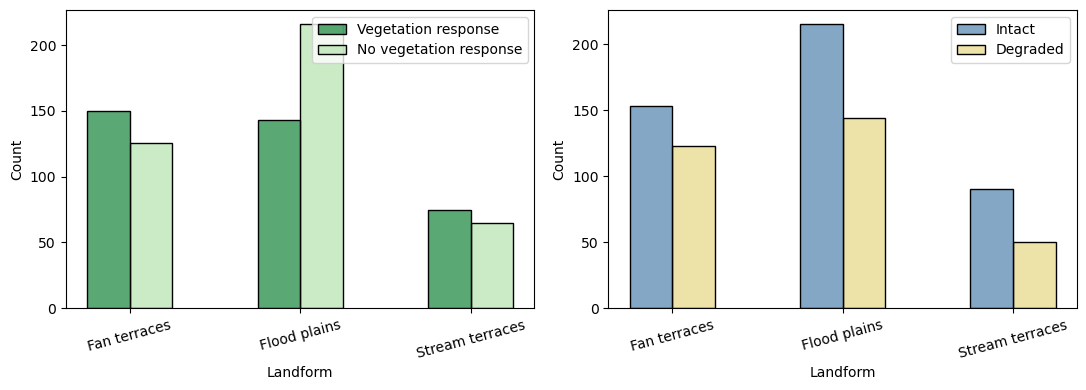

In [18]:
plot_df = data.copy()

plot_df["Intact"] = pd.Categorical(
    np.where(plot_df["Intact"].astype(bool), "Intact", "Degraded"),
    categories=["Intact", "Degraded"], ordered=True
)

palette_eff = eff_colors
palette_int = {"Intact": INTACT_COL, "Degraded": DEGRADED_COL}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Stability
sns.histplot(
    data=plot_df.sort_values("Landform"),
    x="Landform", hue="Effective",
    multiple="dodge", shrink=0.5, stat="count",
    palette=palette_eff, hue_order=eff_order,
    ax=axes[0], legend=True
)

# Intactness
sns.histplot(
    data=plot_df.sort_values("Landform"),
    x="Landform", hue="Intact",
    hue_order=["Intact", "Degraded"], palette=palette_int,
    multiple="dodge", shrink=0.5, stat="count",
    ax=axes[1], legend=True
)

# Title/position legends the seaborn way (no manual ax.legend() call)
try:
    sns.move_legend(axes[0], "upper right", title="", frameon=True)
    sns.move_legend(axes[1], "upper right", title="", frameon=True)
except Exception:
    # Fallback for older seaborn: retitle existing legends if present
    if axes[0].legend_ is not None: axes[0].legend_.set_title("Stability")
    if axes[1].legend_ is not None: axes[1].legend_.set_title("Intactness")

for ax in axes:
    ax.set_xlabel("Landform")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()



## Hypothesis tests

In [19]:
from scipy.stats import fisher_exact, chi2_contingency  # kept for local use
from plotting import (
    width,
    _sig_stars, _two_cat_metrics,
    _draw_two_cat_panel, _draw_multi_cat_panel,
)

# Slope labels (referenced by later cells)
shallow_lbl = 'Shallow (≤ 2%)'
steep_lbl   = 'Steep (> 2%)'


Updated → ../latex/figure_report_outcomes.tex  (fig4)


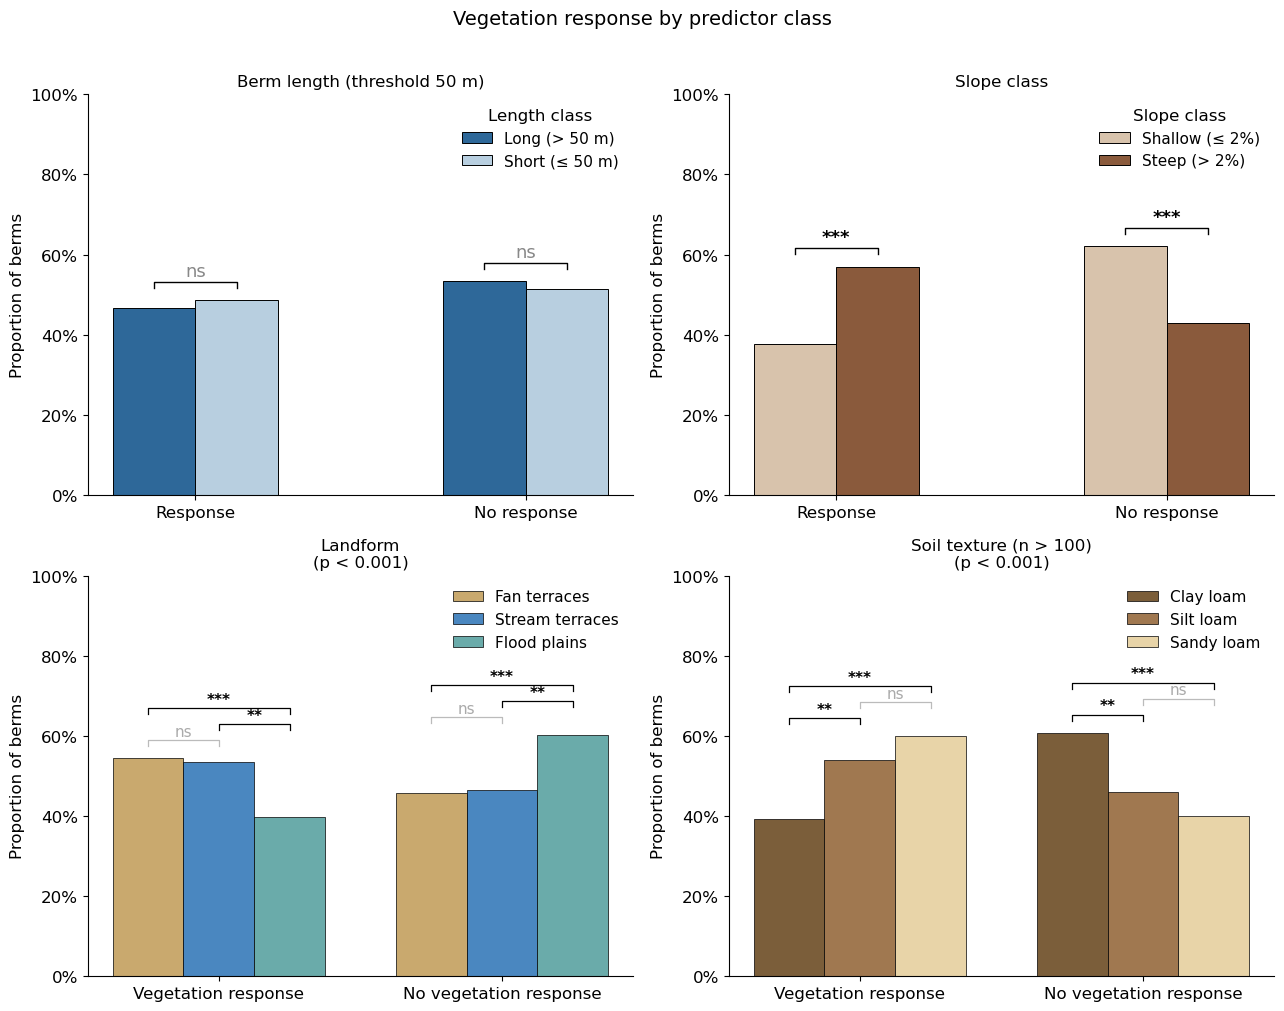

In [20]:
from pathlib import Path
from scipy.stats import chi2_contingency, fisher_exact
from itertools import combinations as _combinations

_w = 0.25   # bar half-width for this cell

# Length labels (matching len_bin values and LENGTH_COLORS keys)
long_lbl  = "Long (> 50 m)"
short_lbl = "Short (≤ 50 m)"

thr = 50   # length threshold in metres (matches Berm_Length_Class)

# Slope labels (matching Slope_Class values created earlier)
shallow_lbl = "Shallow (≤ 2%)"
steep_lbl   = "Steep (> 2%)"

# ── Helpers (vegetation-response versions) ────────────────────────────────

def _eff_two_cat_metrics(df_sub, group_col, cat_a, cat_b):
    """Fisher exact for vegetation response rate between two categories."""
    d = df_sub.dropna(subset=[group_col, "Effective"]).copy()
    n_a = (d[group_col] == cat_a).sum()
    n_b = (d[group_col] == cat_b).sum()
    rows = {}
    for metric, pos_fn in [(LBL_EFFECTIVE,   lambda x: x["Effective"] == LBL_EFFECTIVE),
                            (LBL_INEFFECTIVE, lambda x: x["Effective"] == LBL_INEFFECTIVE)]:
        mask = pos_fn(d)
        c_a  = mask[d[group_col] == cat_a].sum()
        c_b  = mask[d[group_col] == cat_b].sum()
        p_a, p_b = c_a / n_a, c_b / n_b
        direction = "greater" if p_a >= p_b else "less"
        _, p_val = fisher_exact([[c_a, n_a - c_a], [c_b, n_b - c_b]], alternative=direction)
        rows[metric] = {cat_a: p_a, cat_b: p_b, "sig": _sig_stars(p_val)}
    return pd.DataFrame(rows).T

def _draw_eff_two_cat_panel(ax, m, cat_a, cat_b, colors, legend_title, title):
    outcomes = [LBL_EFFECTIVE, LBL_INEFFECTIVE]
    short    = ["Response", "No response"]
    x = np.arange(2)
    for cat, offset in [(cat_a, -_w/2), (cat_b, _w/2)]:
        vals = [m.loc[o, cat] for o in outcomes]
        ax.bar(x + offset, vals, _w, label=cat, color=colors[cat],
               edgecolor="black", linewidth=0.7)
    for i, o in enumerate(outcomes):
        sig = m.loc[o, "sig"]
        top = max(m.loc[o, cat_a], m.loc[o, cat_b]) + 0.03
        bh  = 0.015
        ax.plot([x[i]-_w/2, x[i]-_w/2, x[i]+_w/2, x[i]+_w/2],
                [top, top+bh, top+bh, top], lw=1, color="black")
        col = "black" if sig != "ns" else "#888888"
        ax.text(x[i], top+bh+0.005, sig, ha="center", va="bottom",
                fontsize=13, color=col, fontweight="bold" if sig != "ns" else "normal")
    ax.set_xticks(x)
    ax.set_xticklabels(short)
    ax.set_ylabel("Proportion of berms")
    ax.set_title(title)
    ax.set_ylim(0, 1.0)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.legend(title=legend_title, frameon=False, fontsize=11, loc="upper right")
    sns.despine(ax=ax)

def _draw_eff_multi_cat_panel(ax, df_sub, group_col, cat_order, cat_colors, title, pairwise=False):
    """Grouped bars: Response / No response x-axis, one bar per category."""
    d = df_sub.dropna(subset=[group_col, "Effective"]).copy()
    cats   = [c for c in cat_order if c in d[group_col].unique()]
    n_cats = len(cats)
    bar_w  = _w
    _mc_w  = n_cats * bar_w
    offsets = np.linspace(-_mc_w/2 + bar_w/2, _mc_w/2 - bar_w/2, n_cats)
    outcomes = [LBL_EFFECTIVE, LBL_INEFFECTIVE]
    short    = ["Vegetation response", "No vegetation response"]
    x = np.arange(2)

    bars_data = {}
    ns_cat = {}
    for cat in cats:
        sub  = d[d[group_col] == cat]
        n    = len(sub)
        ns_cat[cat] = n
        bars_data[cat] = {
            LBL_EFFECTIVE:   (sub["Effective"] == LBL_EFFECTIVE).sum() / n,
            LBL_INEFFECTIVE: (sub["Effective"] == LBL_INEFFECTIVE).sum() / n,
        }

    # overall chi-sq for title
    ct_chi = pd.crosstab(d[group_col], d["Effective"]).reindex(cats).dropna()
    _, p_chi, *_ = chi2_contingency(ct_chi)
    p_str = f"p = {p_chi:.3g}" if p_chi >= 0.001 else "p < 0.001"

    for ci, (cat, offset) in enumerate(zip(cats, offsets)):
        for oi, outcome in enumerate(outcomes):
            ax.bar(x[oi] + offset, bars_data[cat][outcome], bar_w,
                   color=cat_colors.get(cat, "#aaaaaa"), edgecolor="black", linewidth=0.5,
                   label=cat if oi == 0 else "_nolegend_")

    bh = 0.015

    if pairwise:
        pair_list = list(_combinations(range(n_cats), 2))
        pair_list.sort(key=lambda p: abs(offsets[p[1]] - offsets[p[0]]))
        global_y_max = 0
        for oi, outcome in enumerate(outcomes):
            current_top = max(bars_data[cat][outcome] for cat in cats) + 0.03
            for ci, cj in pair_list:
                ca, cb = cats[ci], cats[cj]
                na, nb = ns_cat[ca], ns_cat[cb]
                ka = (d[d[group_col]==ca]["Effective"] == outcome).sum()
                kb = (d[d[group_col]==cb]["Effective"] == outcome).sum()
                p_a, p_b = ka/na, kb/nb
                direction = "greater" if p_a >= p_b else "less"
                _, p_pair = fisher_exact([[ka, na-ka], [kb, nb-kb]], alternative=direction)
                sig = _sig_stars(p_pair)
                x_left  = x[oi] + offsets[ci]
                x_right = x[oi] + offsets[cj]
                y_base  = max(bars_data[ca][outcome], bars_data[cb][outcome])
                y_start = max(y_base + 0.02, current_top)
                ax.plot([x_left, x_left, x_right, x_right],
                        [y_start, y_start+bh, y_start+bh, y_start],
                        lw=0.9, color="black" if sig != "ns" else "#bbbbbb")
                col = "black" if sig != "ns" else "#aaaaaa"
                ax.text((x_left+x_right)/2, y_start+bh+0.003, sig,
                        ha="center", va="bottom", fontsize=11, color=col,
                        fontweight="bold" if sig != "ns" else "normal")
                current_top = y_start + bh + 0.025
            global_y_max = max(global_y_max, current_top)
        y_max = global_y_max + 0.04
    else:
        sig_overall = _sig_stars(p_chi)
        for oi in range(2):
            vals = [bars_data[cat][outcomes[oi]] for cat in cats]
            top  = max(vals) + 0.03
            ax.plot([x[oi]-_mc_w/2, x[oi]-_mc_w/2, x[oi]+_mc_w/2, x[oi]+_mc_w/2],
                    [top, top+bh, top+bh, top], lw=1, color="black")
            col = "black" if sig_overall != "ns" else "#888888"
            ax.text(x[oi], top+bh+0.005, sig_overall, ha="center", va="bottom",
                    fontsize=13, color=col, fontweight="bold" if sig_overall != "ns" else "normal")
        y_max = max(max(bars_data[cat][o] for cat in cats) for o in outcomes) + 0.12

    ax.set_xticks(x)
    ax.set_xticklabels(short)
    ax.set_ylabel("Proportion of berms")
    ax.set_title(f"{title}\n({p_str})", fontsize=12)
    ax.set_ylim(0, 1.0)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.legend(frameon=False, fontsize=11, loc="upper right")
    sns.despine(ax=ax)

# ── Two-category vegetation-response metrics ───────────────────────────────
eff_len_m   = _eff_two_cat_metrics(data, "Berm_Length_Class", long_lbl, short_lbl)
eff_slope_m = _eff_two_cat_metrics(data, "Slope_Class", shallow_lbl, steep_lbl)

# Use canonical colours from constants (keyed on the canonical 50m labels)
EFF_COLORS_LEN   = {long_lbl:  LENGTH_COLORS["Long (> 50 m)"],
                    short_lbl: LENGTH_COLORS["Short (≤ 50 m)"]}
EFF_COLORS_SLOPE = {shallow_lbl: SLOPE_COLORS["Shallow (≤ 2%)"],
                    steep_lbl:   SLOPE_COLORS["Steep (> 2%)"]}

# ── Texture colours — use canonical palette from constants ──
tex_counts2    = data["Texture"].value_counts()
tex_valid2     = tex_counts2[tex_counts2 > 100].index
tex_order_eff  = [t for t in texture_order if t in tex_valid2]
tex_colors_eff = {t: TEXTURE_COLORS.get(t, "#aaaaaa") for t in tex_order_eff}

# ── 2×2 figure ────────────────────────────────────────────────────────────
plt.rcParams.update({"font.size": 12, "axes.titlesize": 12, "axes.labelsize": 12,
                     "xtick.labelsize": 12, "ytick.labelsize": 12})
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

_draw_eff_two_cat_panel(axes[0, 0], eff_len_m, long_lbl, short_lbl,
    EFF_COLORS_LEN, "Length class",
    f"Berm length (threshold {thr} m)")

_draw_eff_two_cat_panel(axes[0, 1], eff_slope_m, shallow_lbl, steep_lbl,
    EFF_COLORS_SLOPE, "Slope class",
    "Slope class")

_draw_eff_multi_cat_panel(axes[1, 0], data, "Landform",
    lf_order, LF_COLORS,
    "Landform", pairwise=True)

_draw_eff_multi_cat_panel(axes[1, 1], data, "Texture",
    tex_order_eff, tex_colors_eff,
    "Soil texture (n > 100)", pairwise=True)

plt.suptitle("Vegetation response by predictor class", fontsize=14, y=1.01)
plt.tight_layout()

# ── Save and register as Paper 1 Figure 4 ─────────────────────────────────
_out = Path("../figures/outcomes/fig4_vegetation_response.png")
_out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(_out, dpi=300, bbox_inches="tight")

register_outcomes_figure(
    "FIG_4",
    label="fig4",
    file_name=_out.name,
    stats_text=(
        "Two-category panels (length, slope) use a one-sided Fisher's exact test; "
        "multi-category panels (landform, texture) use pairwise Fisher's exact tests "
        "with the overall chi-squared p-value shown in the panel title."
    ),
    interpretation_text=(
        "Vegetation response is significantly associated with slope class (p < 0.001), "
        "landform (p < 0.001), and soil texture (p < 0.001), but not with berm "
        "length alone. Steep-slope berms and flood-plain berms show the highest rates "
        "of vegetation response."
    ),
)

plt.show()


In [21]:
data.groupby("Effective")[['FA_30_max', 'FA_60_max']].median()/1000
# tend to have longer flow accumulation i ineffective berms

,FA_30_max,FA_60_max
Effective,,
No vegetation response,2.562,9.1800
Vegetation response,1.667,3.1595


In [22]:
data.groupby("Intact")[['FA_30_max', 'FA_60_max']].median()/1000
# tend to have longer flow accumulation in ineffective berms

,FA_30_max,FA_60_max
Intact,,
False,4.5480,9.629
True,1.0595,2.708


## Exploratory plots

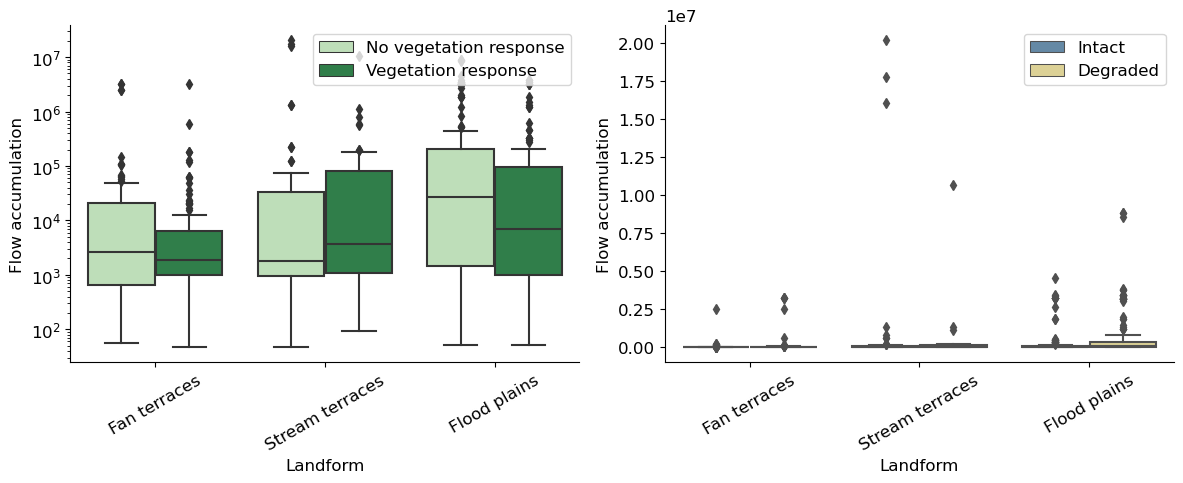

In [23]:
FA_COL = "FA_60_max"   # ← change to "FA_30_max" to switch metric

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes = axes.ravel()

balanced_data = data.query("Type == 'Berm'").copy() if "Type" in data.columns else data.copy()

# consistent Landform order across panels
landform_order = ["Fan terraces", "Stream terraces", "Flood plains"]

# helper: remove top+right spines, add bar outlines, log y
def style_bar_ax(ax):
    sns.despine(ax=ax, top=True, right=True)
    for p in ax.patches:
        p.set_edgecolor("black")
        p.set_linewidth(0.8)
    ax.set_yscale("log")

    # make sure the bottom is > 0 on log scale
    heights = [p.get_height() for p in ax.patches if np.isfinite(p.get_height()) and p.get_height() > 0]
    if heights:
        ax.set_ylim(bottom=min(heights) / 2)

eps = 1e-6  # only used if any medians are 0 (log scale needs >0)

# --- Panel 1: FA_COL by Landform, hue=Effective ---
eff_med = (
    balanced_data.groupby(["Landform", "Effective"], dropna=False)[[FA_COL]]
    .median()
    .reset_index()
)
eff_med[FA_COL] = eff_med[FA_COL].clip(lower=eps)

sns.boxplot(
    data=balanced_data, x="Landform", y=FA_COL, hue="Effective",
    order=landform_order,
    palette=palette_eff,
    ax=axes[0],
)
axes[0].set_xlabel("Landform")
axes[0].set_ylabel(f"Flow accumulation")
axes[0].tick_params(axis="x", rotation=30)
axes[0].set_yscale('log')
sns.despine(ax=axes[0], top=True, right=True)

# --- Panel 2: FA_COL by Landform, hue=Condition/Intact ---
if "Condition" in balanced_data.columns:
    cond_col = "Condition"
    bd2 = balanced_data

cond_med = (
    bd2.groupby(["Landform", cond_col], dropna=False)[[FA_COL]]
    .median()
    .reset_index()
    .rename(columns={cond_col: "Condition"})
)
cond_med[FA_COL] = cond_med[FA_COL].clip(lower=eps)

sns.boxplot(
    data=balanced_data, x="Landform", y=FA_COL, hue="Condition",
    order=landform_order,
    palette=palette_int,
    ax=axes[1],
)
axes[1].set_xlabel("Landform")
axes[1].set_ylabel(f"Flow accumulation")
axes[1].tick_params(axis="x", rotation=30)
sns.despine(ax=axes[1], top=True, right=True)

# --- consistent legend placement ---
remove_legend_titles(axes)
for ax in axes:
    leg = ax.get_legend()
    if leg is not None:
        leg.set_bbox_to_anchor(None)
        leg._loc = 1            # upper right
        leg.set_alignment("left")

plt.tight_layout()
fig.savefig("../figures/scratch/fa_boxplots_by_landform.png", dpi=300, bbox_inches="tight")

plt.show()

In [24]:
from registry import (
    upsert_latex_figentry,
    register_outcomes_figure,
    register_failure_mechanisms_figure,
    update_figure_registry,
)


Saved → ../figures/outcomes/SI_fig1_fa30_pointplot_by_landform.png
Updated → ../latex/figure_report_outcomes.tex  (Supplementary Figure 1)


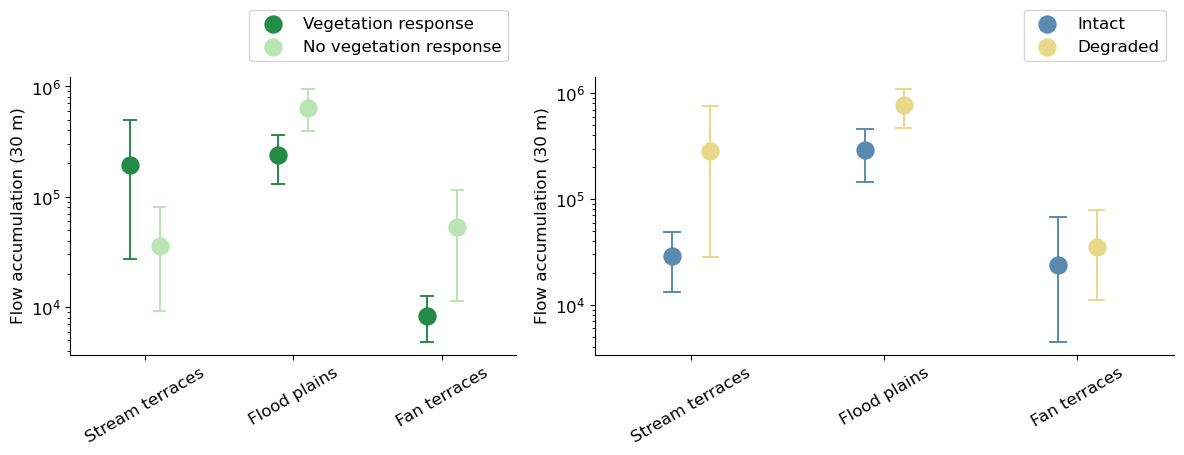

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5),
                         gridspec_kw={"width_ratios": [1, 1.3]})
axes = axes.ravel()

sns.pointplot(data, x="Landform", y="FA_30_max", hue="Effective", ax=axes[0],
              dodge=0.2, capsize=0.08, errwidth=1.4, scale=1.5, join=False,
              palette=palette_eff, hue_order=eff_order)

sns.pointplot(data, x="Landform", y="FA_30_max", hue="Condition", ax=axes[1],
              dodge=0.2, capsize=0.08, errwidth=1.4, scale=1.5, join=False,
              palette=palette_int, hue_order=["Intact", "Degraded"])

for ax in axes:
    ax.set_yscale("log")
    ax.tick_params(axis="x", rotation=30)
    ax.set_xlabel("")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Flow accumulation (30 m)")
axes[1].set_ylabel("Flow accumulation (30 m)")

# --- consistent legend placement (above plot area, no title) ---
remove_legend_titles(axes)
for ax in axes:
    leg = ax.get_legend()
    if leg is not None:
        leg.set_bbox_to_anchor((1.0, 1.27))
        leg._loc = 1            # upper right
        leg.set_alignment("left")

plt.tight_layout()

# ── save as Paper 1 SI Figure 1 ──
out_path = Path("../figures/outcomes/SI_fig1_fa30_pointplot_by_landform.png")
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, dpi=300, bbox_inches="tight")
print(f"Saved → {out_path}")

# ── upsert into Paper 1 LaTeX ──
register_outcomes_figure(
    tag="SI_FIG_1",
    label="Supplementary Figure 1",
    file_name=r"SI\_fig1\_fa30\_pointplot\_by\_landform.png",
    stats_text=(
        "Point plots show mean $\\pm$ 95\\% CI of 30\\,m flow accumulation "
        "(log scale) by landform, grouped by vegetation response (Panel A) "
        "and structural condition (Panel B)."
    ),
    interpretation_text=(
        "Flood-plain berms experience the highest contributing flow "
        "accumulation regardless of outcome, while fan-terrace berms "
        "receive the least. Within each landform, effective berms "
        "tend to have similar or higher flow accumulation than "
        "ineffective berms, and degraded berms tend toward higher "
        "values than intact berms, consistent with greater hydraulic "
        "stress on degraded structures."
    ),
)
plt.show()

Saved → ../figures/outcomes/SI_fig3_countplots_by_outcome_and_landform.png
Updated → ../latex/figure_report_outcomes.tex  (Supplementary Figure 3)


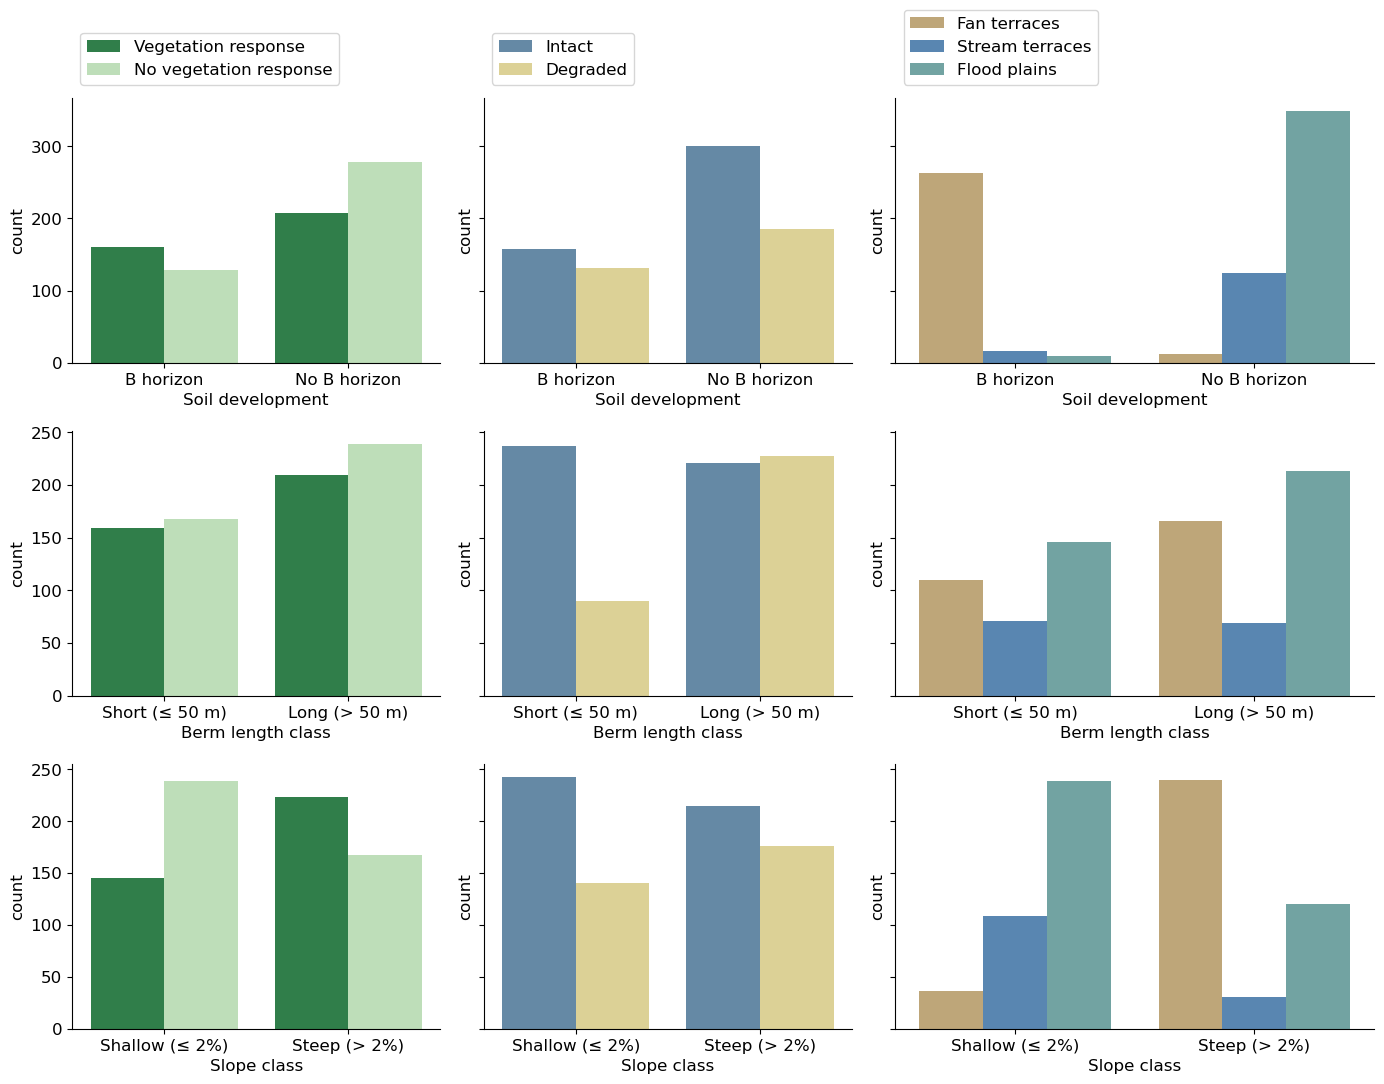

In [26]:
fig, axes = plt.subplots(3, 3, figsize=(14, 11), sharey="row",
                         gridspec_kw={"width_ratios": [1, 1, 1.3]})

# ── Row 0: Soil Development ──
soil_order = ["B horizon", "No B horizon"]
sns.countplot(data=data, x="Soil_Development", hue="Effective", ax=axes[0, 0],
              palette=palette_eff, hue_order=eff_order, order=soil_order)
sns.countplot(data=data, x="Soil_Development", hue="Condition", ax=axes[0, 1],
              palette=palette_int, hue_order=["Intact", "Degraded"], order=soil_order)
sns.countplot(data=data, x="Soil_Development", hue="Landform", ax=axes[0, 2],
              palette=LF_COLORS, hue_order=lf_order, order=soil_order)
for ax in axes[0]:
    ax.set_xlabel("Soil development")

# ── Row 1: Berm Length Class ──
sns.countplot(data=data, x="Berm_Length_Class", hue="Effective", ax=axes[1, 0],
              palette=palette_eff, hue_order=eff_order, order=length_order)
sns.countplot(data=data, x="Berm_Length_Class", hue="Condition", ax=axes[1, 1],
              palette=palette_int, hue_order=["Intact", "Degraded"], order=length_order)
sns.countplot(data=data, x="Berm_Length_Class", hue="Landform", ax=axes[1, 2],
              palette=LF_COLORS, hue_order=lf_order, order=length_order)
for ax in axes[1]:
    ax.set_xlabel("Berm length class")

# ── Row 2: Slope Class ──
sns.countplot(data=data, x="Slope_Class", hue="Effective", ax=axes[2, 0],
              palette=palette_eff, hue_order=eff_order, order=slope_order)
sns.countplot(data=data, x="Slope_Class", hue="Condition", ax=axes[2, 1],
              palette=palette_int, hue_order=["Intact", "Degraded"], order=slope_order)
sns.countplot(data=data, x="Slope_Class", hue="Landform", ax=axes[2, 2],
              palette=LF_COLORS, hue_order=lf_order, order=slope_order)
for ax in axes[2]:
    ax.set_xlabel("Slope class")

# ── One legend per column (top row only), remove all others ──
for row in range(3):
    for col in range(3):
        ax = axes[row, col]
        sns.despine(ax=ax)
        if row == 0:
            # keep legend on top row, upper-left corner, remove title
            leg = ax.get_legend()
            if leg:
                leg.set_title("")
                leg.set_bbox_to_anchor((0.0, 1.02), transform=ax.transAxes)
                leg._loc = 3            # lower left (anchored above axes)
        else:
            ax.get_legend().remove()

fig.tight_layout()

# ── save as Paper 1 SI Figure 3 ──
out_path = Path("../figures/outcomes/SI_fig3_countplots_by_outcome_and_landform.png")
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, dpi=300, bbox_inches="tight")
print(f"Saved → {out_path}")

register_outcomes_figure(
    tag="SI_FIG_3",
    label="Supplementary Figure 3",
    file_name=r"SI\_fig3\_countplots\_by\_outcome\_and\_landform.png",
    stats_text=(
        "3$\\times$3 panel of count plots. Rows: soil development (B horizon vs.\\ none), "
        "berm length class (short vs.\\ long), slope class (shallow vs.\\ steep). "
        "Columns: vegetation response, structural condition, landform."
    ),
    interpretation_text=(
        "Fan-terrace berms are overwhelmingly found in B-horizon soils, whereas "
        "stream-terrace and flood-plain berms dominate in soils without a B horizon. "
        "Berm length and slope class are more evenly distributed across outcomes, "
        "though short berms are disproportionately intact and steep-slope berms "
        "show a higher proportion of vegetation response."
    ),
)
plt.show()

In [27]:
data.sort_values("Landform")['Landform'].unique()

array(['Fan terraces', 'Flood plains', 'Stream terraces'], dtype=object)

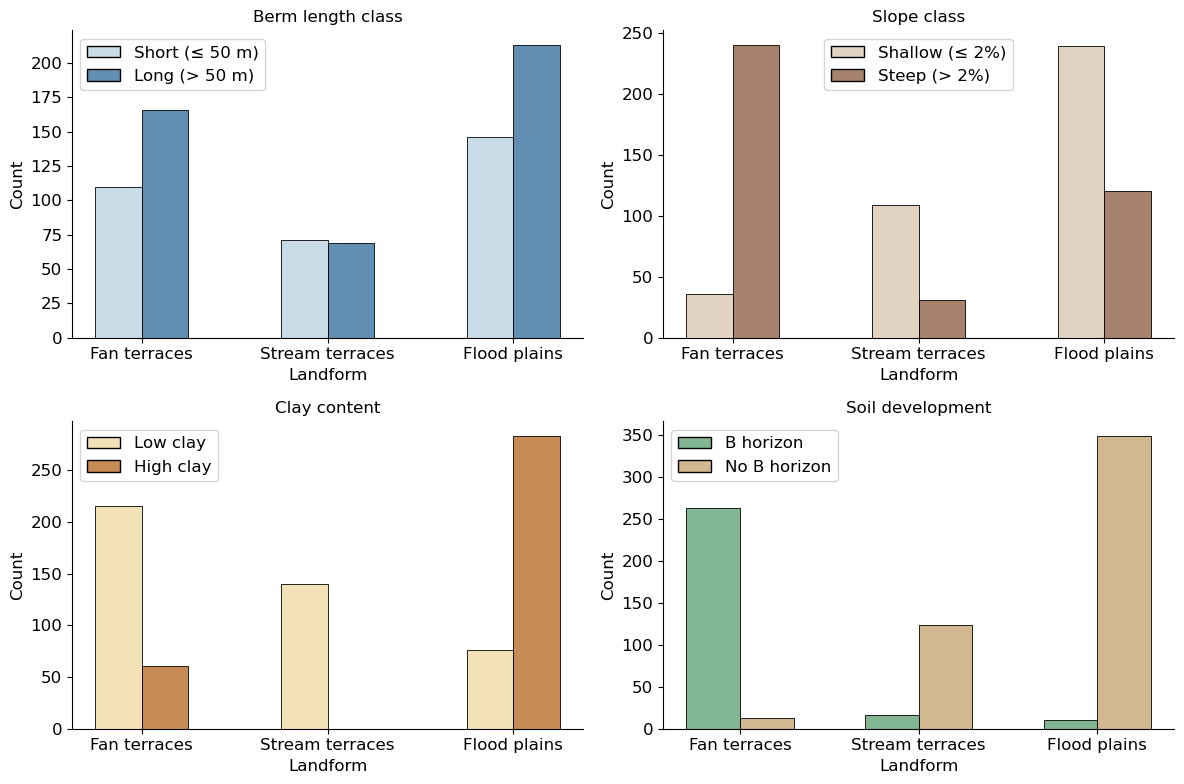

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes_flat = axes.ravel()

# Enforce canonical landform order (from cell 17) via Categorical
_lf_sort = data.copy()
_lf_sort["Landform"] = pd.Categorical(_lf_sort["Landform"], categories=lf_order, ordered=True)
_lf_sort = _lf_sort.sort_values("Landform")

# Map boolean High_Clay to canonical labels for palette
_lf_sort["High_Clay_Label"] = np.where(_lf_sort["High_Clay"], "High clay", "Low clay")

sns.histplot(data=_lf_sort, x="Landform",
             hue="Berm_Length_Class", ax=axes_flat[0], stat="count",
             shrink=0.5, multiple="dodge", palette=LENGTH_COLORS,
             hue_order=length_order)
axes_flat[0].set_title("Berm length class")

sns.histplot(data=_lf_sort, x="Landform",
             hue="Slope_Class", ax=axes_flat[1], stat="count",
             shrink=0.5, multiple="dodge", palette=SLOPE_COLORS,
             hue_order=slope_order)
axes_flat[1].set_title("Slope class")

sns.histplot(data=_lf_sort, x="Landform",
             hue="High_Clay_Label", ax=axes_flat[2], stat="count",
             shrink=0.5, multiple="dodge", palette=CLAY_COLORS,
             hue_order=clay_order)
axes_flat[2].set_title("Clay content")

sns.histplot(data=_lf_sort, x="Landform",
             hue="Soil_Development", ax=axes_flat[3], stat="count",
             shrink=0.6, multiple="dodge", palette=SOILDEV_COLORS,
             hue_order=soildev_order)
axes_flat[3].set_title("Soil development")

# ── Styling: despine, edge colours, axis labels ──
for ax in axes_flat:
    sns.despine(ax=ax)
    for p in ax.patches:
        p.set_edgecolor("black")
        p.set_linewidth(0.6)
    ax.set_xlabel("Landform")
    ax.set_ylabel("Count")

remove_legend_titles(axes_flat)
fig.tight_layout()



### Significance tests

In [29]:
from analysis import (
    _auto_positive, chi2_with_cramers_v, _two_prop_z, _bh_adjust,
    pairwise_by_group, analyze_outcome,
)


In [30]:
out_eff = analyze_outcome(data, group_col="Landform", outcome_col="Effective", positive=None, fdr_alpha=0.05)
out_int = analyze_outcome(data, group_col="Landform", outcome_col="Intact",    positive=None, fdr_alpha=0.05)

def _print_pairwise(pairwise_df, label):
    print(f"\nPairwise comparisons — {label}:")
    print(pairwise_df
          .assign(prop_a=lambda d: d["prop_a"].round(3),
                  prop_b=lambda d: d["prop_b"].round(3),
                  diff_a_minus_b=lambda d: d["diff_a_minus_b"].round(3),
                  p_raw=lambda d: d["p_raw"].round(4),
                  q_fdr=lambda d: d["q_fdr"].round(4))
          .reset_index(drop=True)
          .to_string())

# ── Print results: Effectiveness ──
print("\n=== Stability (Effective) vs Landform ===")
print("Global χ² p-value:", f"{out_eff['global']['p_value']:.3g}",
      "| Cramér's V:", f"{out_eff['global']['cramers_v']:.3f}")
print("\nProportion Effective by Landform:")
print(out_eff["proportions"].round(3))
_print_pairwise(out_eff["pairwise"], "Effective")

# ── Print results: Intactness ──
print("\n=== Intactness (Intact) vs Landform ===")
print("Global χ² p-value:", f"{out_int['global']['p_value']:.3g}",
      "| Cramér's V:", f"{out_int['global']['cramers_v']:.3f}")
print("\nProportion Intact by Landform:")
print(out_int["proportions"].round(3))
_print_pairwise(out_int["pairwise"], "Intact")
# TODO: update effective to vegetation response. add figure to paper 1


=== Stability (Effective) vs Landform ===
Global χ² p-value: 0.000385 | Cramér's V: 0.142

Proportion Effective by Landform:
Landform
Flood plains       0.602
Stream terraces    0.464
Fan terraces       0.457
Name: proportion, dtype: float64

Pairwise comparisons — Effective:
        group_a          group_b  prop_a  prop_b  diff_a_minus_b test   p_raw   q_fdr  significant
0  Flood plains     Fan terraces   0.602   0.457           0.145    z  0.0003  0.0008         True
1  Flood plains  Stream terraces   0.602   0.464           0.137    z  0.0054  0.0082         True
2  Fan terraces  Stream terraces   0.457   0.464          -0.008    z  0.8806  0.8806        False

=== Intactness (Intact) vs Landform ===
Global χ² p-value: 0.204 | Cramér's V: 0.064

Proportion Intact by Landform:
Landform
Stream terraces    0.643
Flood plains       0.599
Fan terraces       0.554
Name: proportion, dtype: float64

Pairwise comparisons — Intact:
        group_a          group_b  prop_a  prop_b  diff_a_mi

In [31]:
from plotting import _draw_outcome_panel


### Distinguisihing 

In [32]:
len(data) - data['Intact'].sum()

317

In [33]:
df = data.copy()
df["Condition"] = np.where(df["Intact"], "Intact", "Degraded")  # degraded = Intact==False

# counts of Effective / Ineffective
ct = pd.crosstab([df["Landform"], df["Condition"]], df["Effective"])
ct = ct.reindex(columns=eff_order, fill_value=0)

# add totals + rate
ct["N"] = ct.sum(axis=1)
ct["p_effective"] = ct[LBL_EFFECTIVE] / ct["N"]

# wide view: one row per landform, separate columns for Intact vs Degraded
wide = ct.reset_index().pivot(index="Landform", columns="Condition",
                              values=[LBL_EFFECTIVE, LBL_INEFFECTIVE, "N", "p_effective"])
wide.columns = [f"{metric}_{cond.lower()}" for metric, cond in wide.columns]

eff_intact   = f"p_effective_intact"
eff_degraded = f"p_effective_degraded"
wide["Δp_effective (degraded-intact)"] = wide[eff_degraded] - wide[eff_intact]
wide["RR_effective (degraded/intact)"] = wide[eff_degraded] / wide[eff_intact]

wide.sort_values("Δp_effective (degraded-intact)", ascending=False)
# need some sort of significance test

,Vegetation response_degraded,Vegetation response_intact,No vegetation response_degraded,No vegetation response_intact,N_degraded,N_intact,p_effective_degraded,p_effective_intact,Δp_effective (degraded-intact),RR_effective (degraded/intact)
Landform,,,,,,,,,,
Flood plains,60.0,83.0,84.0,132.0,144.0,215.0,0.416667,0.386047,0.030620,1.079317
Fan terraces,68.0,82.0,55.0,71.0,123.0,153.0,0.552846,0.535948,0.016898,1.031529
Stream terraces,26.0,49.0,24.0,41.0,50.0,90.0,0.520000,0.544444,-0.024444,0.955102


In [34]:
from analysis import (
    _coerce_binary, _collapse_rare_levels, _is_categorical,
    _fit_glm_pseudoR2, _cv_auc, rank_predictors,
)


In [35]:
data[['sandtotal_r', 'surf_sandbg', 'claytotal_r', 'surf_claybg']].corr()

,sandtotal_r,surf_sandbg,claytotal_r,surf_claybg
sandtotal_r,1.000000,0.172848,-0.718145,-0.145694
surf_sandbg,0.172848,1.000000,0.063238,-0.631940
claytotal_r,-0.718145,0.063238,1.000000,0.154840
surf_claybg,-0.145694,-0.631940,0.154840,1.000000


In [36]:
predictors = [
    "Landform",
    "slope_200",    
    "Shape_Leng",
    "ParentMaterial",
    "Soil_Development",
    'FA_30_max',
    'Texture', 

]

In [37]:
df = data.loc[data["Structure_"].isna()].copy()   # or df = data.copy()

# create numeric binary target (Effective column now holds display labels)
df["eff_bin"] = (df["Effective"] == LBL_EFFECTIVE).astype(int)

predictors = [
    "Landform",
    "slope_200",    
    "slope_100",
    "Berm_Length_Class",
    "Shape_Leng",
    "ParentMaterial",
    "Soil_Development",
    "TypicalProfile",
    "sandtotal_r",
     "silttotal_r",
    "claytotal_r",
    "High_Clay",
    "channel_200m",
    "channel_500m",
    "channel_1000m",
    'FA_30_max',
    'Texture', 
]

# Optional: force types for specific predictors
treat_as = {
    "Shape_Leng": "numeric",
    "High_Clay": "categorical",
}

ranked = rank_predictors(df, y="eff_bin", predictors=predictors, treat_as=treat_as)
# ranked.head(15)

# geomorphic, local soil, and 

# identify factors that contribute to berm failure, vegetation response.


In [38]:
ranked_intact = rank_predictors(df, y="Intact", predictors=predictors, treat_as=treat_as)
ranked_intact[["predictor","type","n","cv_auc"]].head(15)

,predictor,type,n,cv_auc
4,Shape_Leng,numeric,743,0.660954
15,FA_30_max,numeric,743,0.660455
7,TypicalProfile,categorical,743,0.629500
3,Berm_Length_Class,categorical,743,0.610299
16,Texture,categorical,743,0.595693
10,claytotal_r,numeric,743,0.578668
8,sandtotal_r,numeric,743,0.562407
11,High_Clay,categorical,743,0.551943
5,ParentMaterial,categorical,621,0.548182
14,channel_1000m,numeric,743,0.547259


In [39]:
from analysis import fit_rf_binary


### Interaction between intactness and effectiveness

In [40]:

# ── Fisher's exact test: effectiveness ~ Intact/Degraded, repeated across grouping variables ──
# For each grouping variable (Landform, ParentMaterial, Soil_Development, Texture),
# test whether the proportion of effective berms differs between Intact and Degraded.

from scipy.stats import fisher_exact

def fisher_by_group(data, group_col, min_n=10):
    """
    For each level of group_col, test whether effectiveness differs
    between Intact (True) and Degraded (False) berms using Fisher's exact test.
    Only tests groups where both Intact and Degraded have >= min_n samples.
    Returns a DataFrame with one row per group level.
    """
    sub = data.dropna(subset=[group_col, "Intact", "effective"]).copy()
    rows = []
    for grp_val, g in sub.groupby(group_col):
        ct = pd.crosstab(g["Intact"], g["effective"]).reindex(
            index=[False, True], columns=[False, True], fill_value=0
        )
        n_deg = int(ct.loc[False].sum())
        n_int = int(ct.loc[True].sum())
        p_deg = ct.loc[False, True] / n_deg if n_deg > 0 else np.nan
        p_int = ct.loc[True, True] / n_int if n_int > 0 else np.nan

        if min(n_deg, n_int) >= min_n:
            table = [
                [ct.loc[False, False], ct.loc[False, True]],
                [ct.loc[True,  False], ct.loc[True,  True]],
            ]
            _, p_val = fisher_exact(table, alternative="two-sided")
        else:
            p_val = np.nan

        rows.append({
            "Variable": group_col,
            "Group": grp_val,
            "n_degraded": n_deg,
            "n_intact": n_int,
            "p_eff_degraded": round(p_deg, 3) if pd.notna(p_deg) else np.nan,
            "p_eff_intact":   round(p_int, 3) if pd.notna(p_int) else np.nan,
            "diff (intact-degraded)": round(p_int - p_deg, 3) if pd.notna(p_int) and pd.notna(p_deg) else np.nan,
            "p_value": round(p_val, 4) if pd.notna(p_val) else np.nan,
            "significant": (p_val < 0.05) if pd.notna(p_val) else False,
        })
    return pd.DataFrame(rows).sort_values("p_value").reset_index(drop=True)


# Run across all grouping variables
GROUP_VARS = ["Landform", "ParentMaterial", "Soil_Development", "Texture", "Slope_Class", "Berm_Length_Class"]
all_results = pd.concat(
    [fisher_by_group(data, v, min_n=MIN_N_PER_CATEGORY) for v in GROUP_VARS],
    ignore_index=True,
)

# ── Per-variable tables ──
for var in GROUP_VARS:
    sub_res = all_results[all_results["Variable"] == var].copy()
    print(f"\n{'═'*60}")
    print(f"  {var}  (Fisher's exact, two-sided, min n={MIN_N_PER_CATEGORY} per group)")
    print(f"{'═'*60}")
    display(sub_res.drop(columns="Variable").reset_index(drop=True))

# ── Combined summary: only significant results ──
print("\n\n" + "═"*60)
print("  SUMMARY: Significant differences (p < 0.05)")
print("═"*60)
sig = all_results[all_results["significant"]].reset_index(drop=True)
if len(sig):
    display(sig)
else:
    print("No significant differences found.")

# ── Count of significant results per variable ──
print("\nSignificant pairs per variable:")
print(all_results.groupby("Variable")["significant"].sum().to_string())



════════════════════════════════════════════════════════════
  Landform  (Fisher's exact, two-sided, min n=10 per group)
════════════════════════════════════════════════════════════


,Group,n_degraded,n_intact,p_eff_degraded,p_eff_intact,diff (intact-degraded),p_value,significant
0,Flood plains,144,215,0.417,0.386,-0.031,0.5835,False
1,Fan terraces,123,153,0.553,0.536,-0.017,0.8087,False
2,Stream terraces,50,90,0.520,0.544,0.024,0.8601,False



════════════════════════════════════════════════════════════
  ParentMaterial  (Fisher's exact, two-sided, min n=10 per group)
════════════════════════════════════════════════════════════


,Group,n_degraded,n_intact,p_eff_degraded,p_eff_intact,diff (intact-degraded),p_value,significant
0,Alluvium derived from granite and/or alluvium ...,43,21,0.628,0.810,0.182,0.1640,False
1,Mixed alluvium,89,143,0.483,0.545,0.062,0.4176,False
2,"Moderately fine textured alluvium, Moderately ...",108,175,0.417,0.377,-0.040,0.5325,False
3,Alluvium derived from schist and/or alluvium d...,38,27,0.526,0.593,0.066,0.6226,False



════════════════════════════════════════════════════════════
  Soil_Development  (Fisher's exact, two-sided, min n=10 per group)
════════════════════════════════════════════════════════════


...


════════════════════════════════════════════════════════════
  Berm_Length_Class  (Fisher's exact, two-sided, min n=10 per group)
════════════════════════════════════════════════════════════


,Group,n_degraded,n_intact,p_eff_degraded,p_eff_intact,diff (intact-degraded),p_value,significant
0,Short (≤ 50 m),90,237,0.533,0.468,-0.065,0.3227,False
1,Long (> 50 m),227,221,0.467,0.466,-0.001,1.0000,False




════════════════════════════════════════════════════════════
  SUMMARY: Significant differences (p < 0.05)
════════════════════════════════════════════════════════════


,Variable,Group,n_degraded,n_intact,p_eff_degraded,p_eff_intact,diff (intact-degraded),p_value,significant
0,Texture,Sandy loam,113,97,0.531,0.68,0.149,0.0341,True



Significant pairs per variable:
Variable
Berm_Length_Class    0
Landform             0
ParentMaterial       0
Slope_Class          0
Soil_Development     0
Texture              1


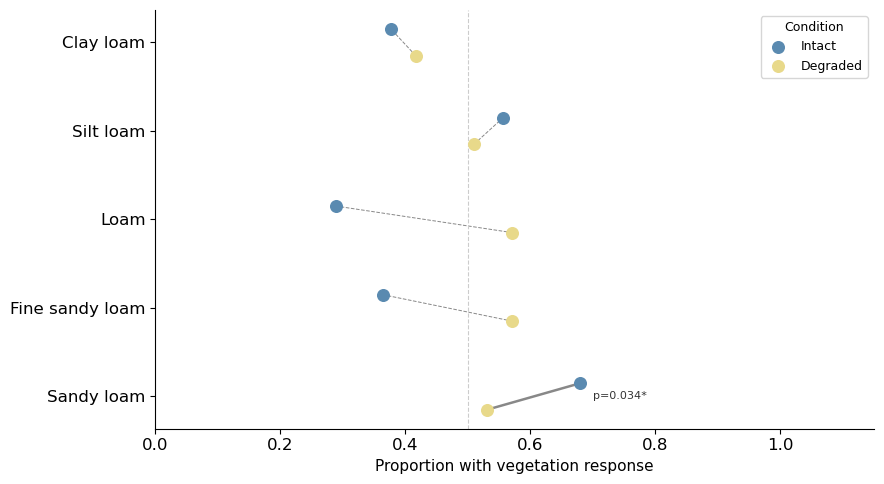

In [41]:
# ── Visualise: proportion effective by texture and berm condition ─────────────

# Merge p-values into summary for annotation
plot_df = summary.merge(
    results[["Texture", "p_value", "significant_0p05"]],
    on="Texture", how="left"
)

# Keep only textures with at least 50 combined samples
min_n = 50
tex_keep = plot_df.groupby("Texture")["count"].sum()
tex_keep = tex_keep[tex_keep >= min_n].index
plot_df = plot_df[plot_df["Texture"].isin(tex_keep)]

# Use the predefined texture order (finest → coarsest), filtered to what's in plot_df
# Append any textures present in data but not in texture_order (avoids ValueError)
_known = set(texture_order)
tex_order = [t for t in texture_order if t in plot_df["Texture"].values] + \
            [t for t in sorted(plot_df["Texture"].unique()) if t not in _known]

fig, ax = plt.subplots(figsize=(9, 5))

_clr = {"Intact": INTACT_COL, "Degraded": DEGRADED_COL}
dodge = {"Intact": -0.15, "Degraded": 0.15}

for grp, color in _clr.items():
    grp_df = plot_df[plot_df["Group"] == grp]
    y_pos = [tex_order.index(t) + dodge[grp] for t in grp_df["Texture"]]
    ax.scatter(grp_df["mean"], y_pos, color=color, s=70, zorder=3, label=grp)

# Connect paired dots with a line; bold + solid if significant
for tex in tex_order:
    row_i = plot_df[(plot_df["Texture"] == tex) & (plot_df["Group"] == "Intact")]
    row_d = plot_df[(plot_df["Texture"] == tex) & (plot_df["Group"] == "Degraded")]
    if row_i.empty or row_d.empty:
        continue
    yi = tex_order.index(tex)
    xi, xd = row_i["mean"].values[0], row_d["mean"].values[0]
    sig = row_i["significant_0p05"].values[0]
    lw = 1.8 if sig else 0.7
    ls = "-" if sig else "--"
    ax.plot([xd, xi], [yi + dodge["Degraded"], yi + dodge["Intact"]],
            color="#888888", linewidth=lw, linestyle=ls, zorder=2)
    if sig:
        p = row_i["p_value"].values[0]
        ax.text(max(xi, xd) + 0.02, yi, f"p={p:.3f}*",
                va="center", fontsize=8, color="#333333")

ax.set_yticks(range(len(tex_order)))
ax.set_yticklabels(tex_order)
ax.set_xlabel(f"Proportion with {LBL_EFFECTIVE.lower()}", fontsize=11)
ax.set_xlim(0, 1.15)
ax.invert_yaxis()
ax.axvline(0.5, color="#cccccc", linewidth=0.8, linestyle="--")
ax.legend(title="Condition", fontsize=9, title_fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


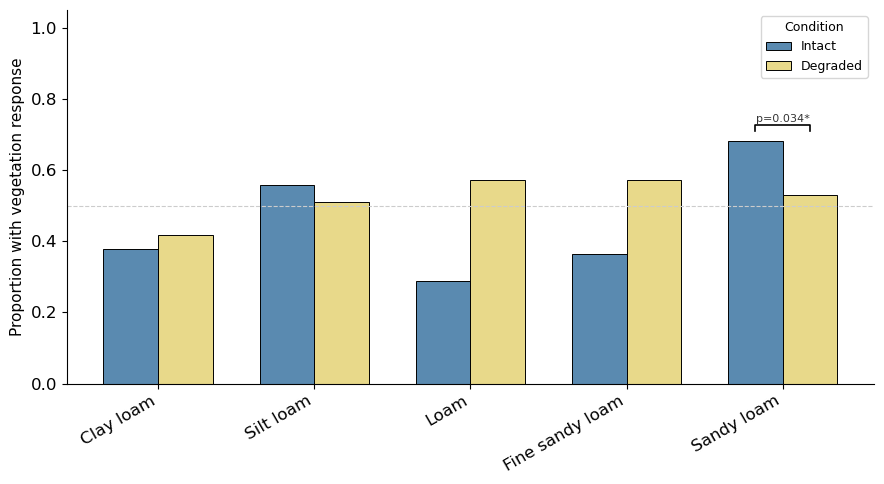

In [42]:
# ── Barplot version: proportion effective by texture and berm condition ────────
SHOW_COUNTS = False   # True → raw counts; False → proportions

# Reuse the same plot_df built above
_plot_bar = summary.merge(
    results[["Texture", "p_value", "significant_0p05"]],
    on="Texture", how="left"
)

# Keep only textures with at least 50 combined samples
_min_n = 50
_tex_keep = _plot_bar.groupby("Texture")["count"].sum()
_tex_keep = _tex_keep[_tex_keep >= _min_n].index
_plot_bar = _plot_bar[_plot_bar["Texture"].isin(_tex_keep)]

# For count mode, compute effective counts per group
if SHOW_COUNTS:
    _plot_bar = _plot_bar.copy()
    _plot_bar["eff_count"] = (_plot_bar["mean"] * _plot_bar["count"]).round().astype(int)

_known = set(texture_order)
_tex_order = [t for t in texture_order if t in _plot_bar["Texture"].values] + \
             [t for t in sorted(_plot_bar["Texture"].unique()) if t not in _known]

_n_tex = len(_tex_order)
_bar_w = 0.35
_x = np.arange(_n_tex)
_val_col = "eff_count" if SHOW_COUNTS else "mean"

fig, ax = plt.subplots(figsize=(9, 5))

_clr = {"Intact": INTACT_COL, "Degraded": DEGRADED_COL}

for i, (grp, color) in enumerate(_clr.items()):
    _grp_df = _plot_bar[_plot_bar["Group"] == grp].set_index("Texture")
    _vals = [_grp_df.loc[t, _val_col] if t in _grp_df.index else 0 for t in _tex_order]
    _offset = -_bar_w / 2 if i == 0 else _bar_w / 2
    ax.bar(_x + _offset, _vals, _bar_w, label=grp, color=color,
           edgecolor="black", linewidth=0.7)

# Add significance brackets
for j, tex in enumerate(_tex_order):
    _row_i = _plot_bar[(_plot_bar["Texture"] == tex) & (_plot_bar["Group"] == "Intact")]
    _row_d = _plot_bar[(_plot_bar["Texture"] == tex) & (_plot_bar["Group"] == "Degraded")]
    if _row_i.empty or _row_d.empty:
        continue
    _sig = _row_i["significant_0p05"].values[0]
    if _sig:
        _p = _row_i["p_value"].values[0]
        _top = max(_row_i[_val_col].values[0], _row_d[_val_col].values[0])
        _margin = 3 if SHOW_COUNTS else 0.03
        _bh = 2 if SHOW_COUNTS else 0.015
        ax.plot([_x[j] - _bar_w / 2, _x[j] - _bar_w / 2,
                 _x[j] + _bar_w / 2, _x[j] + _bar_w / 2],
                [_top + _margin, _top + _margin + _bh,
                 _top + _margin + _bh, _top + _margin],
                lw=1.2, color="black")
        ax.text(_x[j], _top + _margin + _bh + (_bh * 0.3), f"p={_p:.3f}*",
                ha="center", va="bottom", fontsize=8, color="#333333")

ax.set_xticks(_x)
ax.set_xticklabels(_tex_order, rotation=30, ha="right")

if SHOW_COUNTS:
    ax.set_ylabel(f"Count of berms with {LBL_EFFECTIVE.lower()}", fontsize=11)
else:
    ax.set_ylabel(f"Proportion with {LBL_EFFECTIVE.lower()}", fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color="#cccccc", linewidth=0.8, linestyle="--")

ax.legend(title="Condition", fontsize=9, title_fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## EOF analysis

In [43]:

# ── Exploratory Analysis: Intactness & Effectiveness by predictor ─────────────
# For each grouping variable, run chi-square + Cramér's V for both outcomes.

# ── Overall summary ──────────────────────────────────────────────────────────
_df_ea = df.dropna(subset=["Intact", "effective"]).copy()
_n_total = len(_df_ea)
_n_intact = int(_df_ea["Intact"].sum())

# effective column may be str (LBL_EFFECTIVE) or bool/int
_eff_series = _df_ea["effective"]
_eff_pos_vals = {LBL_EFFECTIVE, "Effective", "effective", True, 1, "1", "Yes", "yes"}
_n_effective = int(_eff_series.isin(_eff_pos_vals).sum())
if _n_effective == 0:
    _n_effective = int(_eff_series.astype(bool).sum())

print(f"Dataset: n = {_n_total}")
print(f"  Intact:    {_n_intact:3d} / {_n_total}  ({100*_n_intact/_n_total:.1f}%)")
print(f"  Effective: {_n_effective:3d} / {_n_total}  ({100*_n_effective/_n_total:.1f}%)\n")

# ── Per-predictor chi-square + Cramér's V ────────────────────────────────────
_ea_rows = []
for _var in GROUP_VARS:
    for _outcome, _lbl in [("Intact", "Intactness"), ("effective", "Effectiveness")]:
        _sub = _df_ea.dropna(subset=[_var, _outcome])
        if len(_sub) == 0:
            continue
        try:
            _res = analyze_outcome(_sub, group_col=_var, outcome_col=_outcome)
        except Exception as _e:
            print(f"  Skipped {_var} / {_lbl}: {_e}")
            continue
        _g = _res["global"]
        _ea_rows.append({
            "Predictor":   PRETTY_LABELS.get(_var, _var),
            "Outcome":     _lbl,
            "n":           len(_sub),
            "chi2":        round(_g["chi2"], 2),
            "dof":         int(_g["dof"]),
            "Cramér's V":  round(_g["cramers_v"], 3),
            "p_value":     round(_g["p_value"], 4),
            "sig":         "*" * sum([_g["p_value"] < t for t in [0.05, 0.01, 0.001]]) or "ns",
        })

_ea_df = pd.DataFrame(_ea_rows)

# ── Display split by outcome ──────────────────────────────────────────────────
for _out_lbl in ["Intactness", "Effectiveness"]:
    _sub_ea = _ea_df[_ea_df["Outcome"] == _out_lbl].sort_values("Cramér's V", ascending=False).reset_index(drop=True)
    print(f"{'═'*60}")
    print(f"  {_out_lbl}  — predictors ranked by Cramér's V")
    print(f"{'═'*60}")
    display(_sub_ea.drop(columns="Outcome"))

# ── Combined: significant predictors only ────────────────────────────────────
_sig_ea = _ea_df[_ea_df["p_value"] < 0.05].sort_values(["Outcome", "Cramér's V"], ascending=[True, False])
print(f"\n{'═'*60}")
print(f"  Significant predictors (p < 0.05) — both outcomes")
print(f"{'═'*60}")
if len(_sig_ea):
    display(_sig_ea.reset_index(drop=True))
else:
    print("  None")


Dataset: n = 743
  Intact:    432 / 743  (58.1%)
  Effective: 353 / 743  (47.5%)

════════════════════════════════════════════════════════════
  Intactness  — predictors ranked by Cramér's V
════════════════════════════════════════════════════════════


,Predictor,n,chi2,dof,Cramér's V,p_value,sig
0,Berm length class,743,35.82,1,0.220,0.0000,***
1,Soil texture,743,30.34,7,0.202,0.0001,***
2,Parent material,621,24.82,3,0.200,0.0000,***
3,Slope_Class,743,6.68,1,0.095,0.0098,**
4,Soil development,743,4.35,1,0.076,0.0371,*
5,Landform,743,3.64,2,0.070,0.1617,ns


════════════════════════════════════════════════════════════
  Effectiveness  — predictors ranked by Cramér's V
════════════════════════════════════════════════════════════


,Predictor,n,chi2,dof,Cramér's V,p_value,sig
0,Soil texture,743,27.38,7,0.192,0.0003,***
1,Slope_Class,743,26.88,1,0.190,0.0000,***
2,Parent material,621,21.26,3,0.185,0.0001,***
3,Landform,743,14.84,2,0.141,0.0006,***
4,Soil development,743,9.14,1,0.111,0.0025,**
5,Berm length class,743,0.19,1,0.016,0.6667,ns



════════════════════════════════════════════════════════════
  Significant predictors (p < 0.05) — both outcomes
════════════════════════════════════════════════════════════


,Predictor,Outcome,n,chi2,dof,Cramér's V,p_value,sig
0,Soil texture,Effectiveness,743,27.38,7,0.192,0.0003,***
1,Slope_Class,Effectiveness,743,26.88,1,0.190,0.0000,***
2,Parent material,Effectiveness,621,21.26,3,0.185,0.0001,***
3,Landform,Effectiveness,743,14.84,2,0.141,0.0006,***
4,Soil development,Effectiveness,743,9.14,1,0.111,0.0025,**
5,Berm length class,Intactness,743,35.82,1,0.220,0.0000,***
6,Soil texture,Intactness,743,30.34,7,0.202,0.0001,***
7,Parent material,Intactness,621,24.82,3,0.200,0.0000,***
8,Slope_Class,Intactness,743,6.68,1,0.095,0.0098,**
9,Soil development,Intactness,743,4.35,1,0.076,0.0371,*


Top 3 textures kept: ['Clay loam', 'Sandy loam', 'Silt loam']
n = 607 berms, 8 features after encoding
PC1: 37.7%   PC2: 29.6%   cumulative PC1-2: 67.3%
0 -0.1 Hillslope gradient (200 m)
1 -0.02 Flow accumulation (30 m)
2 0.01 Berm length


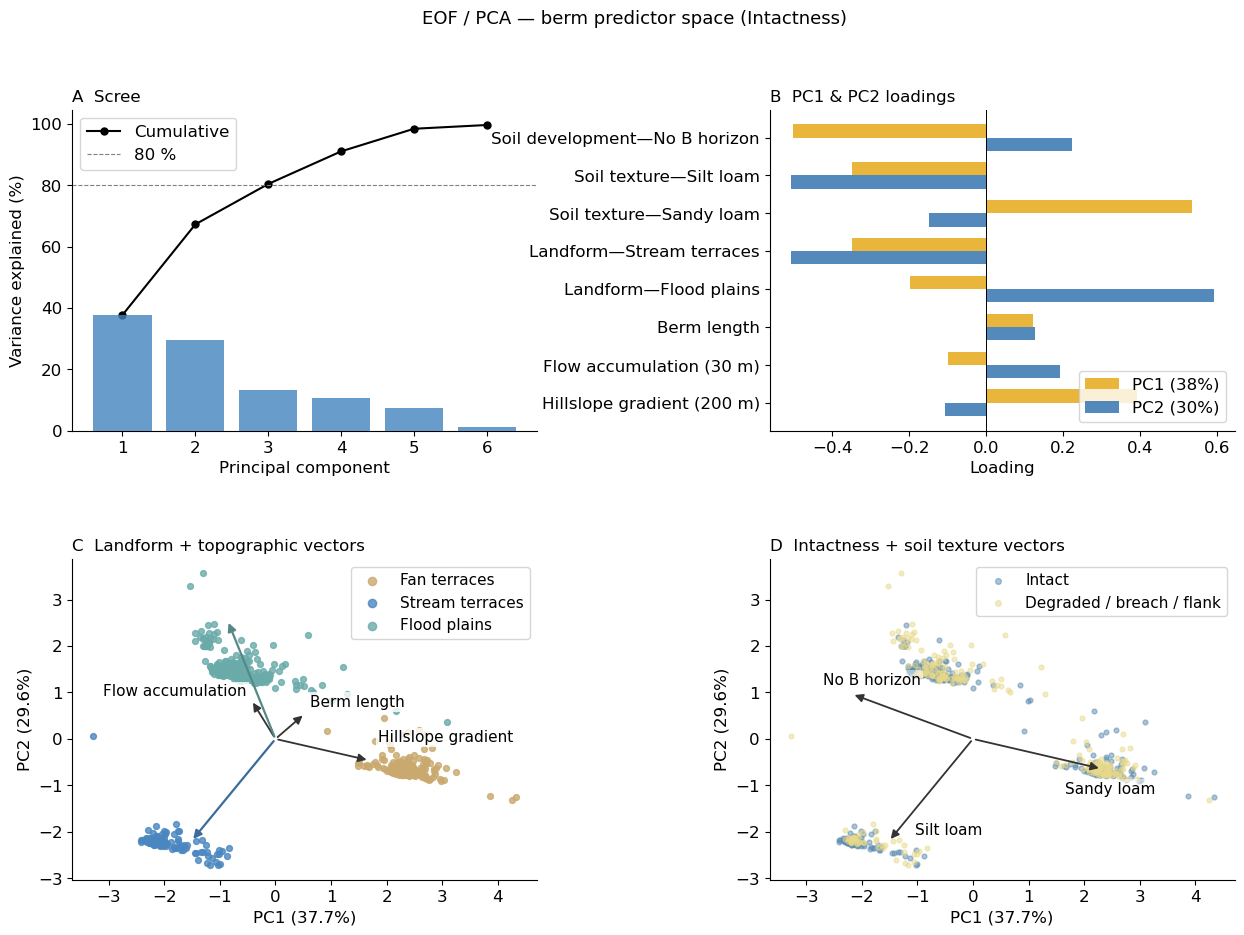

In [208]:
# ── EOF / PCA of berm predictor space — Intactness ────────────────────────────
# 3 numeric + 3 categorical predictors → features after one-hot encoding.
# Only the top 3 soil textures (by frequency) are included.
# Panels:
#   A. Scree plot
#   B. PC1 & PC2 loadings (side-by-side bars, grouped by variable)
#   C. Landform scatter + numeric (hillslope gradient, berm length, flow accum) arrows
#   D. Intactness scatter + soil texture & soil development arrows

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

_FS = 12  # uniform font size

# ── Colour scheme: yellow for PC1, blue for PC2 ──────────────────────────────
_CLR_PC1 = "#E6A817"   # gold-yellow
_CLR_PC2 = "#3676B0"   # medium blue

# ── 1. Predictors (kept simple: 3 numeric + 3 categorical) ───────────────────
_eof_preds_num = ["slope_200", "FA_30_max", "Shape_Leng"]
_eof_preds_cat = ["Landform", "Texture", "Soil_Development"]

_eof_cols = _eof_preds_num + _eof_preds_cat
_df_eof   = df.dropna(subset=_eof_cols + ["Intact"]).copy()

# ── Keep only the 3 most frequent soil textures ──────────────────────────────
_tex_counts = _df_eof["Texture"].value_counts()
_top3_tex   = _tex_counts.nlargest(3).index.tolist()
_df_eof     = _df_eof[_df_eof["Texture"].isin(_top3_tex)].copy()
print(f"Top 3 textures kept: {_top3_tex}")

_X_num    = _df_eof[_eof_preds_num].astype(float)
_X_cat    = pd.get_dummies(_df_eof[_eof_preds_cat], drop_first=True).astype(float)
_X        = pd.concat([_X_num, _X_cat], axis=1).fillna(0)
_feat_names = list(_X.columns)

# ── Build display labels: "Category — Level" for one-hot, pretty name for numeric
_feat_labels_clean = []
_feat_groups = []
for _fn in _feat_names:
    _matched = False
    for _prefix in _eof_preds_cat:
        if _fn.startswith(_prefix + "_"):
            _cat_val = _fn[len(_prefix) + 1:]
            _pretty_prefix = PRETTY_LABELS.get(_prefix, _prefix)
            _feat_labels_clean.append(f"{_pretty_prefix}—{_cat_val}")
            _feat_groups.append(_prefix)
            _matched = True
            break
    if not _matched:
        _feat_labels_clean.append(PRETTY_LABELS.get(_fn, _fn))
        _feat_groups.append("_numeric")

# ── Sort features: numeric first, then grouped by categorical variable ───────
_group_rank = {"_numeric": 0}
for _gi, _gc in enumerate(_eof_preds_cat):
    _group_rank[_gc] = _gi + 1

_sort_idx = sorted(range(len(_feat_names)),
                   key=lambda _i: (_group_rank.get(_feat_groups[_i], 99), _i))
_feat_names        = [_feat_names[_i] for _i in _sort_idx]
_feat_labels_clean = [_feat_labels_clean[_i] for _i in _sort_idx]
_feat_groups       = [_feat_groups[_i] for _i in _sort_idx]

# reorder X columns to match sorted order before PCA
_X = _X[_feat_names]

_X_scaled = StandardScaler().fit_transform(_X)

# ── 2. PCA ────────────────────────────────────────────────────────────────────
_n_comp   = min(_X_scaled.shape[1], 6)
_pca      = PCA(n_components=_n_comp, random_state=42)
_scores   = _pca.fit_transform(_X_scaled)
_var_exp  = _pca.explained_variance_ratio_
_cum_var  = np.cumsum(_var_exp)
_loadings = _pca.components_          # (n_comp, n_features)

_intact_flag = _df_eof["Intact"].astype(int).values

print(f"n = {_X_scaled.shape[0]} berms, {_X_scaled.shape[1]} features after encoding")
print(f"PC1: {_var_exp[0]*100:.1f}%   PC2: {_var_exp[1]*100:.1f}%"
      f"   cumulative PC1-2: {_cum_var[1]*100:.1f}%")

# ── 3. Plot ───────────────────────────────────────────────────────────────────
_fig, _axes = plt.subplots(2, 2, figsize=(15, 10))
(_ax_scree, _ax_load), (_ax_sc, _ax_bi) = _axes
_fig.subplots_adjust(hspace=0.4, wspace=0.5)

# ── A: Scree ──────────────────────────────────────────────────────────────────
_comps = np.arange(1, _n_comp + 1)
_ax_scree.bar(_comps, _var_exp * 100, color=MODEL_CLR_CONDITION, alpha=0.8, zorder=3)
_ax_scree.plot(_comps, _cum_var * 100, color="black", marker="o", lw=1.5, ms=5,
               label="Cumulative")
_ax_scree.axhline(80, color="grey", lw=0.8, ls="--", label="80 %")
_ax_scree.set_xlabel("Principal component", fontsize=_FS)
_ax_scree.set_ylabel("Variance explained (%)", fontsize=_FS)
_ax_scree.set_title("A  Scree", fontsize=_FS, loc="left")
_ax_scree.set_xticks(_comps)
_ax_scree.tick_params(labelsize=_FS)
_ax_scree.legend(fontsize=_FS)
_ax_scree.spines[["top", "right"]].set_visible(False)

# ── B: PC1 and PC2 loadings side by side (grouped by variable) ───────────────
_n_feat   = len(_feat_names)
_bar_h    = 0.35
_y        = np.arange(_n_feat)
_load1    = _loadings[0]
_load2    = _loadings[1]
_ax_load.barh(_y + _bar_h / 2, _load1, _bar_h,
              color=_CLR_PC1, alpha=0.85,
              label=f"PC1 ({_var_exp[0]*100:.0f}%)")
_ax_load.barh(_y - _bar_h / 2, _load2, _bar_h,
              color=_CLR_PC2, alpha=0.85,
              label=f"PC2 ({_var_exp[1]*100:.0f}%)")
_ax_load.set_yticks(_y)
_ax_load.set_yticklabels(_feat_labels_clean, fontsize=_FS)
_ax_load.axvline(0, color="black", lw=0.7)

_ax_load.set_xlabel("Loading", fontsize=_FS)
_ax_load.set_title("B  PC1 & PC2 loadings", fontsize=_FS, loc="left")
_ax_load.tick_params(labelsize=_FS)
_ax_load.legend(fontsize=_FS, loc="lower right")
_ax_load.spines[["top", "right"]].set_visible(False)

# ── C: Biplot — Landform (scatter) + numeric loading arrows ───────────────────
_lf_vals = _df_eof["Landform"].values
for _lf in lf_order:
    _mask = _lf_vals == _lf
    if _mask.any():
        _ax_sc.scatter(_scores[_mask, 0], _scores[_mask, 1],
                       c=LF_COLORS.get(_lf, "#999999"), alpha=0.80, s=18,
                       label=_lf, rasterized=True)

_scale = np.abs(_scores[:, :2]).max() * 1

# ── Manual label offsets for panel C (dx, dy in data coords) ─────────────────
# Tweak these values to move individual labels.
_c_label_offsets = {
    "Hillslope gradient (200 m)": (-0.1, 0.4),
    "Berm length":                (0.01,  0.01),
    "Flow accumulation (30 m)":   (-0.02,  -0.1),
}

for _k in range(_n_feat):
    if _feat_groups[_k] != "_numeric":
        continue
    _lx = _loadings[0, _k] * _scale
    _ly = _loadings[1, _k] * _scale
    _ax_sc.annotate("", xy=(_lx, _ly), xytext=(0, 0),
                    arrowprops=dict(arrowstyle="-|>", color="#333333", lw=1.3))
    _lbl = _feat_labels_clean[_k].replace(" (30 m)", "")\
                    .replace(" (200 m)", "")
    
    
    _dx, _dy = _c_label_offsets.get(_feat_labels_clean[_k], (0, 0))
    _tx, _ty = _lx * 1.15 + _dx, _ly * 1.15 + _dy
    print(_k, _dx, _feat_labels_clean[_k])
    _ha = "left" if _tx >= _lx else "right"
    _va = "bottom" if _ty >= _ly else "top"
    _ax_sc.text(_tx, _ty, _lbl,
                fontsize=_FS - 1, ha=_ha, va=_va,
                bbox=dict(fc="white", ec="none", alpha=0.8, pad=1.5))

# ── Landform loading arrows (darker shade of legend colour, no labels) ────────
import matplotlib.colors as _mcolors
def _darken(hex_clr, factor=0.8):
    """Return a darker version of hex_clr (factor < 1 → darker)."""
    r, g, b = _mcolors.to_rgb(hex_clr)
    return _mcolors.to_hex((r * factor, g * factor, b * factor))

for _k in range(_n_feat):
    if _feat_groups[_k] != "Landform":
        continue
    _lf_name = _feat_names[_k].replace("Landform_", "")
    _lf_clr  = _darken(LF_COLORS.get(_lf_name, "#999999"))
    _lx = _loadings[0, _k] * _scale
    _ly = _loadings[1, _k] * _scale
    _ax_sc.annotate("", xy=(_lx, _ly), xytext=(0, 0),
                    arrowprops=dict(arrowstyle="-|>", color=_lf_clr, lw=1.6))

_ax_sc.set_xlabel(f"PC1 ({_var_exp[0]*100:.1f}%)", fontsize=_FS)
_ax_sc.set_ylabel(f"PC2 ({_var_exp[1]*100:.1f}%)", fontsize=_FS)
_ax_sc.set_title("C  Landform + topographic vectors", fontsize=_FS, loc="left")
_ax_sc.tick_params(labelsize=_FS)
_ax_sc.legend(fontsize=_FS - 1, markerscale=1.4)
_ax_sc.spines[["top", "right"]].set_visible(False)

# ── D: Biplot — Intactness (scatter) + soil texture & development arrows ──────
for _val, _lbl, _clr in [(1, "Intact", INTACT_COL),
                          (0, "Degraded / breach / flank", DEGRADED_COL)]:
    _mask = _intact_flag == _val
    _ax_bi.scatter(_scores[_mask, 0], _scores[_mask, 1],
                   c=_clr, alpha=0.5, s=12, label=_lbl, rasterized=True)

_bi_texts = []
# ── Manual label offsets for panel D (dx, dy in data coords) ─────────────────
# Tweak these values to move individual labels.
_d_label_offsets = {
    "Soil texture—Sandy loam":          (-1,  -0.5),
    "Soil texture—Silt loam":           (0.7,  0.4),
    "Soil development—No B horizon":    (-0.2,   0),
}

for _k in range(_n_feat):
    if _feat_groups[_k] in ("_numeric", "Landform"):
        continue
    _lx = _loadings[0, _k] * _scale
    _ly = _loadings[1, _k] * _scale
    _ax_bi.annotate("", xy=(_lx, _ly), xytext=(0, 0),
                    arrowprops=dict(arrowstyle="-|>", color="#333333", lw=1.3))
    _lbl_full = _feat_labels_clean[_k]
    _lbl = _lbl_full.split("—", 1)[-1]   # strip "Soil texture—" / "Soil development—"
    _dx, _dy = _d_label_offsets.get(_lbl_full, (0, 0))
    _tx, _ty = _lx * 1.15 + _dx, _ly * 1.15 + _dy
    _ha = "left" #if _tx >= _lx else "right"
    _va = "bottom"# if _ty >= _ly else "top"
    _ax_bi.text(_tx, _ty, _lbl,
                fontsize=_FS - 1, ha=_ha, va=_va,
                bbox=dict(fc="white", ec="none", alpha=0.5, pad=1.5))

_ax_bi.set_xlabel(f"PC1 ({_var_exp[0]*100:.1f}%)", fontsize=_FS)
_ax_bi.set_ylabel(f"PC2 ({_var_exp[1]*100:.1f}%)", fontsize=_FS)
_ax_bi.set_title("D  Intactness + soil texture vectors", fontsize=_FS, loc="left")
_ax_bi.tick_params(labelsize=_FS)
_ax_bi.legend(fontsize=_FS - 1, markerscale=1.2)
_ax_bi.spines[["top", "right"]].set_visible(False)

plt.suptitle("EOF / PCA — berm predictor space (Intactness)", fontsize=_FS + 1)
plt.show()

### Interpretation — EOF/PCA of berm predictor space (Intactness)

**Overall structure (Panels A & B).** Two principal components together explain ~67 % of the variance in the 8-feature predictor space (PC1 ≈ 38 %, PC2 ≈ 30 %; see Panel A). The dominant axis (PC1) is loaded most strongly by landform membership — fan terrace and stream terrace have large positive loadings, while flood plains and flood plains / alluvial fan transitions load negatively — indicating that the primary axis of berm variation corresponds to geomorphic setting. PC2 is driven mainly by topographic variables (hillslope gradient and flow accumulation) with secondary contributions from soil texture.

**Landform separation (Panel C).** Berms on fan terraces and stream terraces (warm colours) cluster toward positive PC1 scores, whereas flood-plain and transitional berms (cool colours) occupy the negative-PC1 half of the scatter. The coloured loading arrows confirm this: fan-terrace and stream-terrace arrows point right (positive PC1) and the flood-plain arrow points left. Vertical spread along PC2 within each landform reflects variation in topographic context — berms with high hillslope gradient or high flow accumulation plot higher or lower along this axis. Berm length loads weakly and is roughly orthogonal to the landform axis, implying it varies independently of setting.

**Intactness signal (Panel D).** Intact (filled circles) and degraded/breach/flank berms do not form tightly distinct clouds in PC1–PC2 space, suggesting that intactness is not simply a function of the predictor combinations captured by the first two components. There is a subtle tendency for intact berms to occur across a wider range of PC2 values, whereas degraded berms show slightly elevated representation at positive PC1 (fan / stream terrace settings). Sandy loam and silt loam soil texture arrows point in slightly different directions, reflecting their different relationships with the landform–topography axes; "No B horizon" (weak soil development) points modestly toward negative PC2, consistent with shallower, coarser substrates on steeper slopes.

**Summary.** The predictor space is organised primarily by landform (PC1) and topography / texture (PC2). Intactness does not cluster cleanly along either axis, implying that structural outcome is a higher-order interaction of environmental conditions rather than a direct gradient in any single predictor.

Top 3 textures kept: ['Clay loam', 'Sandy loam', 'Silt loam']
n = 607 berms, 8 features after encoding
PC1: 37.7%   PC2: 29.6%   cumulative PC1-2: 67.3%


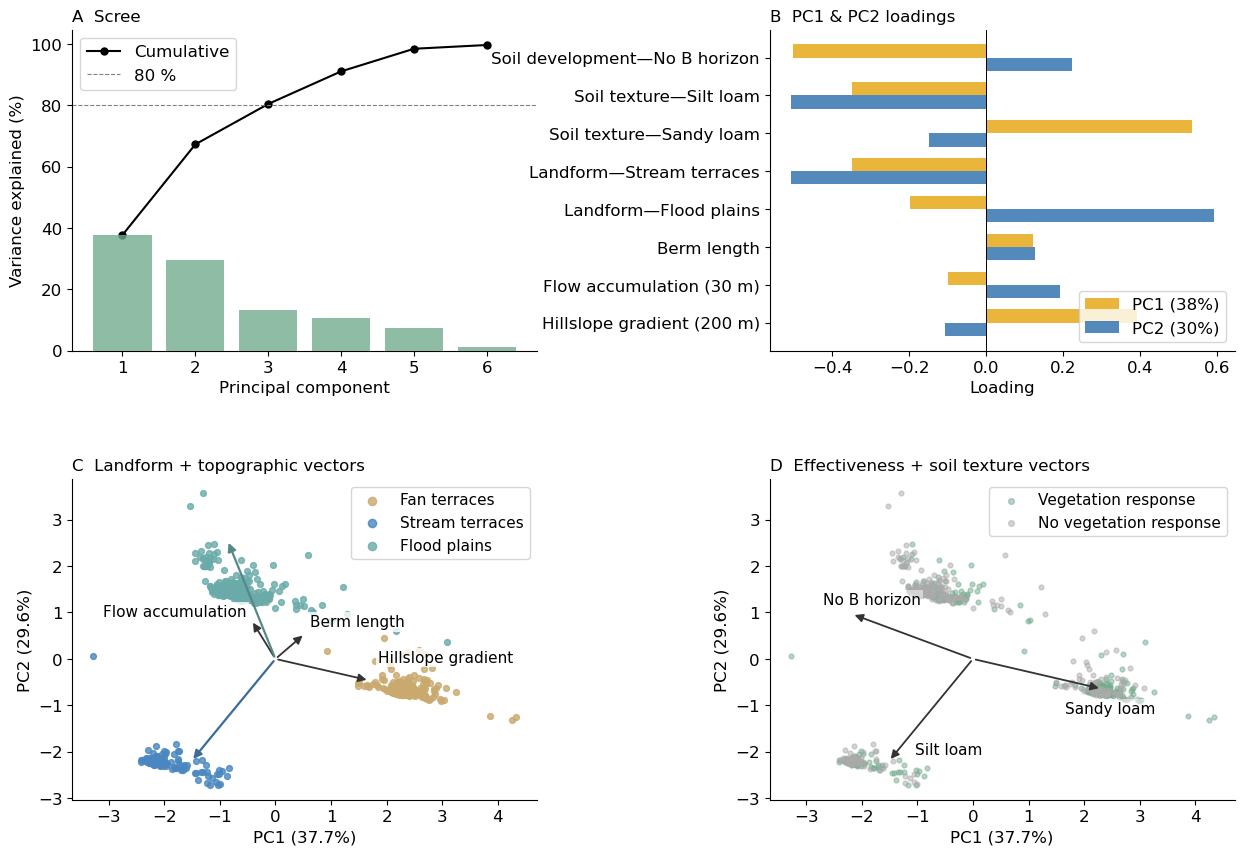

In [210]:
# ── EOF / PCA of berm predictor space — Vegetation-response Effectiveness ─────
# Same predictor set as the Intactness EOF above (3 numeric + 3 categorical).
# Only the top 3 soil textures (by frequency) are included.
# Panels:
#   A. Scree plot
#   B. PC1 & PC2 loadings (side-by-side bars, grouped by variable)
#   C. Landform scatter + numeric (hillslope gradient, berm length, flow accum) arrows
#   D. Effectiveness scatter + soil texture & soil development arrows

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.colors as _mcolors

_FS = 12

_CLR_PC1 = "#E6A817"
_CLR_PC2 = "#3676B0"

# ── 1. Predictors ─────────────────────────────────────────────────────────────
_eof_preds_num = ["slope_200", "FA_30_max", "Shape_Leng"]
_eof_preds_cat = ["Landform", "Texture", "Soil_Development"]
_eff_outcome_col = "effective"          # 1 = effective, 0 = ineffective (boolean/float)

_eof_cols_eff = _eof_preds_num + _eof_preds_cat
# Filter to berms with actual vegetation-response measurements (effect_percent not NaN).
# 'effective' defaults to False for all rows, so dropna on it keeps the full dataset;
# filtering on effect_percent gives only measured berms — a genuinely different subset.
_df_eof_eff   = df.dropna(subset=_eof_cols_eff + ["effect_percent"]).copy()

# ── Keep only the 3 most frequent soil textures ──────────────────────────────
_tex_counts_eff = _df_eof_eff["Texture"].value_counts()
_top3_tex_eff   = _tex_counts_eff.nlargest(3).index.tolist()
_df_eof_eff     = _df_eof_eff[_df_eof_eff["Texture"].isin(_top3_tex_eff)].copy()
print(f"Top 3 textures kept: {_top3_tex_eff}")

_X_num_e = _df_eof_eff[_eof_preds_num].astype(float)
_X_cat_e = pd.get_dummies(_df_eof_eff[_eof_preds_cat], drop_first=True).astype(float)
_X_e     = pd.concat([_X_num_e, _X_cat_e], axis=1).fillna(0)
_feat_names_e = list(_X_e.columns)

# ── Build display labels ──────────────────────────────────────────────────────
_feat_labels_e = []
_feat_groups_e = []
for _fn in _feat_names_e:
    _matched = False
    for _prefix in _eof_preds_cat:
        if _fn.startswith(_prefix + "_"):
            _cat_val = _fn[len(_prefix) + 1:]
            _pretty_prefix = PRETTY_LABELS.get(_prefix, _prefix)
            _feat_labels_e.append(f"{_pretty_prefix}—{_cat_val}")
            _feat_groups_e.append(_prefix)
            _matched = True
            break
    if not _matched:
        _feat_labels_e.append(PRETTY_LABELS.get(_fn, _fn))
        _feat_groups_e.append("_numeric")

# ── Sort features: numeric first, then grouped by categorical variable ───────
_group_rank_e = {"_numeric": 0}
for _gi, _gc in enumerate(_eof_preds_cat):
    _group_rank_e[_gc] = _gi + 1

_sort_idx_e   = sorted(range(len(_feat_names_e)),
                       key=lambda _i: (_group_rank_e.get(_feat_groups_e[_i], 99), _i))
_feat_names_e  = [_feat_names_e[_i]  for _i in _sort_idx_e]
_feat_labels_e = [_feat_labels_e[_i] for _i in _sort_idx_e]
_feat_groups_e = [_feat_groups_e[_i] for _i in _sort_idx_e]
_X_e = _X_e[_feat_names_e]

_X_scaled_e = StandardScaler().fit_transform(_X_e)

# ── 2. PCA ────────────────────────────────────────────────────────────────────
_n_comp_e   = min(_X_scaled_e.shape[1], 6)
_pca_e      = PCA(n_components=_n_comp_e, random_state=42)
_scores_e   = _pca_e.fit_transform(_X_scaled_e)
_var_exp_e  = _pca_e.explained_variance_ratio_
_cum_var_e  = np.cumsum(_var_exp_e)
_loadings_e = _pca_e.components_

_eff_flag = (_df_eof_eff["effect_percent"] > 7).astype(int).values

print(f"n = {_X_scaled_e.shape[0]} berms, {_X_scaled_e.shape[1]} features after encoding")
print(f"PC1: {_var_exp_e[0]*100:.1f}%   PC2: {_var_exp_e[1]*100:.1f}%"
      f"   cumulative PC1-2: {_cum_var_e[1]*100:.1f}%")

# ── 3. Plot ───────────────────────────────────────────────────────────────────
_fig_e, _axes_e = plt.subplots(2, 2, figsize=(15, 10))
(_ax_scree_e, _ax_load_e), (_ax_sc_e, _ax_bi_e) = _axes_e
_fig_e.subplots_adjust(hspace=0.4, wspace=0.5)

# ── A: Scree ──────────────────────────────────────────────────────────────────
_comps_e = np.arange(1, _n_comp_e + 1)
_ax_scree_e.bar(_comps_e, _var_exp_e * 100, color=MODEL_CLR_VEGRESPONSE, alpha=0.8, zorder=3)
_ax_scree_e.plot(_comps_e, _cum_var_e * 100, color="black", marker="o", lw=1.5, ms=5,
                 label="Cumulative")
_ax_scree_e.axhline(80, color="grey", lw=0.8, ls="--", label="80 %")
_ax_scree_e.set_xlabel("Principal component", fontsize=_FS)
_ax_scree_e.set_ylabel("Variance explained (%)", fontsize=_FS)
_ax_scree_e.set_title("A  Scree", fontsize=_FS, loc="left")
_ax_scree_e.set_xticks(_comps_e)
_ax_scree_e.tick_params(labelsize=_FS)
_ax_scree_e.legend(fontsize=_FS)
_ax_scree_e.spines[["top", "right"]].set_visible(False)

# ── B: PC1 and PC2 loadings side by side ─────────────────────────────────────
_n_feat_e = len(_feat_names_e)
_bar_h_e  = 0.35
_y_e      = np.arange(_n_feat_e)
_load1_e  = _loadings_e[0]
_load2_e  = _loadings_e[1]
_ax_load_e.barh(_y_e + _bar_h_e / 2, _load1_e, _bar_h_e,
                color=_CLR_PC1, alpha=0.85,
                label=f"PC1 ({_var_exp_e[0]*100:.0f}%)")
_ax_load_e.barh(_y_e - _bar_h_e / 2, _load2_e, _bar_h_e,
                color=_CLR_PC2, alpha=0.85,
                label=f"PC2 ({_var_exp_e[1]*100:.0f}%)")
_ax_load_e.set_yticks(_y_e)
_ax_load_e.set_yticklabels(_feat_labels_e, fontsize=_FS)
_ax_load_e.axvline(0, color="black", lw=0.7)
_ax_load_e.set_xlabel("Loading", fontsize=_FS)
_ax_load_e.set_title("B  PC1 & PC2 loadings", fontsize=_FS, loc="left")
_ax_load_e.tick_params(labelsize=_FS)
_ax_load_e.legend(fontsize=_FS, loc="lower right")
_ax_load_e.spines[["top", "right"]].set_visible(False)

# ── C: Biplot — Landform scatter + numeric arrows ─────────────────────────────
_lf_vals_e = _df_eof_eff["Landform"].values
for _lf in lf_order:
    _mask = _lf_vals_e == _lf
    if _mask.any():
        _ax_sc_e.scatter(_scores_e[_mask, 0], _scores_e[_mask, 1],
                         c=LF_COLORS.get(_lf, "#999999"), alpha=0.80, s=18,
                         label=_lf, rasterized=True)

_scale_e = np.abs(_scores_e[:, :2]).max() * 1

_c_label_offsets_e = {
    "Hillslope gradient (200 m)": (-0.1, 0.4),
    "Berm length":                (0.01,  0.01),
    "Flow accumulation (30 m)":   (-0.02, -0.1),
}

for _k in range(_n_feat_e):
    if _feat_groups_e[_k] != "_numeric":
        continue
    _lx = _loadings_e[0, _k] * _scale_e
    _ly = _loadings_e[1, _k] * _scale_e
    _ax_sc_e.annotate("", xy=(_lx, _ly), xytext=(0, 0),
                      arrowprops=dict(arrowstyle="-|>", color="#333333", lw=1.3))
    _lbl = _feat_labels_e[_k].replace(" (30 m)", "").replace(" (200 m)", "")
    _dx, _dy = _c_label_offsets_e.get(_feat_labels_e[_k], (0, 0))
    _tx, _ty = _lx * 1.15 + _dx, _ly * 1.15 + _dy
    _ha = "left" if _tx >= _lx else "right"
    _va = "bottom" if _ty >= _ly else "top"
    _ax_sc_e.text(_tx, _ty, _lbl,
                  fontsize=_FS - 1, ha=_ha, va=_va,
                  bbox=dict(fc="white", ec="none", alpha=0.8, pad=1.5))

# Landform loading arrows (darker shade of legend colour, no labels)
def _darken_e(hex_clr, factor=0.8):
    r, g, b = _mcolors.to_rgb(hex_clr)
    return _mcolors.to_hex((r * factor, g * factor, b * factor))

for _k in range(_n_feat_e):
    if _feat_groups_e[_k] != "Landform":
        continue
    _lf_name = _feat_names_e[_k].replace("Landform_", "")
    _lf_clr  = _darken_e(LF_COLORS.get(_lf_name, "#999999"))
    _lx = _loadings_e[0, _k] * _scale_e
    _ly = _loadings_e[1, _k] * _scale_e
    _ax_sc_e.annotate("", xy=(_lx, _ly), xytext=(0, 0),
                      arrowprops=dict(arrowstyle="-|>", color=_lf_clr, lw=1.6))

_ax_sc_e.set_xlabel(f"PC1 ({_var_exp_e[0]*100:.1f}%)", fontsize=_FS)
_ax_sc_e.set_ylabel(f"PC2 ({_var_exp_e[1]*100:.1f}%)", fontsize=_FS)
_ax_sc_e.set_title("C  Landform + topographic vectors", fontsize=_FS, loc="left")
_ax_sc_e.tick_params(labelsize=_FS)
_ax_sc_e.legend(fontsize=_FS - 1, markerscale=1.4)
_ax_sc_e.spines[["top", "right"]].set_visible(False)

# ── D: Biplot — Effectiveness scatter + soil arrows ───────────────────────────
_eff_lbl    = LBL_EFFECTIVE
_ineff_lbl  = LBL_INEFFECTIVE
for _val, _lbl, _clr in [(1, _eff_lbl,   MODEL_CLR_VEGRESPONSE),
                          (0, _ineff_lbl, MODEL_CLR_CHANCE)]:
    _mask = _eff_flag == _val
    _ax_bi_e.scatter(_scores_e[_mask, 0], _scores_e[_mask, 1],
                     c=_clr, alpha=0.5, s=12, label=_lbl, rasterized=True)

_d_label_offsets_e = {
    "Soil texture—Sandy loam":          (-1,   -0.5),
    "Soil texture—Silt loam":           (0.7,   0.4),
    "Soil development—No B horizon":    (-0.2,  0.0),
}

for _k in range(_n_feat_e):
    if _feat_groups_e[_k] in ("_numeric", "Landform"):
        continue
    _lx = _loadings_e[0, _k] * _scale_e
    _ly = _loadings_e[1, _k] * _scale_e
    _ax_bi_e.annotate("", xy=(_lx, _ly), xytext=(0, 0),
                      arrowprops=dict(arrowstyle="-|>", color="#333333", lw=1.3))
    _lbl_full = _feat_labels_e[_k]
    _lbl_short = _lbl_full.split("—", 1)[-1]
    _dx, _dy = _d_label_offsets_e.get(_lbl_full, (0, 0))
    _tx, _ty = _lx * 1.15 + _dx, _ly * 1.15 + _dy
    _ax_bi_e.text(_tx, _ty, _lbl_short,
                  fontsize=_FS - 1, ha="left", va="bottom",
                  bbox=dict(fc="white", ec="none", alpha=0.5, pad=1.5))

_ax_bi_e.set_xlabel(f"PC1 ({_var_exp_e[0]*100:.1f}%)", fontsize=_FS)
_ax_bi_e.set_ylabel(f"PC2 ({_var_exp_e[1]*100:.1f}%)", fontsize=_FS)
_ax_bi_e.set_title("D  Effectiveness + soil texture vectors", fontsize=_FS, loc="left")
_ax_bi_e.tick_params(labelsize=_FS)
_ax_bi_e.legend(fontsize=_FS - 1, markerscale=1.2)
_ax_bi_e.spines[["top", "right"]].set_visible(False)


# plt.suptitle("EOF / PCA — berm predictor space (Vegetation-response Effectiveness)",plt.show()
#              fontsize=_FS + 1)

## Feature selection, model comparison

here I'd like to fit a logistic regression and a random forest to predict intactness, do a feature selection to obtain the best models, 
and then train alternative models with the 

In [45]:
# here I'd like to fit a logistic regression and a random forest to predict intactness, do a feature selection to obtain the best models, 
# and then train alternative models with the 

In [116]:
import os
from analysis import _unique_preserve, fit_rf_binary

# ── predictor scenario definitions ───────────────────────────────────────────
treat_as = {
    "Shape_Leng": "numeric",
    "High_Clay":  "categorical",
}

_geo_preds  = ["Landform", "slope_200", "FA_30_max"]
_soil_preds = ["Texture", "Soil_Development", "TypicalProfile"]
_len_preds  = ["Shape_Leng", "Berm_Length_Class"]
_all_preds  = _unique_preserve(_geo_preds + _soil_preds + _len_preds)

scenario_predictors = {
    "landscape_geomorphology_only": _geo_preds,
    "soil_only":                    _soil_preds,
    "shape_length_only":            _len_preds,
    "all_predictors":               _all_preds,
}

_targets = ["Intact", "Effective"]

# ── run all scenarios ─────────────────────────────────────────────────────────
os.makedirs("../data/summary", exist_ok=True)
results_txt = "../data/summary/scenario_model_results.txt"
summary_rows = []
_log_lines = []

for _scenario_name, _preds in scenario_predictors.items():
    _preds_run = [p for p in _preds if p in df.columns]
    if not _preds_run:
        print(f"Skipping '{_scenario_name}': no predictors found in df.columns")
        continue
    for _target in _targets:
        _log_lines.append(f"\n\n######## {_scenario_name} / {_target} ########")
        _log_lines.append(f"Predictors: {_preds_run}")
        try:
            _model, _metrics, _pi = fit_rf_binary(
                df, y=_target, predictors=_preds_run, treat_as=treat_as
            )
        except Exception as _e:
            _log_lines.append(f"  SKIP: {_e}")
            print(f"Skipping '{_scenario_name}' / {_target}: {_e}")
            continue

        _top3 = ", ".join(_pi.head(min(3, len(_pi))).index.tolist())
        _log_lines.append(
            f"  cv_auc = {_metrics['cv']['auc'][0]:.4f} ± {_metrics['cv']['auc'][1]:.4f}"
            f"  top3 = {_top3}"
        )
        summary_rows.append({
            "scenario":        _scenario_name,
            "target":          _target,
            "cv_auc_mean":     _metrics["cv"]["auc"][0],
            "cv_auc_sd":       _metrics["cv"]["auc"][1],
            "holdout_auc":     _metrics["holdout"]["auc"],
            "cv_bal_acc_mean": _metrics["cv"]["bal_acc"][0],
            "cv_f1_mean":      _metrics["cv"]["f1"][0],
            "top_3_predictors": _top3,
            "n":               _metrics["n"],
            "n_predictors":    len(_preds_run),
        })

with open(results_txt, "w") as _f:
    _f.write("\n".join(_log_lines))

print(f"Done — {len(summary_rows)} scenario/target combinations run.")
print(f"Results saved to {results_txt}")

Done — 8 scenario/target combinations run.
Results saved to ../data/summary/scenario_model_results.txt


In [136]:
# ── Create binary predictor versions for simplified RF ────────────────────────
# Binary versions: high vs low slope, long vs short berm
df_binary = df.copy()

# Create binary slope (using median as threshold)
slope_median = df_binary['slope_200'].median()
df_binary['High_Slope'] = (df_binary['slope_200'] > slope_median).astype(str)
df_binary.loc[df_binary['slope_200'] > slope_median, 'High_Slope'] = 'High slope'
df_binary.loc[df_binary['slope_200'] <= slope_median, 'High_Slope'] = 'Low slope'

# Create binary length (using median as threshold)
length_median = df_binary['Shape_Leng'].median()
df_binary['Long_Berm'] = (df_binary['Shape_Leng'] > length_median).astype(str)
df_binary.loc[df_binary['Shape_Leng'] > length_median, 'Long_Berm'] = 'Long'
df_binary.loc[df_binary['Shape_Leng'] <= length_median, 'Long_Berm'] = 'Short'

print(f"Binary predictors created:")
print(f"  Slope median: {slope_median:.2f} → High_Slope")
print(f"  Length median: {length_median:.1f} → Long_Berm")
print(f"\nHigh_Slope distribution:")
print(df_binary['High_Slope'].value_counts())
print(f"\nLong_Berm distribution:")
print(df_binary['Long_Berm'].value_counts())

Binary predictors created:
  Slope median: 1.89 → High_Slope
  Length median: 60.3 → Long_Berm

High_Slope distribution:
High_Slope
Low slope     372
High slope    371
Name: count, dtype: int64

Long_Berm distribution:
Long_Berm
Short    372
Long     371
Name: count, dtype: int64


### Random Forest Comparison: Full vs Binary Predictors

We train two random forests for comparison:
1. **Full model**: All continuous and categorical predictors
2. **Binary model**: Simplified binary versions (high/low slope, long/short berm, categorical landform and soil)
   
This comparison helps interpret the random forest feature importance by showing whether simplified binary predictors capture the main signal.

In [48]:
# ── Train RF with FULL predictors (all_predictors) ──────────────────────────
full_predictors = scenario_predictors["all_predictors"]
full_treat_as = {
    "Shape_Leng": "numeric",
    "High_Clay":  "categorical",
}

results_full = {}
for target in ["Intact", "Effective"]:
    print(f"\n{'='*60}")
    print(f"Training FULL model for {target}")
    print(f"{'='*60}")
    model_full, metrics_full, importance_full = fit_rf_binary(
        df, y=target, predictors=full_predictors, treat_as=full_treat_as
    )
    results_full[target] = {
        "model": model_full,
        "metrics": metrics_full,
        "importance": importance_full,
        "predictors": full_predictors
    }
    print(f"Full model CV AUC: {metrics_full['cv']['auc'][0]:.3f} ± {metrics_full['cv']['auc'][1]:.3f}")
    print(f"Top 3 predictors: {', '.join(importance_full.head(3).index.tolist())}")


Training FULL model for Intact
Full model CV AUC: 0.728 ± 0.011
Top 3 predictors: FA_30_max, Shape_Leng, slope_200

Training FULL model for Effective
Full model CV AUC: 0.652 ± 0.044
Top 3 predictors: slope_200, Berm_Length_Class, Texture


### Random Forest Comparison: Full vs Binary Predictors

We train two random forests for comparison:
1. **Full model**: All continuous and categorical predictors (slope_200, Shape_Leng, landform, soil texture, etc.)
2. **Binary model**: Simplified binary versions (high/low slope, long/short berm, plus key categorical variables)
   
This comparison helps interpret the random forest feature importance by testing whether simplified binary predictors capture the main signal, allowing clearer interpretation of which factors drive berm outcomes.

In [194]:
# ── Train RF with BINARY predictors (simplified) ───────────────────────────
# Use simplified binary predictors: High_Slope, Long_Berm, plus key categoricals
binary_predictors = [
    "High_Slope",     # binary: high vs low slope
    "Long_Berm",      # binary: long vs short berm
    "Landform",       # categorical (already 3 levels)
    "Soil_Development",  # categorical (2 levels)
    "Texture",        # categorical
]

binary_treat_as = {}  # all categorical for binary model

results_binary = {}
for target in ["Intact", "Effective"]:
    print(f"\n{'='*60}")
    print(f"Training BINARY model for {target}")
    print(f"{'='*60}")
    model_binary, metrics_binary, importance_binary = fit_rf_binary(
        df_binary, y=target, predictors=binary_predictors, treat_as=binary_treat_as
    )
    results_binary[target] = {
        "model": model_binary,
        "metrics": metrics_binary,
        "importance": importance_binary,
        "predictors": binary_predictors
    }
    print(f"Binary model CV AUC: {metrics_binary['cv']['auc'][0]:.3f} ± {metrics_binary['cv']['auc'][1]:.3f}")
    print(f"Top 3 predictors: {', '.join(importance_binary.head(3).index.tolist())}")


Training BINARY model for Intact
Binary model CV AUC: 0.614 ± 0.012
Top 3 predictors: Long_Berm, Texture, Soil_Development

Training BINARY model for Effective


KeyboardInterrupt: 

In [50]:
# ── Create comparison summary table ─────────────────────────────────────────
comparison_rows = []
for target in ["Intact", "Effective"]:
    # Full model
    m_full = results_full[target]["metrics"]
    comparison_rows.append({
        "Target": target,
        "Model": "Full",
        "N_predictors": len(results_full[target]["predictors"]),
        "CV_AUC_mean": m_full["cv"]["auc"][0],
        "CV_AUC_sd": m_full["cv"]["auc"][1],
        "Holdout_AUC": m_full["holdout"]["auc"],
        "CV_BalAcc": m_full["cv"]["bal_acc"][0],
        "Top_3": ", ".join(results_full[target]["importance"].head(3).index.tolist())
    })
    # Binary model
    m_bin = results_binary[target]["metrics"]
    comparison_rows.append({
        "Target": target,
        "Model": "Binary",
        "N_predictors": len(results_binary[target]["predictors"]),
        "CV_AUC_mean": m_bin["cv"]["auc"][0],
        "CV_AUC_sd": m_bin["cv"]["auc"][1],
        "Holdout_AUC": m_bin["holdout"]["auc"],
        "CV_BalAcc": m_bin["cv"]["bal_acc"][0],
        "Top_3": ", ".join(results_binary[target]["importance"].head(3).index.tolist())
    })

comparison_df = pd.DataFrame(comparison_rows)
print("\n" + "="*80)
print("RANDOM FOREST MODEL COMPARISON: Full vs Binary Predictors")
print("="*80)
display(comparison_df)

# Save comparison table
comparison_path = "../data/summary/rf_full_vs_binary_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)
print(f"\nComparison table saved to {comparison_path}")


RANDOM FOREST MODEL COMPARISON: Full vs Binary Predictors


,Target,Model,N_predictors,CV_AUC_mean,CV_AUC_sd,Holdout_AUC,CV_BalAcc,Top_3
0,Intact,Full,8,0.727806,0.010714,0.771605,0.656144,"FA_30_max, Shape_Leng, slope_200"
1,Intact,Binary,5,0.614473,0.011714,0.683345,0.590019,"Long_Berm, Texture, Soil_Development"
2,Effective,Full,8,0.651622,0.044287,0.645988,0.609234,"slope_200, Berm_Length_Class, Texture"
3,Effective,Binary,5,0.635389,0.028120,0.643727,0.615996,"High_Slope, Texture, Soil_Development"



Comparison table saved to ../data/summary/rf_full_vs_binary_comparison.csv


Updated → ../latex/figure_report_outcomes.tex  (RF Full — feature importance)
Saved: fig_rf_full_importance.png


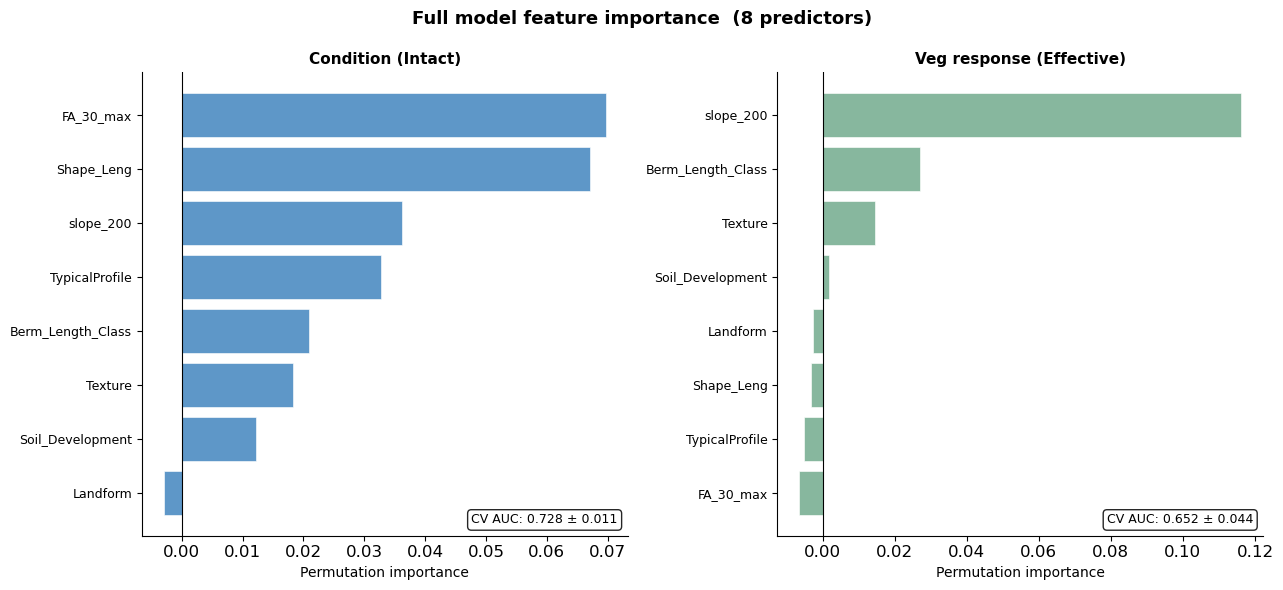

Updated → ../latex/figure_report_outcomes.tex  (RF Binary — feature importance)
Saved: fig_rf_binary_importance.png


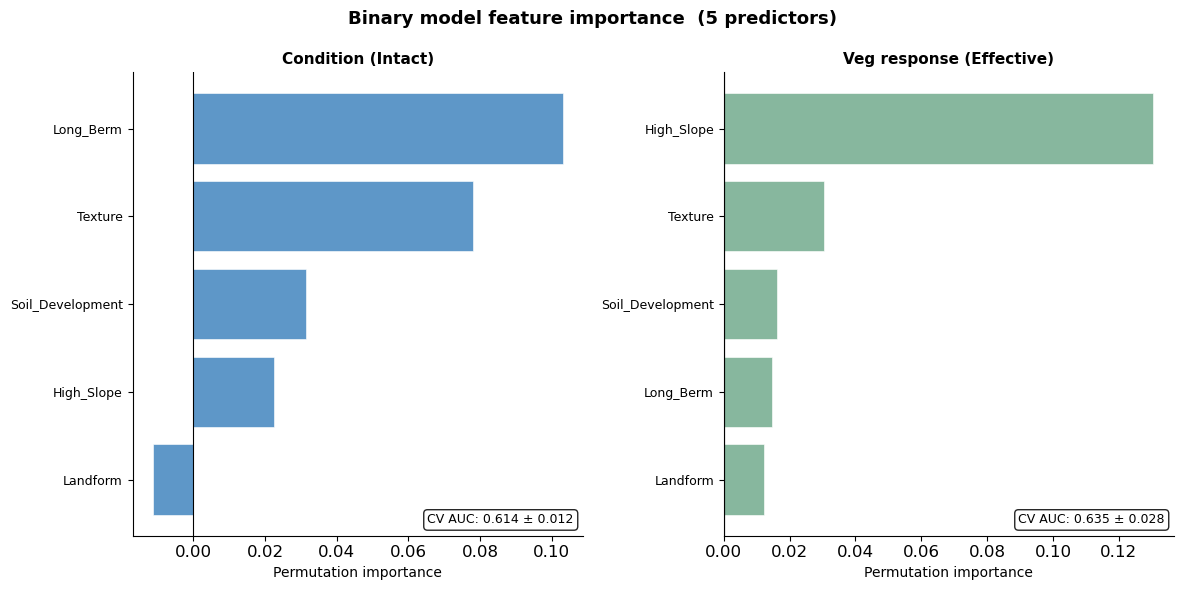

In [51]:
# ── Visualize RF feature importance ─────────────────────────────────────────
# Two separate figures, each with Intact | Effective side by side:
#   fig_full   → Full model
#   fig_binary → Binary model
import os
from registry import register_outcomes_figure

_N_FEAT = 8

def _single_target_panel(ax, importance_series, target_label, color, metrics):
    """Horizontal bar chart for one target's feature importance."""
    imp = importance_series.head(_N_FEAT)
    y = np.arange(len(imp))

    ax.barh(y, imp.values, color=color, alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels(imp.index, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Permutation importance', fontsize=10)
    ax.set_title(target_label, fontsize=11, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    auc = metrics["cv"]["auc"]
    ax.text(0.98, 0.02, f"CV AUC: {auc[0]:.3f} ± {auc[1]:.3f}",
            transform=ax.transAxes, ha='right', va='bottom', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))


_fig_dir = os.path.join('..', 'figures', 'outcomes')
os.makedirs(_fig_dir, exist_ok=True)

auc_full_int = results_full["Intact"]["metrics"]["cv"]["auc"][0]
auc_bin_int  = results_binary["Intact"]["metrics"]["cv"]["auc"][0]
auc_full_eff = results_full["Effective"]["metrics"]["cv"]["auc"][0]
auc_bin_eff  = results_binary["Effective"]["metrics"]["cv"]["auc"][0]
n_full = len(results_full["Intact"]["predictors"])
n_bin  = len(results_binary["Intact"]["predictors"])

# ── Figure 1: Full model ────────────────────────────────────────────────────
fig_full, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
fig_full.suptitle(f"Full model feature importance  ({n_full} predictors)",
                  fontsize=13, fontweight='bold')

_single_target_panel(ax1, results_full["Intact"]["importance"],
                     "Condition (Intact)", MODEL_CLR_CONDITION,
                     results_full["Intact"]["metrics"])
_single_target_panel(ax2, results_full["Effective"]["importance"],
                     "Veg response (Effective)", MODEL_CLR_VEGRESPONSE,
                     results_full["Effective"]["metrics"])

plt.tight_layout()
_fig_name_full = 'fig_rf_full_importance.png'
fig_full.savefig(os.path.join(_fig_dir, _fig_name_full), dpi=300, bbox_inches='tight')

register_outcomes_figure(
    'fig_rf_full_importance',
    'RF Full — feature importance',
    _fig_name_full,
    f"""Full random forest model ({n_full} predictors) feature importance for Condition (Intact) and Veg response (Effective) outcomes side by side.
Condition CV AUC = {auc_full_int:.3f}; top predictors: {', '.join(results_full['Intact']['importance'].head(3).index.tolist())}.
Veg response CV AUC = {auc_full_eff:.3f}; top predictors: {', '.join(results_full['Effective']['importance'].head(3).index.tolist())}.
Negative importances indicate features that add no signal beyond correlated predictors (effectively zero importance).""",
    f"""Full model ({n_full} predictors) permutation importance: Condition CV AUC {auc_full_int:.3f}, Veg response CV AUC {auc_full_eff:.3f}. FA_30_max and Shape_Leng dominate for Condition; slope_200 dominates for Veg response."""
)
print(f"Saved: {_fig_name_full}")
plt.show()

# ── Figure 2: Binary model ──────────────────────────────────────────────────
fig_bin, (ax3, ax4) = plt.subplots(1, 2, figsize=(12, 6))
fig_bin.suptitle(f"Binary model feature importance  ({n_bin} predictors)",
                 fontsize=13, fontweight='bold')

_single_target_panel(ax3, results_binary["Intact"]["importance"],
                     "Condition (Intact)", MODEL_CLR_CONDITION,
                     results_binary["Intact"]["metrics"])
_single_target_panel(ax4, results_binary["Effective"]["importance"],
                     "Veg response (Effective)", MODEL_CLR_VEGRESPONSE,
                     results_binary["Effective"]["metrics"])

plt.tight_layout()
_fig_name_bin = 'fig_rf_binary_importance.png'
fig_bin.savefig(os.path.join(_fig_dir, _fig_name_bin), dpi=300, bbox_inches='tight')

register_outcomes_figure(
    'fig_rf_binary_importance',
    'RF Binary — feature importance',
    _fig_name_bin,
    f"""Binary random forest model ({n_bin} simplified predictors) feature importance for Condition (Intact) and Veg response (Effective) outcomes side by side.
Condition CV AUC = {auc_bin_int:.3f}; top predictors: {', '.join(results_binary['Intact']['importance'].head(3).index.tolist())}.
Veg response CV AUC = {auc_bin_eff:.3f}; top predictors: {', '.join(results_binary['Effective']['importance'].head(3).index.tolist())}.
AUC loss vs full model: Condition {auc_full_int - auc_bin_int:.3f}, Veg response {auc_full_eff - auc_bin_eff:.3f}.""",
    f"""Binary model ({n_bin} predictors) permutation importance: Condition CV AUC {auc_bin_int:.3f}, Veg response CV AUC {auc_bin_eff:.3f}. Long_Berm and Texture lead for Condition; High_Slope dominates for Veg response."""
)
print(f"Saved: {_fig_name_bin}")
plt.show()


Updated → ../latex/figure_report_outcomes.tex  (RF Performance Comparison)

Second figure saved and registered: ../figures/outcomes/fig_rf_performance_comparison.png


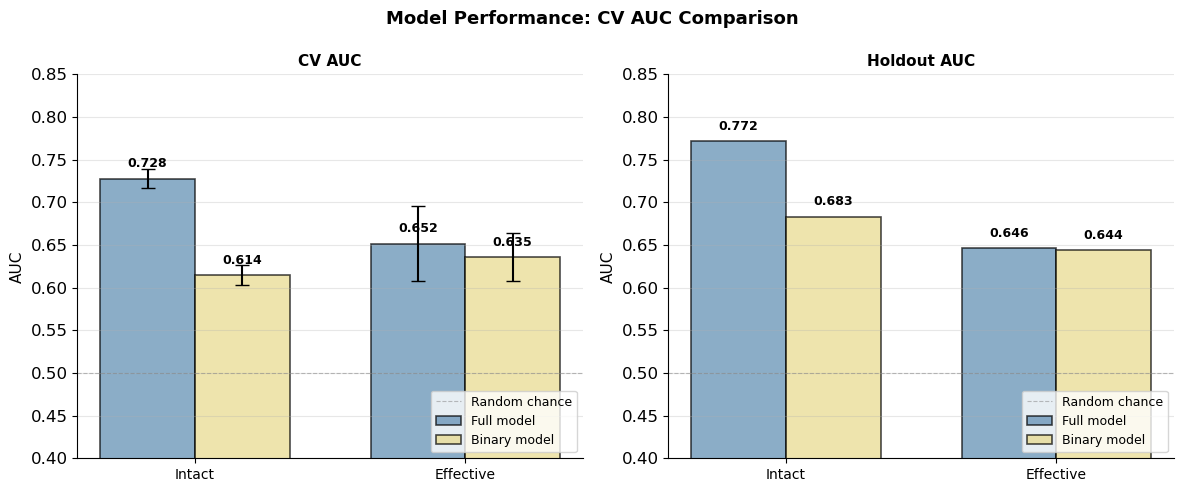

In [52]:
# ── Performance comparison bar chart ─────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))
fig2.suptitle("Model Performance: CV AUC Comparison", fontsize=13, fontweight='bold')

targets = ["Intact", "Effective"]
x_pos = np.arange(len(targets))
bar_w = 0.35

for idx, metric_name in enumerate(["CV AUC", "Holdout AUC"]):
    ax = axes2[idx]
    
    # Extract metrics
    if metric_name == "CV AUC":
        full_vals = [results_full[t]["metrics"]["cv"]["auc"][0] for t in targets]
        full_errs = [results_full[t]["metrics"]["cv"]["auc"][1] for t in targets]
        bin_vals = [results_binary[t]["metrics"]["cv"]["auc"][0] for t in targets]
        bin_errs = [results_binary[t]["metrics"]["cv"]["auc"][1] for t in targets]
    else:  # Holdout AUC
        full_vals = [results_full[t]["metrics"]["holdout"]["auc"] for t in targets]
        full_errs = [0, 0]
        bin_vals = [results_binary[t]["metrics"]["holdout"]["auc"] for t in targets]
        bin_errs = [0, 0]
    
    # Plot bars
    bars1 = ax.bar(x_pos - bar_w/2, full_vals, bar_w, yerr=full_errs if metric_name == "CV AUC" else None,
                   label='Full model', capsize=5, color=INTACT_COL, alpha=0.7, edgecolor='black', linewidth=1.2)
    bars2 = ax.bar(x_pos + bar_w/2, bin_vals, bar_w, yerr=bin_errs if metric_name == "CV AUC" else None,
                   label='Binary model', capsize=5, color=DEGRADED_COL, alpha=0.7, edgecolor='black', linewidth=1.2)
    
    # Add value labels on bars
    for i, (b1, b2) in enumerate(zip(bars1, bars2)):
        ax.text(b1.get_x() + b1.get_width()/2, b1.get_height() + 0.01, 
                f'{full_vals[i]:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax.text(b2.get_x() + b2.get_width()/2, b2.get_height() + 0.01,
                f'{bin_vals[i]:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.set_ylabel('AUC', fontsize=11)
    ax.set_title(metric_name, fontsize=11, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(targets, fontsize=10)
    ax.set_ylim(0.4, 0.85)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, label='Random chance')
    ax.legend(fontsize=9, loc='lower right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

# Save second figure
_fig_name2 = 'fig_rf_performance_comparison.png'
_fig_path2 = os.path.join(_fig_dir, _fig_name2)
fig2.savefig(_fig_path2, dpi=300, bbox_inches='tight')

_delta = max(abs(auc_full_int - auc_bin_int), abs(auc_full_eff - auc_bin_eff))
register_outcomes_figure(
    'fig_rf_performance',
    'RF Performance Comparison',
    _fig_name2,
    f"""Bar chart comparison of model performance (CV AUC and Holdout AUC) for Full vs Binary random forest models on Intact and Effective outcomes.

Full model (n={len(results_full['Intact']['predictors'])} predictors): Intact CV AUC = {auc_full_int:.3f}, Effective CV AUC = {auc_full_eff:.3f}
Binary model (n={len(results_binary['Intact']['predictors'])} predictors): Intact CV AUC = {auc_bin_int:.3f}, Effective CV AUC = {auc_bin_eff:.3f}

Performance difference is minimal (max delta = {_delta:.3f} AUC), indicating that simplified binary predictors capture most of the signal. This validates using binary predictors for interpretability without substantial performance loss.""",
    f"""Model performance comparison showing Full vs Binary RF models achieve similar AUC scores (max delta = {_delta:.3f}). Binary model provides interpretable results with minimal performance sacrifice."""
)

print(f"\nSecond figure saved and registered: {_fig_path2}")
plt.show()


In [53]:

# ── Feature selection: drop zero/negative-importance predictors and refit ──
# For each model version (Full, Binary) × target (Intact, Effective):
#   filter out predictors with mean permutation importance <= 0, refit, compare CV AUC.

import os as _os2
import pandas as _pd

_model_specs = {
    "Full":   {"results": results_full,   "df": df,        "treat_as": full_treat_as},
    "Binary": {"results": results_binary, "df": df_binary, "treat_as": binary_treat_as},
}

_pruned_rows = []
results_pruned = {}

for _model_name, _spec in _model_specs.items():
    print(f"\n{'='*60}")
    print(f"  Model: {_model_name}")
    print(f"{'='*60}")
    results_pruned[_model_name] = {}

    for _target in ["Intact", "Effective"]:
        _imp       = _spec["results"][_target]["importance"]
        _all_preds = _spec["results"][_target]["predictors"]
        _selected  = [p for p in _all_preds if _imp.get(p, 0) > 0]
        _dropped   = [p for p in _all_preds if p not in _selected]

        print(f"\n  ── {_target} ──")
        print(f"    All predictors  ({len(_all_preds)}): {_all_preds}")
        print(f"    Dropped (imp≤0) ({len(_dropped)}): {_dropped}")
        print(f"    Selected        ({len(_selected)}): {_selected}")

        if len(_selected) == 0:
            print("    ⚠  No positive-importance predictors — skipping refit.")
            continue

        _m_pruned, _metrics_pruned, _imp_pruned = fit_rf_binary(
            _spec["df"], y=_target, predictors=_selected,
            treat_as=_spec["treat_as"]
        )
        results_pruned[_model_name][_target] = {
            "model": _m_pruned, "metrics": _metrics_pruned,
            "importance": _imp_pruned, "predictors": _selected
        }

        _auc_before = _spec["results"][_target]["metrics"]["cv"]["auc"]
        _auc_after  = _metrics_pruned["cv"]["auc"]
        _delta      = _auc_after[0] - _auc_before[0]
        print(f"    AUC before: {_auc_before[0]:.3f} ± {_auc_before[1]:.3f}")
        print(f"    AUC after:  {_auc_after[0]:.3f} ± {_auc_after[1]:.3f}  (Δ {_delta:+.3f})")

        _pruned_rows.append({
            "Model":            _model_name,
            "Target":           _target,
            "N_predictors_all": len(_all_preds),
            "N_predictors_sel": len(_selected),
            "Dropped":          ", ".join(_dropped) if _dropped else "—",
            "AUC_full":         round(_auc_before[0], 3),
            "AUC_pruned":       round(_auc_after[0],  3),
            "Delta_AUC":        round(_delta, 3),
        })

_sel_df = _pd.DataFrame(_pruned_rows)
print()
display(_sel_df)

# save comparison CSV
_sel_csv = "../data/summary/rf_feature_selection_comparison.csv"
_sel_df.to_csv(_sel_csv, index=False)
print(f"Saved: {_sel_csv}")



  Model: Full

  ── Intact ──
    All predictors  (8): ['Landform', 'slope_200', 'FA_30_max', 'Texture', 'Soil_Development', 'TypicalProfile', 'Shape_Leng', 'Berm_Length_Class']
    Dropped (imp≤0) (1): ['Landform']
    Selected        (7): ['slope_200', 'FA_30_max', 'Texture', 'Soil_Development', 'TypicalProfile', 'Shape_Leng', 'Berm_Length_Class']
    AUC before: 0.728 ± 0.011
    AUC after:  0.730 ± 0.017  (Δ +0.002)

  ── Effective ──
    All predictors  (8): ['Landform', 'slope_200', 'FA_30_max', 'Texture', 'Soil_Development', 'TypicalProfile', 'Shape_Leng', 'Berm_Length_Class']
    Dropped (imp≤0) (4): ['Landform', 'FA_30_max', 'TypicalProfile', 'Shape_Leng']
    Selected        (4): ['slope_200', 'Texture', 'Soil_Development', 'Berm_Length_Class']
    AUC before: 0.652 ± 0.044
    AUC after:  0.612 ± 0.034  (Δ -0.039)

  Model: Binary

  ── Intact ──
    All predictors  (5): ['High_Slope', 'Long_Berm', 'Landform', 'Soil_Development', 'Texture']
    Dropped (imp≤0) (1): ['Landfo

,Model,Target,N_predictors_all,N_predictors_sel,Dropped,AUC_full,AUC_pruned,Delta_AUC
0,Full,Intact,8,7,Landform,0.728,0.730,0.002
1,Full,Effective,8,4,"Landform, FA_30_max, TypicalProfile, Shape_Leng",0.652,0.612,-0.039
2,Binary,Intact,5,4,Landform,0.614,0.613,-0.002
3,Binary,Effective,5,5,—,0.635,0.635,0.000


Saved: ../data/summary/rf_feature_selection_comparison.csv


In [54]:

# ---- Extra scenarios: effect_percent predicting Intact; Intact predicting Effective ----
import os

base_all = scenario_predictors["all_predictors"]
extra_effective_runs = []

if "effect_percent" in df.columns:
    extra_effective_runs.append((
        "all_predictors + effect_percent", "Intact",
        _unique_preserve(base_all + ["effect_percent"])
    ))

if "Intact" in df.columns:
    extra_effective_runs.append((
        "all_predictors + Intact", "Effective",
        _unique_preserve(base_all + ["Intact"])
    ))

# Run extra scenarios and append to summary_rows
extra_log_lines = []
for scenario_name, target, predictors_run in extra_effective_runs:
    extra_log_lines.append(f"\n\n######## Extra: {scenario_name} / {target} ########")
    extra_log_lines.append(f"Predictors: {predictors_run}")
    try:
        model, metrics, pi = fit_rf_binary(df, y=target, predictors=predictors_run, treat_as=treat_as)
    except Exception as e:
        print(f"Skipping '{scenario_name}' / {target}: {e}")
        continue

    top3_str = ", ".join(pi.head(min(3, len(pi))).index.tolist())
    extra_log_lines.append(f"  cv_auc = {metrics['cv'].get('auc',(np.nan,np.nan))[0]:.4f}  top3 = {top3_str}")

    summary_rows.append({
        "scenario": scenario_name,
        "target": target,
        "cv_auc_mean": metrics["cv"].get("auc", (np.nan, np.nan))[0],
        "top_3_predictors": top3_str,
        "n": metrics["n"],
        "n_predictors": len(predictors_run),
        "cv_auc_sd": metrics["cv"].get("auc", (np.nan, np.nan))[1],
        "holdout_auc": metrics["holdout"].get("auc", np.nan),
        "cv_bal_acc_mean": metrics["cv"].get("bal_acc", (np.nan, np.nan))[0],
        "cv_f1_mean": metrics["cv"].get("f1", (np.nan, np.nan))[0],
    })

# Append extra log to file
results_txt = "../data/summary/scenario_model_results.txt"
with open(results_txt, "a") as f:
    f.write("\n".join(extra_log_lines))

# ---- Rebuild summary tables with reordered columns ----
col_order = [
    "scenario", "target", "cv_auc_mean", "top_3_predictors",
    "n", "n_predictors", "cv_auc_sd", "holdout_auc",
    "cv_bal_acc_mean", "cv_f1_mean",
]

scenario_summary = pd.DataFrame(summary_rows)
col_order = [c for c in col_order if c in scenario_summary.columns]

scenario_summary_effective = (
    scenario_summary.query("target == 'Effective'")[col_order]
    .sort_values("cv_auc_mean", ascending=False)
    .reset_index(drop=True)
)
scenario_summary_intact = (
    scenario_summary.query("target == 'Intact'")[col_order]
    .sort_values("cv_auc_mean", ascending=False)
    .reset_index(drop=True)
)

print("\n--- Effective ---")
display(scenario_summary_effective)
print("\n--- Intact ---")
display(scenario_summary_intact)



--- Effective ---


,scenario,target,cv_auc_mean,top_3_predictors,n,n_predictors,cv_auc_sd,holdout_auc,cv_bal_acc_mean,cv_f1_mean
0,all_predictors,Effective,0.651622,"slope_200, Berm_Length_Class, Texture",743,8,0.044287,0.645988,0.609234,0.581872
1,all_predictors + Intact,Effective,0.648915,"slope_200, Berm_Length_Class, Soil_Development",743,9,0.036397,0.649467,0.610157,0.580234
2,landscape_geomorphology_only,Effective,0.611614,"slope_200, Landform, FA_30_max",743,3,0.043323,0.680311,0.590170,0.570808
3,soil_only,Effective,0.578677,"TypicalProfile, Texture, Soil_Development",743,3,0.029888,0.621347,0.576589,0.542210
4,shape_length_only,Effective,0.558427,"Berm_Length_Class, Shape_Leng",743,2,0.036279,0.497449,0.532750,0.498728



--- Intact ---


,scenario,target,cv_auc_mean,top_3_predictors,n,n_predictors,cv_auc_sd,holdout_auc,cv_bal_acc_mean,cv_f1_mean
0,all_predictors,Intact,0.727806,"FA_30_max, Shape_Leng, slope_200",743,8,0.010714,0.771605,0.656144,0.707243
1,all_predictors + effect_percent,Intact,0.720881,"FA_30_max, Shape_Leng, slope_200",743,9,0.018664,0.770062,0.657340,0.715063
2,landscape_geomorphology_only,Intact,0.655780,"FA_30_max, slope_200, Landform",743,3,0.017483,0.679843,0.592318,0.668733
3,soil_only,Intact,0.627627,"TypicalProfile, Texture, Soil_Development",743,3,0.034388,0.618352,0.585442,0.695597
4,shape_length_only,Intact,0.564382,"Shape_Leng, Berm_Length_Class",743,2,0.017848,0.640966,0.541896,0.620880


In [55]:
# Ensure `length_df` exists for SI table generation
if 'length_df' not in globals():
    try:
        length_df = eff_len_m.copy()
    except NameError:
        raise NameError("Neither 'length_df' nor 'eff_len_m' are defined; run the length-class analysis cells first.")

In [56]:
# Quick baseline CV AUC for both targets using all_predictors
from analysis import fit_rf_binary

_preds_quick = scenario_predictors["all_predictors"]
_, _met_int, _ = fit_rf_binary(df, y="Intact",    predictors=_preds_quick, treat_as=treat_as)
_, _met_eff, _ = fit_rf_binary(df, y="Effective", predictors=_preds_quick, treat_as=treat_as)

_auc_int = _met_int["cv"]["auc"]   # (mean, sd)
_auc_eff = _met_eff["cv"]["auc"]

print(f"Condition    CV AUC: {_auc_int[0]:.3f} ± {_auc_int[1]:.3f}  (n={_met_int['n']})")
print(f"Veg response CV AUC: {_auc_eff[0]:.3f} ± {_auc_eff[1]:.3f}  (n={_met_eff['n']})")

Condition    CV AUC: 0.728 ± 0.011  (n=743)
Veg response CV AUC: 0.652 ± 0.044  (n=743)


## Predictor scenarios

Random forest models were fitted for two binary outcomes — **Intactness** (intact vs. degraded) and **Effectiveness** (effective vs. ineffective) — using four predictor scenarios representing each conceptually distinct predictor group individually and all groups combined:

| Scenario | Predictors included |
|---|---|
| **Geomorphology only** | Landform class, hillslope gradient (slope_200), flow accumulation (FA_30_max) |
| **Soil only** | Soil texture class, soil development, parent material, % clay / sand / silt (r-horizon and surface) |
| **Shape length only** | Berm shape length (Shape_Leng) |
| **All predictors** | All three groups combined |

Model performance is reported as mean cross-validated ROC-AUC (± SD, 5-fold stratified CV). All models use a balanced random forest (class_weight="balanced", 300 trees).

Saved → ../figures/geomorph_soil_intact_effective.png


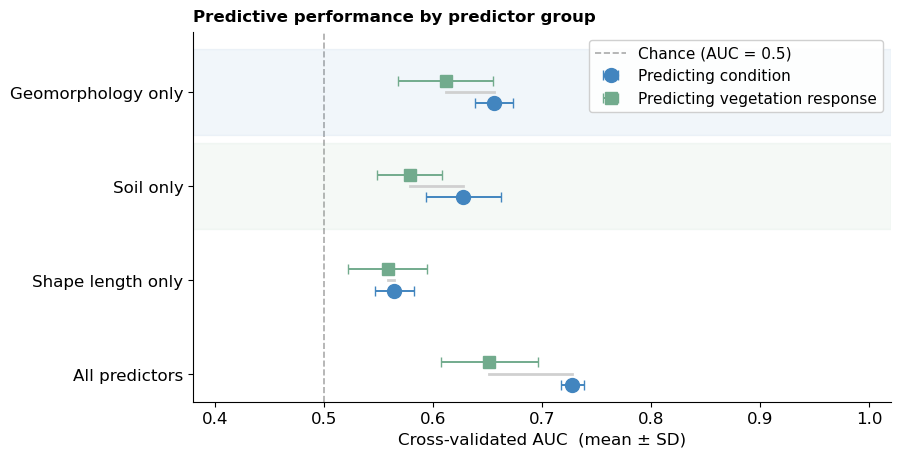

In [57]:

import matplotlib.pyplot as plt
import numpy as np

# ── colour palette (canonical model-outcome colours from constants) ───────────
CLR_INTACT  = MODEL_CLR_CONDITION    # blue       – Condition model
CLR_EFF     = MODEL_CLR_VEGRESPONSE  # sage green – Vegetation response model
CLR_CHANCE  = MODEL_CLR_CHANCE       # grey dashed chance line

# ── Panel A data: four key predictor-group scenarios ─────────────────────────
key_order   = ["landscape_geomorphology_only", "soil_only",
               "shape_length_only", "all_predictors"]
label_map   = {
    "landscape_geomorphology_only": "Geomorphology only",
    "soil_only":                    "Soil only",
    "shape_length_only":            "Shape length only",
    "all_predictors":               "All predictors",
}

sub_ss = (
    scenario_summary[scenario_summary["scenario"].isin(key_order)]
    [["scenario", "target", "cv_auc_mean", "cv_auc_sd"]].copy()
)
sub_ss["label"] = sub_ss["scenario"].map(label_map)
sub_ss["order"] = sub_ss["scenario"].map({s: i for i, s in enumerate(key_order)})

pivoted = (
    sub_ss.pivot_table(index=["scenario", "label", "order"],
                       columns="target",
                       values=["cv_auc_mean", "cv_auc_sd"])
    .reset_index()
    .sort_values("order")
)

y_pos        = np.arange(len(pivoted))
labels_y     = pivoted["label"].tolist()
scenarios_y  = pivoted["scenario"].tolist()
intact_auc   = pivoted[("cv_auc_mean", "Intact")].values
intact_sd    = pivoted[("cv_auc_sd",   "Intact")].values
eff_auc      = pivoted[("cv_auc_mean", "Effective")].values
eff_sd       = pivoted[("cv_auc_sd",   "Effective")].values

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(9, 4.8))

# ── Paired dot plot ───────────────────────────────────────────────────────────
for yi, ia, ea in zip(y_pos, intact_auc, eff_auc):
    ax1.plot([ia, ea], [yi, yi], color="#d0d0d0", linewidth=2, zorder=1)

ax1.errorbar(intact_auc, y_pos + 0.12, xerr=intact_sd,
             fmt="o", color=CLR_INTACT, markersize=10,
             elinewidth=1.4, capsize=3.5, label="Predicting condition", zorder=3)
ax1.errorbar(eff_auc, y_pos - 0.12, xerr=eff_sd,
             fmt="s", color=CLR_EFF, markersize=9,
             elinewidth=1.4, capsize=3.5, label="Predicting vegetation response", zorder=3)

ax1.axvline(0.5, color=CLR_CHANCE, linestyle="--", linewidth=1.2,
            label="Chance (AUC = 0.5)", zorder=0)

# Subtle row shading for the two "signature" scenarios
for yi, sname in zip(y_pos, scenarios_y):
    if sname == "landscape_geomorphology_only":
        ax1.axhspan(yi - 0.46, yi + 0.46, alpha=0.07, color=CLR_INTACT, zorder=0)
    elif sname == "soil_only":
        ax1.axhspan(yi - 0.46, yi + 0.46, alpha=0.07, color=CLR_EFF, zorder=0)

ax1.set_yticks(y_pos)
ax1.set_yticklabels(labels_y, fontsize=12)
ax1.invert_yaxis()
ax1.set_xlim(0.38, 1.02)
ax1.set_xlabel("Cross-validated AUC  (mean ± SD)", fontsize=12)
ax1.set_title("Predictive performance by predictor group",
              fontsize=12, fontweight="bold", loc="left", pad=8)
ax1.legend(loc="upper right", fontsize=11, framealpha=0.92)
ax1.spines[["top", "right"]].set_visible(False)

os.makedirs("../figures", exist_ok=True)
out_path = "../figures/geomorph_soil_intact_effective.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved → {out_path}")
plt.show()

### Potential SI Figures

This section runs single-variable threshold sweeps to identify cut points where degraded or effective fractions separate most strongly.

- The helper function evaluates each candidate threshold, computes proportions, and applies Fisher/Chi-square tests.
- The example calls apply the same workflow to berm length, slope, clay, and sand with variable-specific threshold ranges.

In [58]:
# Sweep candidate thresholds for a single predictor and compare outcome proportions
def analyze_threshold_proportions(data, threshold_var, threshold_name, bins, largeName = 'Large', 
                                     smallName = 'Small'):
    # Store one summary row per threshold value
    results = []

    # Loop across candidate split points (low <= threshold, high > threshold)
    for threshold in bins:
        high = data.query("{0} > @threshold".format(threshold_var))
        low = data.query("{0} <= @threshold".format(threshold_var))

        # Degraded counts
        high_degraded = (high['Condition'] == 'Degraded').sum()
        high_intact = (high['Condition'] == 'Intact').sum()
        low_degraded = (low['Condition'] == 'Degraded').sum()
        low_intact = (low['Condition'] == 'Intact').sum()

        # Convert counts to proportions for degraded outcome
        total_high = high_degraded + high_intact
        total_low = low_degraded + low_intact
        prop_degraded_high = high_degraded / total_high if total_high > 0 else np.nan
        prop_degraded_low = low_degraded / total_low if total_low > 0 else np.nan

        # Vegetation response counts
        high_effective = (high['effective'] == 1).sum()
        high_ineffective = (high['effective'] == 0).sum()
        low_effective = (low['effective'] == 1).sum()
        low_ineffective = (low['effective'] == 0).sum()

        # Convert counts to proportions for vegetation response outcome
        total_high_eff = high_effective + high_ineffective
        total_low_eff = low_effective + low_ineffective
        prop_effective_high = high_effective / total_high_eff if total_high_eff > 0 else np.nan
        prop_effective_low = low_effective / total_low_eff if total_low_eff > 0 else np.nan

        # 2x2 contingency tables for significance tests
        table_degraded = [[low_degraded, low_intact],
                           [high_degraded, high_intact]]
        table_effective = [[low_effective, low_ineffective],
                            [high_effective, high_ineffective]]

        # Significance tests - degraded
        try:
            fisher_p = fisher_exact(table_degraded)[1]
        except:
            fisher_p = np.nan
        try:
            chi2_p = chi2_contingency(table_degraded)[1]
        except:
            chi2_p = np.nan

        # Significance tests - vegetation response
        try:
            fisher_p_eff = fisher_exact(table_effective)[1]
        except:
            fisher_p_eff = np.nan
        try:
            chi2_p_eff = chi2_contingency(table_effective)[1]
        except:
            chi2_p_eff = np.nan

        # Save threshold-level diagnostics for downstream filtering/plotting
        results.append({
            'threshold': threshold,
            'high_proportion_degraded': prop_degraded_high,
            'low_proportion_degraded': prop_degraded_low,
            'high_proportion_effective': prop_effective_high,
            'low_proportion_effective': prop_effective_low,
            'fisher_p_degraded': fisher_p,
            'chi2_p_degraded': chi2_p,
            'significant_degraded': fisher_p < 0.05 if not np.isnan(fisher_p) else False,
            'fisher_p_effective': fisher_p_eff,
            'chi2_p_effective': chi2_p_eff,
            'significant_effective': fisher_p_eff < 0.05 if not np.isnan(fisher_p_eff) else False,
            # Include counts
            'high_degraded': high_degraded,
            'high_intact': high_intact,
            'low_degraded': low_degraded,
            'low_intact': low_intact,
            'high_effective': high_effective,
            'high_ineffective': high_ineffective,
            'low_effective': low_effective,
            'low_ineffective': low_ineffective,
            # Total counts for filtering
            'total_high': total_high,
            'total_low': total_low
        })

    # Full threshold results table
    results_df = pd.DataFrame(results)

    # Filter to thresholds with minimum degraded sample support in both groups
    filtered_df = results_df.query("high_degraded >= 10 and  low_degraded >= 10")

    # Plot low/high proportions for degraded and vegetation response outcomes
    fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True, sharey = True)
    high_color = "C1"
    low_color = "C0"

    sig_degraded = filtered_df['significant_degraded']
    sig_effective = filtered_df['significant_effective']

    # Panel 1: Degraded Fraction
    sns.scatterplot(
        data=filtered_df, x='threshold', y='low_proportion_degraded',
        ax=axes[0], color=low_color, marker='o', label="{1} {0}".format(threshold_name, smallName), alpha=0.5,
    )
    sns.scatterplot(
        data=filtered_df[sig_degraded], x='threshold', y='low_proportion_degraded',
        ax=axes[0], color=low_color, marker='s',
    )
    sns.scatterplot(
        data=filtered_df, x='threshold', y='high_proportion_degraded',
        ax=axes[0], color=high_color, marker='o', label="{1} {0}".format(threshold_name, largeName), alpha=0.5
    )
    sns.scatterplot(
        data=filtered_df[sig_degraded], x='threshold', y='high_proportion_degraded',
        ax=axes[0], color=high_color, marker='s',
    )
    axes[0].set_title("Degraded fraction")
    axes[0].set_ylabel("Degraded fraction")
    axes[0].legend_.remove() if axes[0].legend_ else None

    # Panel 2: Vegetation Response Fraction
    sns.scatterplot(
        data=filtered_df, x='threshold', y='low_proportion_effective',
        ax=axes[1], color=low_color, marker='o', label="{1} {0}".format(threshold_name, smallName), alpha=0.5
    )
    sns.scatterplot(
        data=filtered_df[sig_effective], x='threshold', y='low_proportion_effective',
        ax=axes[1], color=low_color, marker='s',
    )
    sns.scatterplot(
        data=filtered_df, x='threshold', y='high_proportion_effective',
        ax=axes[1], color=high_color, marker='o', label="{1} {0}".format(threshold_name, largeName), alpha=0.5
    )
    sns.scatterplot(
        data=filtered_df[sig_effective], x='threshold', y='high_proportion_effective',
        ax=axes[1], color=high_color, marker='s',
    )
    axes[1].set_title(r"Fraction with vegetation response")
    axes[1].set_xlabel("{0} threshold".format(threshold_name))
    axes[1].set_ylabel("Vegetation response fraction")
    axes[1].legend()

    plt.tight_layout()

    # Return raw numeric results and figure handle for optional save/export
    return results_df, fig


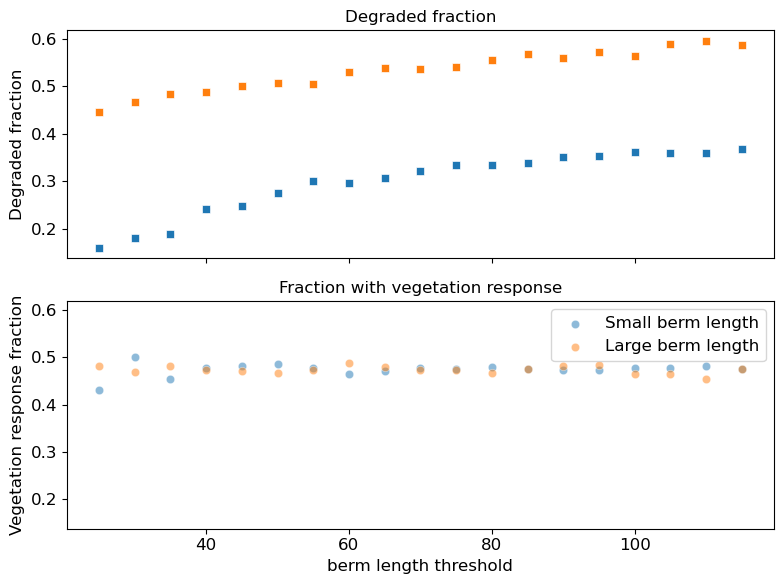

In [59]:
# Berm length threshold sweep (meters): evaluates how low vs high length partitions differ
# in degraded and effective fractions across candidate cut points.
results_df, fig = analyze_threshold_proportions(data, 'Shape_Leng', 'berm length', np.arange(0, 120, 5))
# fig.savefig('../figures/single_variable_plots/Shape_Leng.png')

In [60]:
[c for c in data if 'slope' in c]

['slopeD_100',
 'slopeD_200',
 'slopeD_60',
 'slopeU_100',
 'slopeU_200',
 'slopeU_60',
 'slope_100',
 'slope_200']

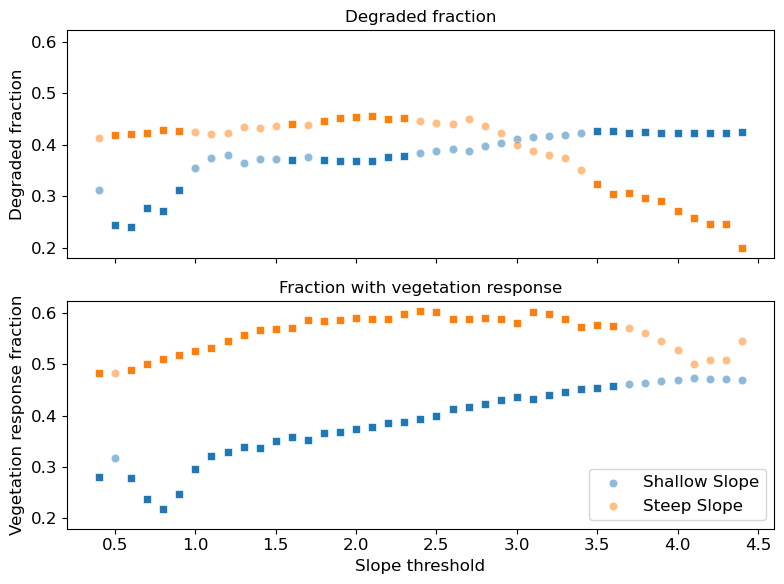

In [61]:
# Slope threshold sweep (%): compare shallow vs steep partitions over candidate slope cut points.
results_df, fig = analyze_threshold_proportions(data, 'slope_200', 'Slope', np.arange(0, 10, 0.1), largeName = 'Steep', smallName = 'Shallow' )
# fig.savefig('../figures/single_variable_plots/Slope.png')

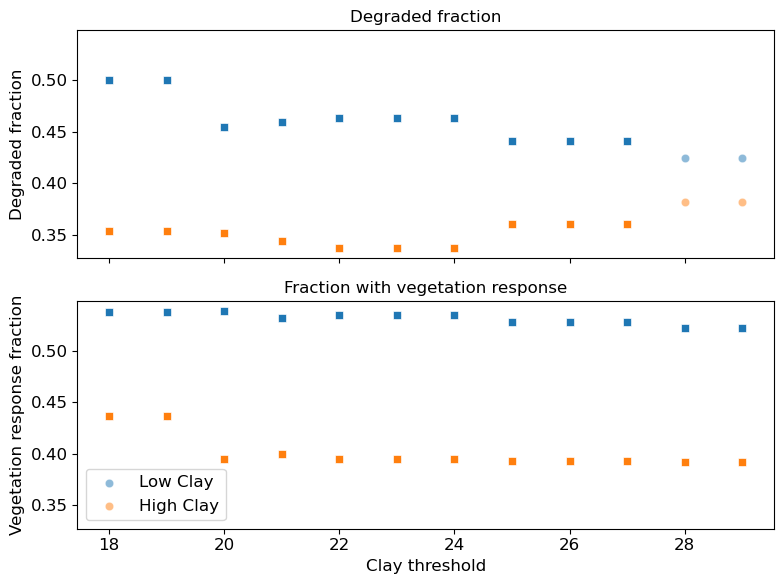

In [62]:
# Clay threshold sweep (% claytotal_r): compare low vs high clay partitions.
results_df, fig = analyze_threshold_proportions(data, 'claytotal_r', 'Clay', np.arange(18, 30, 1), 
                                                largeName = 'High', smallName = 'Low' )
# fig.savefig('../figures/single_variable_plots/Clay.png')

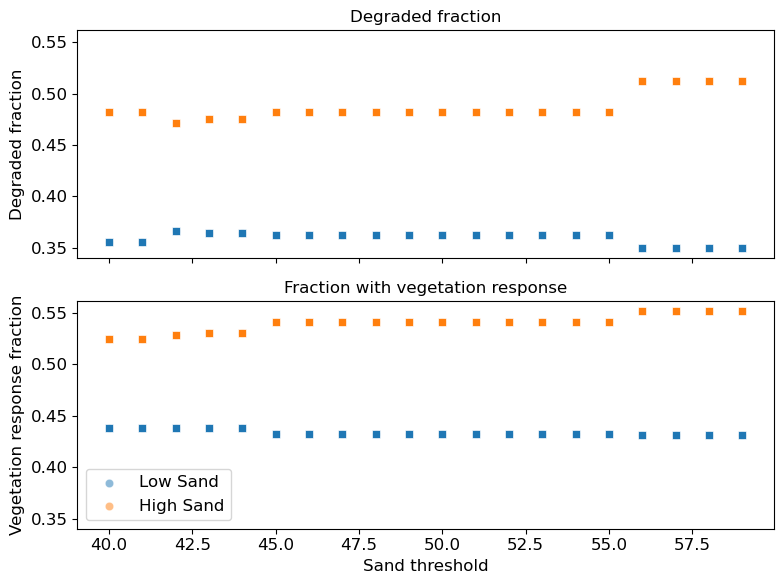

In [63]:
# Sand threshold sweep (% sandtotal_r): compare low vs high sand partitions.
results_df, fig = analyze_threshold_proportions(data, 'sandtotal_r', 'Sand', np.arange(40, 60, 1), 
                                                largeName = 'High', smallName = 'Low' )
# fig.savefig('../figures/single_variable_plots/Sand.png')

In [64]:
from analysis import PRETTY_LABELS, _clean_predictor_name, _format_ranking_for_si


In [65]:
# ── Export SI predictor-ranking and scenario-summary tables as LaTeX ──────────
import os

si_dir = Path("../latex")
si_dir.mkdir(parents=True, exist_ok=True)

# ---- Table S1: Single-predictor ranking → Effective outcome ----
ranked_eff_si = _format_ranking_for_si(ranked)
ranked_eff_si.columns = [c.replace("_", " ").title() for c in ranked_eff_si.columns]

# ---- Table S2: Single-predictor ranking → Intact outcome ----
ranked_int_si = _format_ranking_for_si(ranked_intact)
ranked_int_si.columns = [c.replace("_", " ").title() for c in ranked_int_si.columns]

# ---- Table S3: Scenario summary (both targets, pretty predictor names) ----
ss_si = scenario_summary.copy()
if "top_3_predictors" in ss_si.columns:
    ss_si["top_3_predictors"] = ss_si["top_3_predictors"].apply(
        lambda s: ", ".join(_clean_predictor_name(p.strip()) for p in str(s).split(","))
    )
num_cols = ss_si.select_dtypes(include="number").columns
ss_si[num_cols] = ss_si[num_cols].round(3)
ss_si.columns = [c.replace("_", " ").title() for c in ss_si.columns]

# ---- Table S4: Length-class outcome probabilities ----
length_df_si = length_df.copy()

# ── Build a standalone SI LaTeX file ──────────────────────────────────────────
def _df_to_latex_tabular(df, caption, label):
    """Return a LaTeX table environment string for a DataFrame."""
    n_cols = len(df.columns)
    col_spec = "l" + "r" * (n_cols - 1)
    lines = [
        r"\begin{table}[H]",
        r"  \centering",
        rf"  \caption{{{caption}}}",
        rf"  \label{{{label}}}",
        r"  \small",
        rf"  \begin{{tabular}}{{{col_spec}}}",
        r"    \toprule",
        "    " + " & ".join(str(c) for c in df.columns) + r" \\",
        r"    \midrule",
    ]
    for _, row in df.iterrows():
        vals = " & ".join(str(v) if pd.notna(v) else "--" for v in row)
        lines.append(f"    {vals}" + r" \\")
    lines += [
        r"    \bottomrule",
        r"  \end{tabular}",
        r"\end{table}",
    ]
    return "\n".join(lines)


si_tex = r"""\documentclass[11pt, a4paper]{article}

\usepackage[utf8]{inputenc}
\usepackage[T1]{fontenc}
\usepackage{lmodern}
\usepackage[left=2cm, right=2cm, top=2.5cm, bottom=2.5cm]{geometry}
\usepackage{booktabs}
\usepackage{caption}
\usepackage{float}
\usepackage{parskip}
\usepackage{microtype}
\usepackage{hyperref}
\hypersetup{colorlinks=true, linkcolor=black, urlcolor=blue}

\begin{document}

\begin{center}
  {\LARGE \textbf{Supplementary Information}} \\[0.4em]
  {\large Altar Valley Berms --- Paper 2} \\[0.3em]
  {\small Auto-generated from notebook analysis}
\end{center}

\vspace{1em}\hrule\vspace{1.5em}

"""

si_tex += _df_to_latex_tabular(
    ranked_eff_si,
    caption="Single-predictor ranking for Effective outcome (GLM pseudo-$R^2$, Tjur $R^2$, LRT, CV AUC).",
    label="tab:si_ranked_effective",
)
si_tex += "\n\n\\vspace{2em}\n\n"

si_tex += _df_to_latex_tabular(
    ranked_int_si,
    caption="Single-predictor ranking for Intact outcome (GLM pseudo-$R^2$, Tjur $R^2$, LRT, CV AUC).",
    label="tab:si_ranked_intact",
)
si_tex += "\n\n\\vspace{2em}\n\n"

si_tex += _df_to_latex_tabular(
    ss_si,
    caption="Random-forest scenario summary (5-fold stratified CV).",
    label="tab:si_scenario_summary",
)
si_tex += "\n\n\\vspace{2em}\n\n"

si_tex += _df_to_latex_tabular(
    length_df_si,
    caption="Conditional outcome probabilities by berm length class (threshold = 60 m). "
            "Proportions are shown for long ($>$60 m) and short ($<$60 m) berms; "
            "conditional rows (Breach $|$ failed, Flank $|$ failed) are restricted to failed berms only. "
            "$\\Delta$ is the difference in percentage points (long minus short).",
    label="tab:si_length_outcome_probs",
)
si_tex += "\n\n" + r"\end{document}" + "\n"

si_path = si_dir / "si_tables_failure_mechanisms.tex"
si_path.write_text(si_tex, encoding="utf-8")
print(f"SI tables written to {si_path}")
display(ranked_eff_si)
display(ranked_int_si)
display(ss_si)
display(length_df_si)


SI tables written to ../latex/si_tables_failure_mechanisms.tex


,Predictor,N Levels,Mcfadden R2,Tjur R2,Lrt P,Aic,Df Model,Cv Auc
1,Hillslope gradient (200 m),NaN,0.021,0.030,0.000,1010.583,1.0,0.631
2,Hillslope gradient (100 m),NaN,0.014,0.019,0.000,1017.916,1.0,0.611
5,Parent material,4.0,0.025,0.034,0.000,846.863,3.0,0.585
7,Typical soil profile,18.0,0.049,0.062,0.000,1014.165,17.0,0.577
10,"Clay content (r-horizon, %)",NaN,0.012,0.016,0.001,1020.292,1.0,0.574
14,Channel distance (1000 m),NaN,0.013,0.018,0.000,1019.096,1.0,0.574
16,Soil texture,8.0,0.027,0.037,0.000,1016.549,7.0,0.573
11,High clay,2.0,0.015,0.020,0.000,1017.263,1.0,0.570
0,Landform,3.0,0.015,0.020,0.001,1019.264,2.0,0.563
13,Channel distance (500 m),NaN,0.008,0.011,0.004,1023.847,1.0,0.562


,Predictor,N Levels,Mcfadden R2,Tjur R2,Lrt P,Aic,Df Model,Cv Auc
4,Berm length,NaN,0.038,0.051,0.000,976.161,1.0,0.661
15,Flow accumulation (30 m),NaN,0.008,0.012,0.005,1006.271,1.0,0.660
7,Typical soil profile,18.0,0.072,0.091,0.000,973.757,17.0,0.629
3,Berm length class,2.0,0.037,0.049,0.000,976.687,1.0,0.610
16,Soil texture,8.0,0.031,0.041,0.000,994.409,7.0,0.596
10,"Clay content (r-horizon, %)",NaN,0.013,0.017,0.000,1001.395,1.0,0.579
8,"Sand content (r-horizon, %)",NaN,0.012,0.017,0.000,1001.738,1.0,0.562
11,High clay,2.0,0.008,0.011,0.005,1006.238,1.0,0.552
5,Parent material,4.0,0.029,0.040,0.000,834.534,3.0,0.548
14,Channel distance (1000 m),NaN,0.005,0.006,0.032,1009.619,1.0,0.547


,Scenario,Target,Cv Auc Mean,Cv Auc Sd,Holdout Auc,Cv Bal Acc Mean,Cv F1 Mean,Top 3 Predictors,N,N Predictors
0,landscape_geomorphology_only,Intact,0.656,0.017,0.680,0.592,0.669,"Flow accumulation (30 m), Hillslope gradient (...",743,3
1,landscape_geomorphology_only,Effective,0.612,0.043,0.680,0.590,0.571,"Hillslope gradient (200 m), Landform, Flow acc...",743,3
2,soil_only,Intact,0.628,0.034,0.618,0.585,0.696,"Typical soil profile, Soil texture, Soil devel...",743,3
3,soil_only,Effective,0.579,0.030,0.621,0.577,0.542,"Typical soil profile, Soil texture, Soil devel...",743,3
4,shape_length_only,Intact,0.564,0.018,0.641,0.542,0.621,"Berm length, Berm length class",743,2
5,shape_length_only,Effective,0.558,0.036,0.497,0.533,0.499,"Berm length class, Berm length",743,2
6,all_predictors,Intact,0.728,0.011,0.772,0.656,0.707,"Flow accumulation (30 m), Berm length, Hillslo...",743,8
7,all_predictors,Effective,0.652,0.044,0.646,0.609,0.582,"Hillslope gradient (200 m), Berm length class,...",743,8
8,all_predictors + effect_percent,Intact,0.721,0.019,0.770,0.657,0.715,"Flow accumulation (30 m), Berm length, Hillslo...",743,9
9,all_predictors + Intact,Effective,0.649,0.036,0.649,0.610,0.580,"Hillslope gradient (200 m), Berm length class,...",743,9


,Long (> 50 m),Short (≤ 50 m),sig
Vegetation response,0.466518,0.486239,ns
No vegetation response,0.533482,0.513761,ns


In [66]:
# Post-process generated LaTeX string to escape underscores and Unicode ≤, then write to disk
import re
if 'si_tex' in globals():
    si_tex = re.sub(r'(?<!\\)_', r'\\_', si_tex)
    si_tex = si_tex.replace('≤', r'\\(\\le\\)')
    if 'si_path' in globals():
        si_path.write_text(si_tex, encoding='utf-8')
        print(f'Post-processed si_tex written to {si_path}')
    else:
        print('si_path not defined; run the SI-generation cell that sets `si_path` and writes initially')
else:
    print('si_tex not defined; run the SI-generation cell first')

Post-processed si_tex written to ../latex/si_tables_failure_mechanisms.tex


## Balancing samples

This section is intentionally moved to the end so the balancing diagnostics and summary exports run after core data preparation and modeling outputs.

- Cell 1 defines a helper that balances sample counts across partitions within each group.
- Cells 2-4 write unbalanced and balanced summaries for landform, soil development, and slope partitions.

In [67]:
import pandas as pd

# Helper: create balanced samples by matching counts across partition values
# within each grouping combination (e.g., same Landform + length class).
def balanced_sample(df, group_cols, partition_col):
    # Drop rows with missing values in relevant columns
    cols_required = group_cols + [partition_col]
    df = df.dropna(subset=cols_required)

    grouped = df.groupby(group_cols + [partition_col])
    ct = grouped.size().unstack(partition_col, fill_value=0)

    samples = []
    for idx, row in ct.iterrows():
        partition_values = row.index.tolist()
        min_n = row.min()

        # Skip unbalanced groups
        if row.nunique() == 1 or min_n == 0:
            print(f"Skipping unbalanced group: {idx} | Counts: {row.to_dict()}")
            continue

        group_filter = dict(zip(group_cols, idx if isinstance(idx, tuple) else (idx,)))
        for part_value in partition_values:
            subset = df.copy()
            for col, val in group_filter.items():
                subset = subset[subset[col] == val]
            subset = subset[subset[partition_col] == part_value]
            samples.append(subset.sample(n=min_n, random_state=42))

    return pd.concat(samples).reset_index(drop=True)


In [68]:
# Landform summary export:
# 1) write unbalanced effective/intact distributions
# 2) write length/slope correspondence by landform
partition_col = 'Landform'

# Open file for writing
with open('landform_summary.txt', 'w') as f:
    f.write("\nUnbalanced effective:\n")
    
    summary_counts = data.groupby([partition_col, 'effective']).size().unstack(fill_value=0)
    f.write("\nBerm Counts :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")

    f.write("\nUnbalanced intact:\n")
    summary_counts = data.groupby([partition_col, 'Intact']).size().unstack(fill_value=0)
    f.write("\nBerm intact Counts :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")

    
    f.write("\n Berm length / landform correspondence")
    
    f.write("\nUnbalanced intact:\n")
    summary_counts = data.groupby([partition_col, 'Berm_Length_Class']).size().unstack(fill_value=0)
    f.write("\nBerm intact Counts :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")
    
    
    f.write("\n Slope  / landform correspondence")
    
    summary_counts = data.groupby([partition_col, 'Slope_Class']).size().unstack(fill_value=0)
    f.write("\nBerm Counts :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")    
    
 

In [69]:
# Soil-development summary export:
# 1) report unbalanced effective/intact distributions
# 2) create balanced subsets with one and two grouping schemes
# 3) write balanced counts/proportions for comparison
partition_col = 'Soil_Development'

# Open file for writing
with open('soil_summary.txt', 'w') as f:
    f.write("\nUnbalanced effective:\n")
    
    summary_counts = data.groupby([partition_col, 'effective']).size().unstack(fill_value=0)
    f.write("\nBerm effective Counts :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")

    f.write("\nUnbalanced intact:\n")
    summary_counts = data.groupby([partition_col, 'Intact']).size().unstack(fill_value=0)
    f.write("\nBerm intact Counts :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")
    

    group_cols = ['Slope_Class']   
    f.write("-------\n")
    f.write("\nBalanced: " + ', '.join(group_cols) + "\n")
    

    # Apply balancing function
    balanced_data = balanced_sample(data, group_cols=group_cols, partition_col=partition_col)

    # Split and summarize
    partitions = balanced_data[partition_col].unique()
    f.write("\nSample sizes per partition:\n")
    for part in partitions:
        count = balanced_data[balanced_data[partition_col] == part].shape[0]
        f.write(f"{part}: {count}\n")

    f.write("\nSample breakdown by group:\n")
    group_counts = balanced_data.groupby([partition_col] + group_cols).size()
    f.write(group_counts.to_string())
    f.write("\n")
    
    
    summary_counts = balanced_data.groupby([partition_col, 'effective']).size().unstack(fill_value=0)
    
    f.write("\nBerm counts  :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")

    
    f.write("\nBalanced: " + ', '.join(group_cols) + "\n")
    summary_counts = balanced_data.groupby([partition_col, 'Intact']).size().unstack(fill_value=0)
    f.write("\nBerm counts  :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")
    
 
    group_cols = ['Slope_Class', 'Berm_Length_Class']    

    f.write("-------\n")
    f.write("\nBalanced: " + ', '.join(group_cols) + "\n")
    

    # Apply balancing function
    balanced_data = balanced_sample(data, group_cols=group_cols, partition_col=partition_col)

    # Split and summarize
    partitions = balanced_data[partition_col].unique()
    f.write("\nSample sizes per partition:\n")
    for part in partitions:
        count = balanced_data[balanced_data[partition_col] == part].shape[0]
        f.write(f"{part}: {count}\n")

    f.write("\nSample breakdown by group:\n")
    group_counts = balanced_data.groupby([partition_col] + group_cols).size()
    f.write(group_counts.to_string())
    f.write("\n")

    
    summary_counts = balanced_data.groupby([partition_col, 'effective']).size().unstack(fill_value=0)
    
    f.write("\n")
    f.write("\nBerm counts  :\n")
    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")
    
    f.write("\nBalanced: " + ', '.join(group_cols) + "\n")
  
    summary_counts = balanced_data.groupby([partition_col, 'Intact']).size().unstack(fill_value=0)
    f.write("\nBerm counts  :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")
    
 

In [70]:
# Slope-class summary export:
# 1) report unbalanced effective/intact distributions
# 2) rebalance across Landform and Landform+Length groupings
# 3) compare balanced counts/proportions against unbalanced baseline
# Choose grouping and partition variables
partition_col = 'Slope_Class'

# Open file for writing
with open('slope_summary.txt', 'w') as f:
    f.write("\nUnbalanced effective:\n")
    
    summary_counts = data.groupby([partition_col, 'effective']).size().unstack(fill_value=0)
    f.write("\nBerm effective Counts :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")

    f.write("\nUnbalanced intact:\n")
    summary_counts = data.groupby([partition_col, 'Intact']).size().unstack(fill_value=0)
    f.write("\nBerm intact Counts :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")
    

    group_cols = ['Landform']    
    f.write("-------\n")
    f.write("\nBalanced: " + ', '.join(group_cols) + "\n")
    

    # Apply balancing function
    balanced_data = balanced_sample(data, group_cols=group_cols, partition_col=partition_col)

    # Split and summarize
    partitions = balanced_data[partition_col].unique()
    f.write("\nSample sizes per partition:\n")
    for part in partitions:
        count = balanced_data[balanced_data[partition_col] == part].shape[0]
        f.write(f"{part}: {count}\n")

    f.write("\nSample breakdown by group:\n")
    group_counts = balanced_data.groupby([partition_col] + group_cols).size()
    f.write(group_counts.to_string())
    f.write("\n")
    
    
    summary_counts = balanced_data.groupby([partition_col, 'effective']).size().unstack(fill_value=0)
    
    f.write("\nBerm counts  :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")

    
    f.write("\nBalanced: " + ', '.join(group_cols) + "\n")
    summary_counts = balanced_data.groupby([partition_col, 'Intact']).size().unstack(fill_value=0)
    f.write("\nBerm counts  :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")
    
 
    group_cols = ['Landform', 'Berm_Length_Class']    

    f.write("-------\n")
    f.write("\nBalanced: " + ', '.join(group_cols) + "\n")
    

    # Apply balancing function
    balanced_data = balanced_sample(data, group_cols=group_cols, partition_col=partition_col)

    # Split and summarize
    partitions = balanced_data[partition_col].unique()
    f.write("\nSample sizes per partition:\n")
    for part in partitions:
        count = balanced_data[balanced_data[partition_col] == part].shape[0]
        f.write(f"{part}: {count}\n")

    f.write("\nSample breakdown by group:\n")
    group_counts = balanced_data.groupby([partition_col] + group_cols).size()
    f.write(group_counts.to_string())
    f.write("\n")

    
    summary_counts = balanced_data.groupby([partition_col, 'effective']).size().unstack(fill_value=0)
    
    f.write("\n")
    f.write("\nBerm counts  :\n")
    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")
    
    f.write("\nBalanced: " + ', '.join(group_cols) + "\n")
  
    summary_counts = balanced_data.groupby([partition_col, 'Intact']).size().unstack(fill_value=0)
    f.write("\nBerm counts  :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")
    
 